In [1]:

%load_ext autoreload
%autoreload 2

import sys
from scipy.stats import sem

file_path = '/Users/michaelfinch/CA1-interneuron-GLM' #Mac
#file_path=r"C:\Users\Msfin\cloned_repositories\CA1-interneuron-GLM"

sys.path.append(file_path)

from utils_TCA_clustering_scratchpad import *
from GLM_regression_plotting import *


from modelling_to_date_utils import *

from finding_weights_over_NDNF_utils import *

/Users/michaelfinch/CA1-interneuron-GLM/utils.py:7: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [8]:
# activity_dict, predicted_activity_dict_NDNF_new, filtered_factors_dict, new_NDNF_activity_dict, new_NDNF_velocity_dict, residual_activity_dict_NDNF_new = load_data_regular(file_path=file_path, name="NDNFanalC", new_NDNF=True)
# GLM_params, activity_dict, double_predicted_activity_dict_NDNF_new, factors_dict, filtered_factors_dict, residual_activity_dict_NDNF_new = load_data_regular(file_path=file_path, name="NDNFanalC", new_NDNF=True)
# GLM_params_old_NDNF, activity_dict_old_NDNF, double_predicted_activity_dict_NDNF_old, factors_dict_old_NDNF, filtered_factors_dict_old_NDNF, residual_activity_dict_NDNF_old = load_data_regular(file_path=file_path, name="NDNFindivsomata_GLM", new_NDNF=False)
GLM_params_SST, activity_dict_SST, double_predicted_activity_dict_SST, factors_dict_SST, filtered_factors_dict_SST, residual_activity_dict_SST = load_data_regular(file_path=file_path, name="SSTindivsomata_GLM", new_NDNF=False)
GLM_params_EC, activity_dict_EC, double_predicted_activity_dict_EC, factors_dict_EC, filtered_factors_dict_EC, residual_activity_dict_EC = load_data_regular(file_path=file_path, name="EC_GLM", new_NDNF=False)
GLM_params_NDNF_newest, activity_dict_NDNF_newest, double_predicted_activity_dict_NDNF_newest, factors_dict_NDNF_newest, filtered_factors_dict_NDNF_newest, residual_activity_dict_NDNF_newest = load_data_regular(file_path=file_path, name="NDNF_E1A1B", new_NDNF=True)

fixed_factors_dict_NDNF_newest = subset_factors(factors_dict_NDNF_newest)
fixed_residual_activity_dict_NDNF_newest = subset_factors(residual_activity_dict_NDNF_newest)
fixed_activity_dict_NDNF_newest = subset_factors(activity_dict_NDNF_newest)



Text(0.5, 0, 'Position Bins')

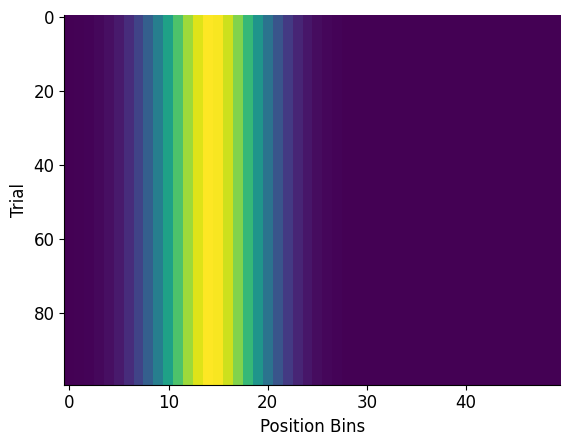

In [85]:
plt.imshow(ca3_3d_array[:,60,:], aspect='auto')
plt.ylabel("Trial")
plt.xlabel("Position Bins")

Text(0.5, 0, 'Position Bins')

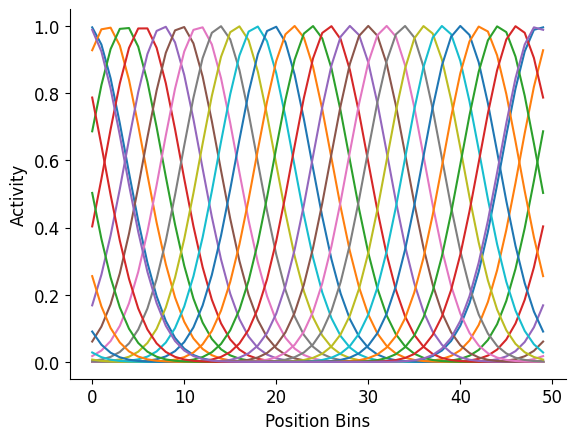

In [128]:
x = np.linspace(0,199,25).astype(int)

for i in x:
    plt.plot(ca3_vs_position_all_cells_array[i,:])
plt.ylabel("Activity")
plt.xlabel("Position Bins")

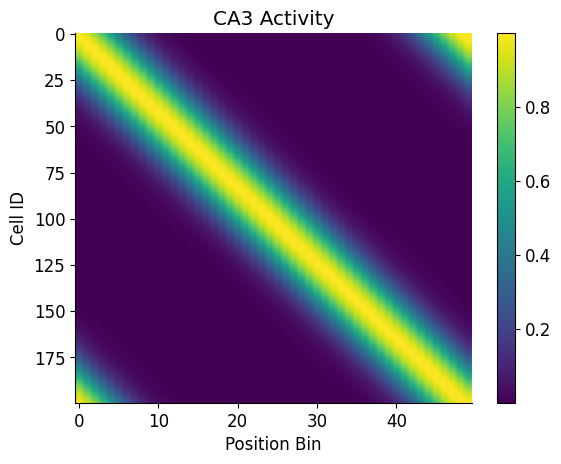

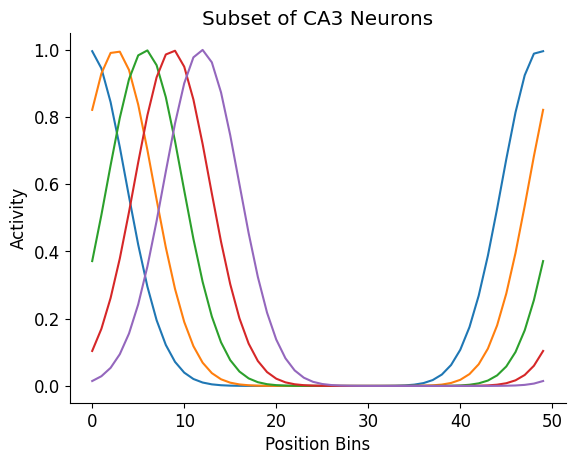

In [76]:
def plot_CA3(ca3_vs_position_all_cells_array):

    plt.imshow(ca3_vs_position_all_cells_array, aspect='auto')
    plt.title("CA3 Activity")
    plt.ylabel("Cell ID")
    plt.xlabel("Position Bin")
    plt.colorbar()
    plt.show()

    position_bins = 50

    dx = 180/position_bins

    visualization_trials = [20, 40]

    p = np.linspace(0, 50, 5)
    x = []
    for i in (p):
        x.append(int(i))

    for j in x:
        plt.plot(ca3_vs_position_all_cells_array[j, :])
    plt.title("Subset of CA3 Neurons")
    plt.xlabel("Position Bins")
    plt.ylabel("Activity")
    plt.show()
    
ca3_vs_position_all_cells_array = get_CA3_data(track_length = 180, num_cells=200)
ca3_3d_array = np.tile(ca3_vs_position_all_cells_array, (100,1,1))

plot_CA3(ca3_vs_position_all_cells_array)


Text(0.5, 0, 'Position Bins')

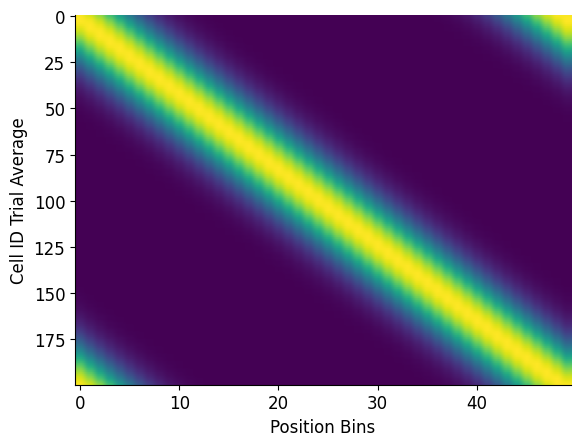

In [79]:
plt.imshow(ca3_vs_position_all_cells_array, aspect='auto')
plt.ylabel("Cell ID Trial Average")
plt.xlabel("Position Bins")

In [26]:
ca3_3d_array = np.tile(ca3_vs_position_all_cells_array, (100,1,1))
ca3_3d_array.shape

(100, 200, 50)

In [34]:
ca3_animal_data_dict = {}

count_early = 0
count_late = 40
for animal in range(5):
    cells_data = ca3_3d_array[:,count_early:count_late,:]
    count_early +=40
    count_late += 40
    cell_dict = {}
    for cell in range(40):
        ca3_animal_data = cells_data[:,cell,:]
        cell_dict[cell] = ca3_animal_data

    ca3_animal_data_dict[animal] = cell_dict




In [ ]:
/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/finding_weights_over_NDNF.ipynb

In [ ]:
# filepath = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/SSTindivsomata_GLM.mat'

# animal_clean_dict_activity, clean_velocity_dict_NDNF_newest, animal_trials_original, animal_trials_clean, trials_to_remove_local, clean_lick_dict_NDNF_newest = get_animal_clean_dict_activity(filepath, use_final=False)

# GLM_params, predicted_activity_dict = fit_GLM_population(clean_velocity_dict_NDNF_newest, animal_clean_dict_activity, quintile=None, regression='ridge', alphas=None)

# clean_resid_activity_dict_NDNF_newest = get_residual_activity_dict(animal_clean_dict_activity, predicted_activity_dict)


with open('/Users/michaelfinch/CA1-interneuron-GLM/datasets/SST_model_dict_clean.pkl', 'rb') as f:
    NDNF_model_dict_clean = pickle.load(f)



SliceTCA(
  (vectors): ModuleList(
    (0): ParameterList(
        (0): Parameter containing: [torch.float32 of size 20x212]
        (1): Parameter containing: [torch.float32 of size 20x1x50]
    )
    (1): ParameterList(
        (0): Parameter containing: [torch.float32 of size 0x1]
        (1): Parameter containing: [torch.float32 of size 0x212x50]
    )
    (2): ParameterList(
        (0): Parameter containing: [torch.float32 of size 0x50]
        (1): Parameter containing: [torch.float32 of size 0x212x1]
    )
  )
)


In [42]:
save_path = '/Users/michaelfinch/CA1-interneuron-GLM/datasets/animal_data_dict.pkl'

with open(save_path, 'wb') as f:
    pickle.dump(animal_data_dict, f)


In [52]:
animal_data_dict[0][0]["model"]

SliceTCA(
  (vectors): ModuleList(
    (0): ParameterList(
        (0): Parameter containing: [torch.float32 of size 20x100]
        (1): Parameter containing: [torch.float32 of size 20x1x50]
    )
    (1): ParameterList(
        (0): Parameter containing: [torch.float32 of size 0x1]
        (1): Parameter containing: [torch.float32 of size 0x100x50]
    )
    (2): ParameterList(
        (0): Parameter containing: [torch.float32 of size 0x50]
        (1): Parameter containing: [torch.float32 of size 0x100x1]
    )
  )
)

In [38]:
import torch
animal_data_dict = {}
for animal in ca3_animal_data_dict:
    cell_data_dict = {}
    for cell in ca3_animal_data_dict[animal]:
        data = ca3_animal_data_dict[animal][cell]
        data = np.expand_dims(data, axis=1)
        data_tensor = torch.from_numpy(data)
        components, model = slicetca.decompose(data_tensor,
                                       number_components=(20,0,0),
                                       positive=True,
                                       learning_rate=5*10**-3,
                                       min_std=10**-5,
                                       max_iter=5000,
                                       iter_std=4000,
                                       seed=0)
        model_data_dict = {"components":components,
                           "model":model}
        cell_data_dict[cell] = model_data_dict
    animal_data_dict[animal] = cell_data_dict



The model converged. Loss: 8.558425861338037e-07 :  82%|████████▏ | 4081/5000 [00:26<00:05, 155.27it/s]
The model converged. Loss: 6.350375770125538e-06 :  82%|████████▏ | 4081/5000 [00:25<00:05, 159.74it/s]
The model converged. Loss: 4.1910152503987774e-06 :  82%|████████▏ | 4081/5000 [00:28<00:06, 144.08it/s]
The model converged. Loss: 9.039178507919132e-07 :  82%|████████▏ | 4081/5000 [00:30<00:06, 132.61it/s]
The model converged. Loss: 4.8264587348967325e-06 :  82%|████████▏ | 4081/5000 [00:32<00:07, 126.57it/s]
The model converged. Loss: 2.028223889283254e-06 :  82%|████████▏ | 4082/5000 [00:33<00:07, 122.41it/s]
The model converged. Loss: 7.539510420428996e-07 :  82%|████████▏ | 4081/5000 [00:34<00:07, 118.81it/s]
The model converged. Loss: 1.1745393067030818e-06 :  82%|████████▏ | 4080/5000 [00:35<00:08, 113.80it/s]
The model converged. Loss: 2.2835049549030373e-06 :  82%|████████▏ | 4079/5000 [00:37<00:08, 109.55it/s]
The model converged. Loss: 1.8872478904086165e-06 :  82%|███

KeyboardInterrupt: 

In [46]:
def preprocess_animal(NDNF_fixed_model_dict, residual_activity_dict, num_clusters=8, reassign_clusters=False, x00=True, umap=True, contiguous=True, ranks=20):

    internals_per_animal_dict_EC_animal_x00_regkmean = {}
    
    for idx, animal in enumerate(residual_activity_dict):
        internals_per_animal_dict_EC_animal_x00_regkmean_cell = {}
        for idt, cell in enumerate(residual_activity_dict[animal]):

            cell_data = residual_activity_dict[animal][cell].T
            cell_data = ((cell_data-np.min(cell_data)) / np.max(cell_data) - np.min(cell_data))
            cell_data_3d = np.expand_dims(cell_data, axis=1)
            cell_data_3d = torch.from_numpy(cell_data_3d)
            cell_model = NDNF_fixed_model_dict[animal][cell]


            internals_dict = get_animal_model_reconstruction_dict_mod(cell_model, cell_data_3d, max_clusters=num_clusters, display=False, reassign_small_clusters=reassign_clusters, x00=x00, use_umap=umap, use_breakpoints=contiguous)

            internals_per_animal_dict_EC_animal_x00_regkmean_cell[cell] = internals_dict
        
        internals_per_animal_dict_EC_animal_x00_regkmean[animal] = internals_per_animal_dict_EC_animal_x00_regkmean_cell

    return internals_per_animal_dict_EC_animal_x00_regkmean



def get_animal_model_reconstruction_dict_mod(animal_model, tensor_for_animal, max_clusters=12, display=False, reassign_small_clusters=True, x00=True, use_umap=False, use_breakpoints=False):
    import warnings
    warnings.filterwarnings("ignore", category=UserWarning)
    warnings.filterwarnings("ignore", category=FutureWarning)

    per_cell_internals_dict = {}
    reconstruction_full_animal = animal_model.construct().numpy(force=True)

    if x00:
        w1 = animal_model.vectors[0][0].detach().numpy()
        X = np.abs(w1.T)
        if use_umap:
            import umap
            umap_model = umap.UMAP(n_components=3, random_state=0)
            X_umap = umap_model.fit_transform(X)
    else:
        f = animal_model.vectors[2][1].detach()
        f1 = f.permute(1, 0, 2).reshape(f.shape[1], -1)
        f1 = torch.abs(f1).cpu().numpy()
        if use_umap:
            import umap
            umap_model = umap.UMAP(n_components=3, random_state=0)
            X_umap = umap_model.fit_transform(f1)

    cluster_labels_dict = {}
    cluster_pca_dict = {}
    cluster_centroids_dict = {}

    for clusters_chosen in range(1, max_clusters):
        if use_breakpoints:
            print(f"Using breakpoint clustering (clusters = {clusters_chosen})")
            model_input = X_umap if use_umap else (X if x00 else f1)
            n_bkps = clusters_chosen - 1
            algo = rpt.Binseg(model="l2", min_size=3).fit(model_input)
            try:
                bkps = algo.predict(n_bkps=n_bkps)
            except rpt.exceptions.BadSegmentationParameters:
                print("  Skipping due to bad breakpoint config")
                continue

            labels = np.zeros(model_input.shape[0], dtype=int)
            start = 0
            for cluster_id, end in enumerate(bkps):
                labels[start:end] = cluster_id
                start = end

            centroids = np.array([
                model_input[labels == i].mean(axis=0)
                for i in range(clusters_chosen)
            ])
            X_pca = PCA(n_components=3).fit_transform(model_input)

        else:
            kmeans = KMeans(n_clusters=clusters_chosen, random_state=0)
            model_input = X_umap if use_umap else (X if x00 else f1)
            labels = kmeans.fit_predict(model_input)

            centroids = kmeans.cluster_centers_
            if use_umap:
                X_pca = PCA(n_components=3).fit_transform(X_umap)
            else:
                X_pca = PCA(n_components=3).fit_transform(model_input)

        cluster_labels_dict[clusters_chosen] = labels
        cluster_centroids_dict[clusters_chosen] = centroids
        cluster_pca_dict[clusters_chosen] = X_pca

    for cell in range(reconstruction_full_animal.shape[1]):
        #     cell = 0
        print(f"Processing cell {cell}...")

        MSE_dict = {}
        x_pca_dict = {}
        labels_dict = {}
        indices_for_cluster_number = {}
        TCA_reconstructions_dict = {}
        Recon_by_cluster_av_dict = {}
        cluster_trial_mean_dict = {}

        reconstructed_cell = reconstruction_full_animal[:, cell, :]
        real_cell_activity = tensor_for_animal[:, cell, :].detach().numpy()

        for clusters_chosen in range(1, max_clusters):
            labels = cluster_labels_dict[clusters_chosen].copy()
            centroids = cluster_centroids_dict[clusters_chosen]
            X_pca = cluster_pca_dict[clusters_chosen]
            model_input = X_umap if use_umap else (X if x00 else f1)

            print(f"\nclusters_chosen = {clusters_chosen}")
            print("Before reassignment:")
            for cluster_id in range(clusters_chosen):
                count = np.sum(labels == cluster_id)
                print(f"  Cluster {cluster_id}: {count} trials")

            if reassign_small_clusters:
                if use_umap:
                    model_input = X_umap
                    centroid_space = np.array([
                        model_input[labels == i].mean(axis=0)
                        for i in range(clusters_chosen)])
                else:
                    model_input = X if x00 else f1
                    centroid_space = centroids
                for cluster_id in range(clusters_chosen):
                    trial_indices = np.where(labels == cluster_id)[0]
                    if len(trial_indices) < 2:
                        print(f"  Reassigning cluster {cluster_id} (size={len(trial_indices)})...")
                        for idx in trial_indices:
                            trial = model_input[idx]
                            dists = cdist([trial], centroid_space)[0]
                            dists[cluster_id] = np.inf
                            new_cluster = np.argmin(dists)
                            labels[idx] = new_cluster

            print("After reassignment:")
            for cluster_id in range(clusters_chosen):
                count = np.sum(labels == cluster_id)
                print(f"  Cluster {cluster_id}: {count} trials")

            x_pca_dict[f"clusters_chosen_{clusters_chosen}"] = X_pca
            labels_dict[f"clusters_chosen_{clusters_chosen}"] = labels

            valid_cluster_mean_trials_list = []
            valid_cluster_indices = []
            cluster_trial_indices = {}

            for n in range(clusters_chosen):
                trial_indices = np.where(labels == n)[0]
                cluster_trial_indices[n] = trial_indices
                if len(trial_indices) == 0:
                    continue
                cluster_trials = real_cell_activity[trial_indices, :]
                mean_cluster = cluster_trials.mean(axis=0)
                valid_cluster_mean_trials_list.append(mean_cluster)
                valid_cluster_indices.append((n, trial_indices))

            empty_cell = np.zeros_like(reconstructed_cell)
            for i, (n, trials) in enumerate(valid_cluster_indices):
                empty_cell[trials, :] = valid_cluster_mean_trials_list[i]

            key = f"clusters_chosen_{clusters_chosen}"
            MSE_dict[key] = np.mean((real_cell_activity - empty_cell) ** 2)
            Recon_by_cluster_av_dict[key] = empty_cell
            TCA_reconstructions_dict[key] = reconstructed_cell
            cluster_trial_mean_dict[key] = valid_cluster_mean_trials_list
            indices_for_cluster_number[key] = cluster_trial_indices

        per_cell_internals_dict[f"cell_{cell}"] = {
            "MSE_dict": MSE_dict,
            "x_pca_dict": x_pca_dict,
            "labels_dict": labels_dict,
            "indices_for_cluster_number": indices_for_cluster_number,
            "TCA_reconstructions_dict": TCA_reconstructions_dict,
            "Recon_by_cluster_av_dict": Recon_by_cluster_av_dict,
            "cluster_trial_mean_dict": cluster_trial_mean_dict,
        }

    return per_cell_internals_dict



In [65]:
clean_resid_activity_dict_NDNF_newest = {}
animal_just_model = {}
animal_just_model_with_20 = {20:{}}
for animal in animal_data_dict:
    jm_cell_dict = {}
    jm_cell_dict_20 = {}
    cell_dict = {}
    for cell in animal_data_dict[animal]:
        cell_dict[cell] = ca3_animal_data_dict[animal][cell].T
        jm_cell_dict[cell] = animal_data_dict[animal][cell]["model"]
        jm_cell_dict_20[cell] = animal_data_dict[animal][cell]["model"]
    clean_resid_activity_dict_NDNF_newest[animal] = cell_dict
    animal_just_model[animal] = jm_cell_dict
    animal_just_model_with_20[20][animal] = jm_cell_dict_20

In [56]:
clean_resid_activity_dict_NDNF_newest[0][0].shape

(100, 50)

In [62]:
def trial_types_for_given_k(some_things_dict, k=None, title=None, ymin_act=None, ymax_act=None, ymin_percent=None, ymax_percent=None, color_list=None, overall_color=None):

    overall_activity_list_all = some_things_dict["overall_activity_list_all"]
    overall_activity_list_all_array = np.array(overall_activity_list_all)

    cells_for_cluster_list = some_things_dict["cells_for_cluster_list"]
    cells_for_cluster_array = np.array(cells_for_cluster_list)

    expression_list_early_overall = some_things_dict["expression_list_early_overall"]
    expression_array_early_overall = np.array(expression_list_early_overall)

    expression_list_late_overall = some_things_dict["expression_list_late_overall"]
    expression_array_late_overall = np.array(expression_list_late_overall)

    activity_list_early_overall = some_things_dict["activity_list_early_overall"]
    activity_array_early_overall = np.array(activity_list_early_overall)

    activity_list_late_overall = some_things_dict["activity_list_late_overall"]
    activity_array_late_overall = np.array(activity_list_late_overall)

    fig, axs = plt.subplots(3, k+1, figsize=(4*k, 8))

    fig.suptitle(title)

    mse_list = []

    for h in range(1,11):

        kmeans = KMeans(n_clusters=h, random_state=45, n_init=100)

        labels = kmeans.fit_predict(overall_activity_list_all_array)

        empty_array = np.empty(overall_activity_list_all_array.shape)

        u = np.unique(labels)

        for i in u:

            labels_for_cluster = np.where(labels==i)[0]

            mean_activity_in_cluster = np.mean(overall_activity_list_all_array[labels_for_cluster,:], axis=0)

            empty_array[labels_for_cluster,:] = mean_activity_in_cluster

        mse_list.append(np.mean(np.square(empty_array-overall_activity_list_all_array)))


    K = np.arange(1, len(mse_list)+1)

    mse_array = np.array(mse_list)

    elbow_k, distances = find_elbow(K, mse_array)

    axs[2, 0].plot(K, mse_array, '-o', color=overall_color)
    axs[2, 0].set_xlabel("Number of Clusters")
    axs[2, 0].axvline(k, color='r', linestyle='--', label=f'Elbow K={k}')
    axs[2, 0].set_ylabel("MSE")
    axs[2, 0].legend()




    mse_list = []

    labels_list = []

    overall_unique_cells = np.unique(cells_for_cluster_array)
    n_cells = len(overall_unique_cells)

    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')

    labels = kmeans.fit_predict(overall_activity_list_all_array)

    labels_list.append(labels)

    empty_array = np.empty(overall_activity_list_all_array.shape)

    u = np.unique(labels)



    # Force axs to always be 2D: (3, n_clusters)
    axs = np.atleast_2d(axs)
    if axs.shape[0] != 3:
        axs = axs.reshape(3, -1)

    axs[0, 0].imshow(overall_activity_list_all_array, aspect='auto')
    axs[0, 0].set_ylabel("Cluster ID")
    axs[0, 0].set_xlabel("Position Bins")
    

    for i in u:
        labels_for_cluster = np.where(labels==i)[0]
        
        mean_activity_in_cluster = np.mean(overall_activity_list_all_array[labels_for_cluster,:], axis=0)
        sem_activity_in_cluster = sem(overall_activity_list_all_array[labels_for_cluster,:], axis=0)

        mean_activity_in_cluster_early = np.nanmean(activity_array_early_overall[labels_for_cluster,:], axis=0)
        mean_activity_in_cluster_late = np.nanmean(activity_array_late_overall[labels_for_cluster,:], axis=0)

        sem_activity_in_cluster_early = sem(activity_array_early_overall[labels_for_cluster,:], axis=0, nan_policy='omit')
        sem_activity_in_cluster_late = sem(activity_array_late_overall[labels_for_cluster,:], axis=0, nan_policy='omit')

        num_cells_expressed = np.array(cells_for_cluster_list)[labels_for_cluster]

        unique_cells = np.unique(num_cells_expressed)


        print(f"len(num_cells_expressed) {len(num_cells_expressed)} len(unique_cells) {len(unique_cells)}")

        expression_array_early_overall_cluster = expression_array_early_overall[labels_for_cluster]
        expression_array_late_overall_cluster = expression_array_late_overall[labels_for_cluster]

        mean_expression_in_cluster_early = np.mean(expression_array_early_overall_cluster)
        mean_expression_in_cluster_late = np.mean(expression_array_late_overall_cluster)
        sem_expression_in_cluster_early = sem(expression_array_early_overall_cluster)
        sem_expression_in_cluster_late = sem(expression_array_late_overall_cluster)

        empty_array[labels_for_cluster,:] = mean_activity_in_cluster

        axs[0,i+1].plot(mean_activity_in_cluster, color=overall_color)
        good_data = overall_activity_list_all_array[labels_for_cluster,:]
        # for u in range(good_data.shape[0]):
        #     axs[0,i+1].plot(good_data[u,:], color='b', alpha=0.05)
        axs[0,i+1].fill_between(range(len(mean_activity_in_cluster)), mean_activity_in_cluster-sem_activity_in_cluster, mean_activity_in_cluster+sem_activity_in_cluster, alpha=0.2, color=overall_color)
        axs[0,i+1].set_title(f"Cluster Number {i} \n {len(unique_cells)}/{n_cells} Cells = {(len(unique_cells)/n_cells)*100:.2f}%")
        axs[0,i+1].set_ylabel(f"Z-Scored DF/F")
        axs[0,i+1].set_xlabel(f"Position Bins")
        axs[0,i+1].set_ylim(ymin_act, ymax_act)
        

        axs[1,i+1].plot(mean_activity_in_cluster_early, label="Early", color=color_list[0])
        axs[1,i+1].plot(mean_activity_in_cluster_late, label="Late", color=color_list[1])
        axs[1,i+1].fill_between(range(len(mean_activity_in_cluster_early)), mean_activity_in_cluster_early+sem_activity_in_cluster_early, mean_activity_in_cluster_early-sem_activity_in_cluster_early, alpha=0.2, color=color_list[0])
        axs[1,i+1].fill_between(range(len(mean_activity_in_cluster_late)), mean_activity_in_cluster_late+sem_activity_in_cluster_late, mean_activity_in_cluster_late-sem_activity_in_cluster_late, alpha=0.2, color=color_list[1])
        axs[1,i+1].set_ylabel(f"Z-Scored DF/F")
        axs[1,i+1].set_xlabel(f"Position Bins")
        axs[1,i+1].legend()
        axs[1,i+1].set_ylim(ymin_act, ymax_act)

        x = [0.1, 0.9]

        t, p = ttest_rel(expression_array_early_overall_cluster, expression_array_late_overall_cluster)

        means_list = [mean_expression_in_cluster_early, mean_expression_in_cluster_late]
        
        sems_list = [sem_expression_in_cluster_early, sem_expression_in_cluster_late]

        # axs[2,i+1].plot(x, means_list, marker='o')
        # axs[2, i+1].errorbar(x, means_list, yerr=sems_list, fmt='o')
        # axs[2,i+1].set_title(f"Early vs Late p={p:.3f}")
        # axs[2,i+1].set_xticks(x, ["Early", "Late"])
        # axs[2,i+1].set_ylim(ymin_percent, ymax_percent)

        axs[2, i+1].plot(x, means_list, color='black', zorder=1)

        for j in range(len(x)):
            axs[2, i+1].errorbar(x[j], means_list[j], yerr=sems_list[j], 
                                fmt='o', color=color_list[j], zorder=2)

        axs[2, i+1].set_title(f"Early vs Late p={p:.3f}")
        axs[2, i+1].set_xticks(x)
        axs[2, i+1].set_xticklabels(["Early", "Late"])
        axs[2, i+1].set_ylim(ymin_percent, ymax_percent)
        axs[2, i+1].set_ylabel("Expression Prob. in Learn Chunk")

    axs[1, 0].imshow(empty_array, aspect='auto')
    axs[1, 0].set_ylabel("Cluster ID")
    axs[1, 0].set_xlabel("Position Bins")
    axs[1, 0].set_title(f"Reconstruction K={k}")



    plt.tight_layout()
    plt.show()


Using breakpoint clustering (clusters = 1)
Using breakpoint clustering (clusters = 2)
Using breakpoint clustering (clusters = 3)
Using breakpoint clustering (clusters = 4)
Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 100 trials
After reassignment:
  Cluster 0: 100 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 80 trials
  Cluster 1: 20 trials
After reassignment:
  Cluster 0: 80 trials
  Cluster 1: 20 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 75 trials
  Cluster 1: 5 trials
  Cluster 2: 20 trials
After reassignment:
  Cluster 0: 75 trials
  Cluster 1: 5 trials
  Cluster 2: 20 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 40 trials
  Cluster 1: 35 trials
  Cluster 2: 5 trials
  Cluster 3: 20 trials
After reassignment:
  Cluster 0: 40 trials
  Cluster 1: 35 trials
  Cluster 2: 5 trials
  Cluster 3: 20 trials
Using breakpoint clustering (clusters = 1)
Using breakpoint clustering (clusters = 2)
Using breakpoin

/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/michaelfinch/miniconda3/envs/ca1_env/lib/python3.11/site-packages/numpy/core/_methods.py:121: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


len(num_cells_expressed) 103 len(unique_cells) 34
len(num_cells_expressed) 92 len(unique_cells) 30
len(num_cells_expressed) 104 len(unique_cells) 34
len(num_cells_expressed) 102 len(unique_cells) 33
len(num_cells_expressed) 87 len(unique_cells) 29


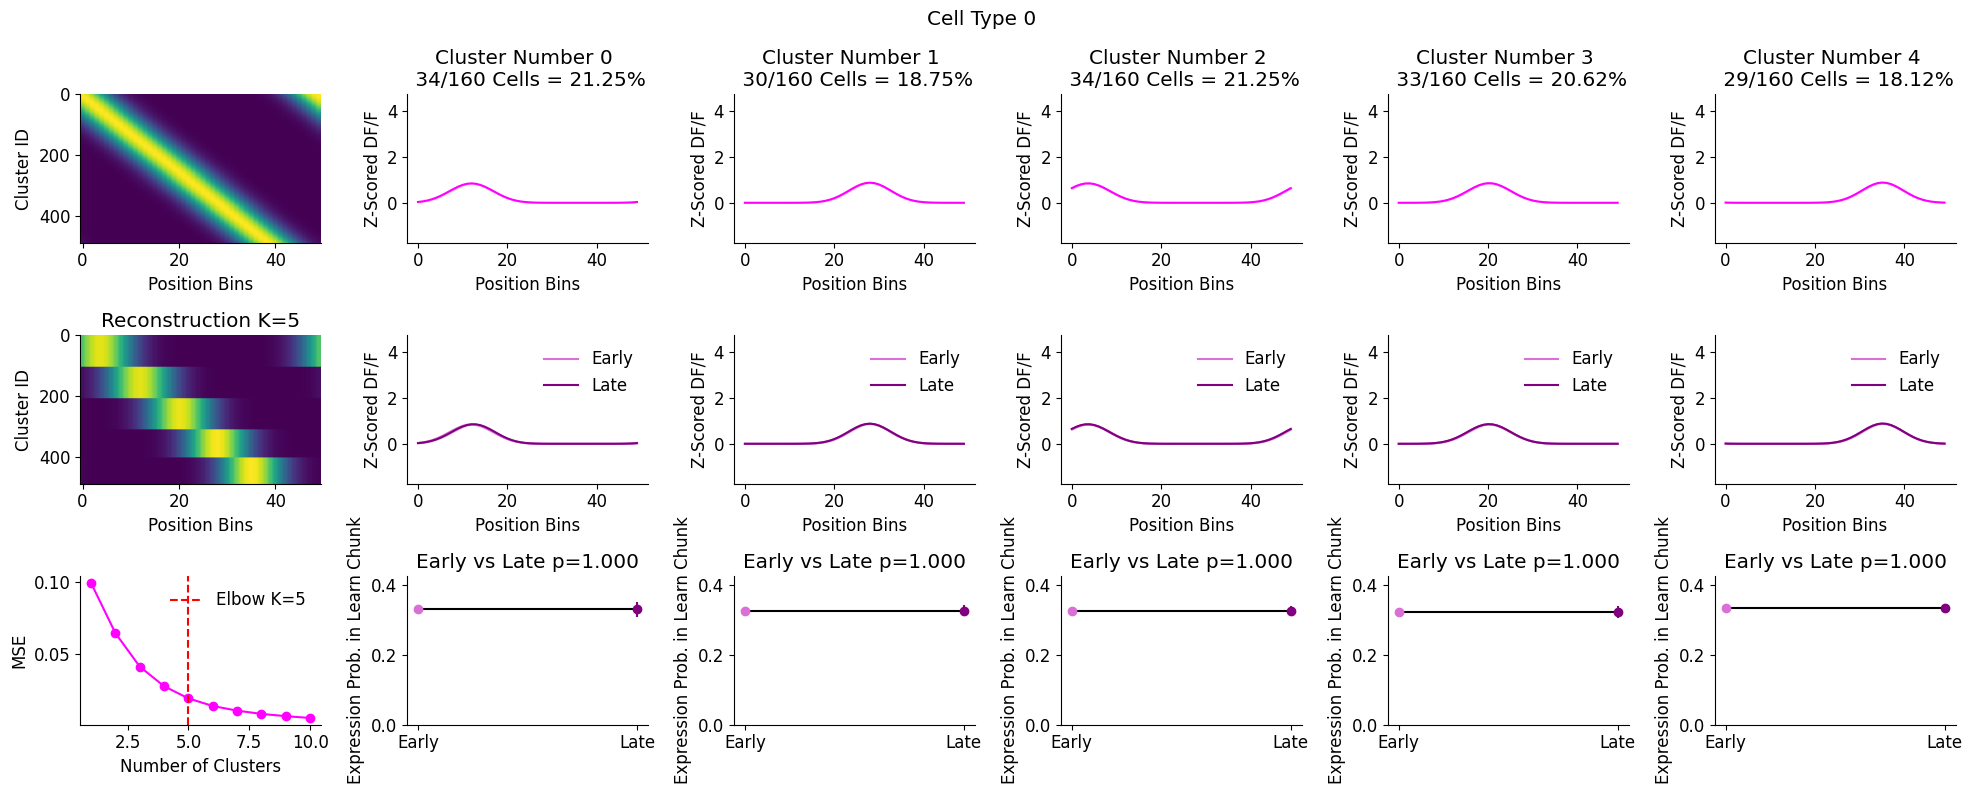

In [74]:

def get_activity_most_least_celltype(ta_activity_dict_for_cluster, to_include=None):
    
    most_expressed_expression_amount_list = []
    least_expressed_expression_amount_list = []

    middle_expressed_expression_amount_list = []
    middle_expressed_activity_list = []

    middle_expressed_activity_early_list = []
    middle_expressed_activity_late_list = []

    middle_expressed_expression_list_early = []
    middle_expressed_expression_list_late = []

    overall_activity_list_most = []
    overall_activity_list_least = []

    overall_activity_list_all = []

    argmax_list_early = []
    argmin_list_early = []
    
    max_amp_list_early = []
    min_amp_list_early = []

    argmax_list_late = []
    argmin_list_late = []
    
    max_amp_list_late = []
    min_amp_list_late = []

    expression_list_early_overall = []
    expression_list_late_overall = []

    activity_list_early_overall = []
    activity_list_late_overall = []

    expression_list_late_pop_maxs = []
    expression_list_late_pop_mins = []

    cells_for_cluster_list = []

    expression_list_early_pop_maxs = []
    expression_list_early_pop_mins = []


    for cell in ta_activity_dict_for_cluster:
        if cell in to_include:
            expression_list = []
            activity_list = []

            expression_list_early = []
            expression_list_late = []

            activity_early_list = []
            activity_late_list = []

            # fig, axs = plt.subplots(1,len(ta_activity_dict_for_cluster[cell]))

            for cluster in ta_activity_dict_for_cluster[cell]:
                cluster_expression = ta_activity_dict_for_cluster[cell][cluster]["cluster_expression"]
                expression_list.append(cluster_expression)
                activity_list.append(ta_activity_dict_for_cluster[cell][cluster]["overall_activity"])

                # axs[cluster].plot(ta_activity_dict_for_cluster[cell][cluster]["overall_activity"])
                # axs[cluster].set_title(f"Cluster {cluster} T.A. Actvity \n Cluster Expression Prob.={ta_activity_dict_for_cluster[cell][cluster]['cluster_expression']:.2f}")
                # axs[cluster].set_ylabel(f"Z-Scored DF/F")
                # axs[cluster].set_xlabel(f"Position Bins")
                # axs[cluster].set_ylim(-0.75, 3)
                

                overall_activity_list_all.append(ta_activity_dict_for_cluster[cell][cluster]["overall_activity"])

                max_loc_early = ta_activity_dict_for_cluster[cell][cluster]["max_loc_early"]
                min_loc_early = ta_activity_dict_for_cluster[cell][cluster]["min_loc_early"]
                max_amp_early = ta_activity_dict_for_cluster[cell][cluster]["max_amp_early"]
                min_amp_early = ta_activity_dict_for_cluster[cell][cluster]["min_amp_early"]

                activity_early = ta_activity_dict_for_cluster[cell][cluster]["early"]
                activity_late = ta_activity_dict_for_cluster[cell][cluster]["late"]

                cells_for_cluster_list.append(cell)

                activity_early_list.append(activity_early)
                activity_late_list.append(activity_late)

                activity_list_early_overall.append(activity_early)
                activity_list_late_overall.append(activity_late)

                expression_list_early.append(ta_activity_dict_for_cluster[cell][cluster]["early_expression"])
                expression_list_late.append(ta_activity_dict_for_cluster[cell][cluster]["late_expression"])

                expression_list_early_overall.append(ta_activity_dict_for_cluster[cell][cluster]["early_expression"])
                expression_list_late_overall.append(ta_activity_dict_for_cluster[cell][cluster]["late_expression"])

                argmax_list_early.append(max_loc_early)
                argmin_list_early.append(min_loc_early)
                max_amp_list_early.append(max_amp_early)
                min_amp_list_early.append(min_amp_early)
                
                max_loc_late = ta_activity_dict_for_cluster[cell][cluster]["max_loc_late"]
                min_loc_late = ta_activity_dict_for_cluster[cell][cluster]["min_loc_late"]
                max_amp_late = ta_activity_dict_for_cluster[cell][cluster]["max_amp_late"]
                min_amp_late = ta_activity_dict_for_cluster[cell][cluster]["min_amp_late"]

                argmax_list_late.append(max_loc_late)
                argmin_list_late.append(min_loc_late)
                max_amp_list_late.append(max_amp_late)
                min_amp_list_late.append(min_amp_late)

            # plt.tight_layout()
            # plt.show()

            expression_list_early_pop_maxs.append(np.max(expression_list_early))
            expression_list_early_pop_mins.append(np.min(expression_list_early))

            for i in range(len(expression_list)):
                
                    middle_expressed_expression_amount_list.append(expression_list[i])
                    middle_expressed_activity_list.append(activity_list[i])
                    middle_expressed_activity_early_list.append(activity_early_list[i])
                    middle_expressed_activity_late_list.append(activity_late_list[i])

                    middle_expressed_expression_list_early.append(expression_list_early[i])
                    middle_expressed_expression_list_late.append(expression_list_late[i])



            
            expression_list_late_pop_maxs.append(np.max(expression_list_late))
            expression_list_late_pop_mins.append(np.min(expression_list_late))
            

            most_expressed_expression = np.argmax(expression_list)
            most_expressed_expression_amount_list.append(expression_list[most_expressed_expression])
            least_expressed_expression = np.argmin(expression_list)
            least_expressed_expression_amount_list.append(expression_list[least_expressed_expression])

            activity_most = activity_list[most_expressed_expression]
            activity_least = activity_list[least_expressed_expression]

            overall_activity_list_most.append(activity_most)
            overall_activity_list_least.append(activity_least)



    most_expressed_expression_amount_array = np.array(most_expressed_expression_amount_list)
    least_expressed_expression_amount_array = np.array(least_expressed_expression_amount_list)

    overall_activity_list_most_array = np.array(overall_activity_list_most)
    overall_activity_list_least_array = np.array(overall_activity_list_least)

    expression_array_early_pop_maxs = np.array(expression_list_early_pop_maxs)
    expression_array_early_pop_mins = np.array(expression_list_early_pop_mins)

    expression_array_late_pop_maxs = np.array(expression_list_late_pop_maxs)
    expression_array_late_pop_mins = np.array(expression_list_late_pop_mins)


    argmax_array_early = np.array(argmax_list_early)
    argmin_array_early = np.array(argmin_list_early)
    
    max_amp_array_early = np.array(max_amp_list_early)
    min_amp_array_early = np.array(min_amp_list_early)

    argmax_array_late = np.array(argmax_list_late)
    argmin_array_late = np.array(argmin_list_late)
    
    max_amp_array_late = np.array(max_amp_list_late)
    min_amp_array_late = np.array(min_amp_list_late)

    everything_dict = {"cells_for_cluster_list":cells_for_cluster_list,
                        "overall_activity_list_most_array":overall_activity_list_most_array, 
                        "expression_list_early_overall" :expression_list_early_overall,
                        "expression_list_late_overall" :expression_list_late_overall,
                        "activity_list_early_overall" :activity_list_early_overall,
                        "activity_list_late_overall" :activity_list_late_overall,
                        "overall_activity_list_least_array":overall_activity_list_least_array, 
                        "most_expressed_expression_amount_array":most_expressed_expression_amount_array, 
                        "least_expressed_expression_amount_array":least_expressed_expression_amount_array,
                        "overall_activity_list_all":overall_activity_list_all,
                        "argmax_array_early" : argmax_array_early,
                        "argmin_array_early" : argmin_array_early,
                        "max_amp_array_early" : max_amp_array_early,
                        "min_amp_array_early" : min_amp_array_early,
                        "argmax_array_late" : argmax_array_late,
                        "argmin_array_late" : argmin_array_late,
                        "max_amp_array_late" : max_amp_array_late,
                        "min_amp_array_late" : min_amp_array_late,
                        "expression_array_early_pop_maxs" : expression_array_early_pop_maxs,
                        "expression_array_early_pop_mins" : expression_array_early_pop_mins,
                        "expression_array_late_pop_maxs" : expression_array_late_pop_maxs,
                        "expression_array_late_pop_mins" : expression_array_late_pop_mins,

}



    return everything_dict



def produce_ta_activity_dict_for_cluster(important_dict):
    sums_list = []

    number_trial_types = []

    ta_activity_dict_for_cluster = {}

    elbow_kmeans_per_cell_list = []

    max_locs_list = []
    min_locs_list = []
    
    max_amplitudes_list = []
    min_amplitudes_list = []

    early_expression_list = []
    middle_expression_list = []
    late_expression_list = []


    for cell in range(len(important_dict["TT_list"])):

        MSE_dict = important_dict["TT_list"][cell]["MSE_dict"]

        MSE_array = np.empty(len(MSE_dict))

        for id, clusters_chosen in enumerate(MSE_dict):
            MSE = MSE_dict[clusters_chosen]
            MSE_array[id] = MSE
        
        elbow_kmeans = find_elbow_point(MSE_array)
        elbow_cluster=f"clusters_chosen_{elbow_kmeans+1}"
        elbow_kmeans_per_cell_list.append(elbow_cluster)

        labels = important_dict["TT_list"][cell]["labels_dict"][elbow_cluster]

        early_cp=important_dict["cp_list_NDNF"][cell][0]
        late_cp=important_dict["cp_list_NDNF"][cell][1]

        label_values = np.unique(labels)

        number_trial_types.append(len(label_values))

        activity_pattern_cell = important_dict["NDNF_activity_list"][cell]

        ta_activity_dict_for_cluster_cell = {}

        for i in label_values:

            trial_type_0_loc = np.where(labels==i)[0]

            overall_expression_prob = len(trial_type_0_loc) / activity_pattern_cell.shape[1]

            den = len(trial_type_0_loc)

            if den == 0:
                print("no zero cells")
                print(labels)


            overall_activity = np.mean(activity_pattern_cell[:,trial_type_0_loc], axis=1)
            baseline_start_overall = overall_activity[0]
            max_loc_overall = np.argmax(overall_activity)
            min_loc_overall = np.argmin(overall_activity)
            max_locs_list.append(max_loc_overall)
            min_locs_list.append(min_loc_overall)

            max_amp_overall = overall_activity[max_loc_overall] 
            min_amp_overall = overall_activity[min_loc_overall] 
            max_amplitudes_list.append(max_amp_overall)
            min_amplitudes_list.append(min_amp_overall)
            
            tt0_early = trial_type_0_loc<early_cp
            tt0_indices_early = trial_type_0_loc[tt0_early]
            total_trials_early = len(tt0_early)
            successes_early = np.sum(tt0_early) ## this is a count of early block successes

            activity_pattern_early = activity_pattern_cell[:,tt0_indices_early]

            tt0_middle = (trial_type_0_loc >= early_cp) & (trial_type_0_loc <  late_cp)
            total_trials_middle = len(tt0_middle)
            successes_middle = np.sum(tt0_middle)
            tt0_indices_middle = trial_type_0_loc[tt0_middle]
            activity_pattern_middle = activity_pattern_cell[:,tt0_indices_middle]

            tt0_late   = trial_type_0_loc >= late_cp
            total_trials_late = len(tt0_late)
            successes_late = np.sum(tt0_late)
            tt0_indices_late = trial_type_0_loc[tt0_late]
            activity_pattern_late = activity_pattern_cell[:,tt0_indices_late]

            ta_activity_early = np.mean(activity_pattern_early, axis=1)
            ta_activity_middle = np.mean(activity_pattern_middle, axis=1)
            ta_activity_late = np.mean(activity_pattern_late, axis=1)

            middle_num_trials = late_cp-early_cp
            late_num_trials = activity_pattern_cell.shape[1] - late_cp

            sum = early_cp+middle_num_trials+late_num_trials


            if activity_pattern_cell.shape[1] != sum:
                raise ValueError("wrong")

            expression_prob_early = successes_early / early_cp
            expression_prob_middle = successes_middle / middle_num_trials
            expression_prob_late = successes_late / late_num_trials

            early_expression_list.append(expression_prob_early)
            middle_expression_list.append(expression_prob_middle)
            late_expression_list.append(expression_prob_late)

            # expression_prob_early = successes_early / total_trials_early
            # expression_prob_middle = successes_middle / total_trials_middle
            # expression_prob_late = successes_late / total_trials_late



            early_activity = np.mean(activity_pattern_cell[:,tt0_indices_early], axis=1)
            baseline_start_early = early_activity[0]
            max_loc_early = np.argmax(early_activity)
            min_loc_early = np.argmin(early_activity)

            max_amp_early = early_activity[max_loc_early]
            min_amp_early = early_activity[min_loc_early]
            
            middle_activity = np.mean(activity_pattern_cell[:,tt0_indices_middle], axis=1)
            baseline_start_middle = middle_activity[0]
            max_loc_middle = np.argmax(middle_activity)
            min_loc_middle = np.argmin(middle_activity)

            max_amp_middle = middle_activity[max_loc_middle]
            min_amp_middle = middle_activity[min_loc_middle]
            

            late_activity = np.mean(activity_pattern_cell[:,tt0_indices_late], axis=1)
            baseline_start_late = late_activity[0]
            max_loc_late = np.argmax(late_activity)
            min_loc_late = np.argmin(late_activity)

            max_amp_late = late_activity[max_loc_late]
            min_amp_late = late_activity[min_loc_late]
            


            act_dict = {"cluster_expression": overall_expression_prob,
                        "early":ta_activity_early,
                        "middle":ta_activity_middle,
                        "late":ta_activity_late,
                        "early_expression":expression_prob_early,
                        "middle_expression":expression_prob_middle,
                        "late_expression": expression_prob_late,
                        "n_early": int(successes_early),
                        "n_middle": int(successes_middle),
                        "n_late": int(successes_late),
                        "overall_activity":overall_activity,
                        "max_loc_overall":max_loc_overall,
                        "min_loc_overall":min_loc_overall,
                        "max_amp_overall":max_amp_overall,
                        "min_amp_overall":min_amp_overall,
                        "baseline_start_overall":baseline_start_overall,
                        # "baseline_end_overall":min_amp_overall,

                        "max_loc_early":max_loc_early,
                        "min_loc_early":min_loc_early,
                        "max_amp_early":max_amp_early,
                        "min_amp_early":min_amp_early,
                        "baseline_start_early":baseline_start_early,

                        "max_loc_middle":max_loc_middle,
                        "min_loc_middle":min_loc_middle,
                        "max_amp_middle":max_amp_middle,
                        "min_amp_middle":min_amp_middle,
                        "baseline_start_middle":baseline_start_middle,

                        "max_loc_late":max_loc_late,
                        "min_loc_late":min_loc_late,
                        "max_amp_late":max_amp_late,
                        "min_amp_late":min_amp_late,
                        "baseline_start_late":baseline_start_late,}

            ta_activity_dict_for_cluster_cell[i] = act_dict

            if np.isnan(expression_prob_early):
                expression_prob_early = 0.

            if np.isnan(expression_prob_middle):
                expression_prob_middle = 0.

            if np.isnan(expression_prob_late):
                expression_prob_late = 0.

            all_list = [expression_prob_early, expression_prob_middle, expression_prob_late]
            sums = np.sum(all_list)

            sums_list.append(sums)


        ta_activity_dict_for_cluster[cell] = ta_activity_dict_for_cluster_cell

    max_locs_array = np.array(max_locs_list)
    min_locs_array = np.array(min_locs_list)
    max_amplitudes_array = np.array(max_amplitudes_list)
    min_amplitudes_array = np.array(min_amplitudes_list)
    early_expression_array = np.array(early_expression_list)
    middle_expression_array = np.array(middle_expression_list)
    late_expression_array = np.array(late_expression_list)

    param_pool = {"max_loc_overall": max_locs_array,
                  "min_loc_overall": min_locs_array,
                  "max_amp_overall": max_amplitudes_array,
                  "min_amp_overall": min_amplitudes_array,
                  "early_expression_array":early_expression_array,
                  "middle_expression_array":middle_expression_array,
                  "late_expression_array":late_expression_array}

    return ta_activity_dict_for_cluster, elbow_kmeans_per_cell_list, param_pool



def find_elbow(K, mse):
    # normalize
    x = (K - K.min()) / (K.max() - K.min())
    y = (mse - mse.min()) / (mse.max() - mse.min())

    # line between endpoints
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])

    # distance from each point to the line
    distances = []
    for xi, yi in zip(x, y):
        p = np.array([xi, yi])
        d = np.linalg.norm(np.cross(p2 - p1, p1 - p)) / np.linalg.norm(p2 - p1)
        distances.append(d)

    distances = np.array(distances)
    elbow_idx = np.argmax(distances)
    return K[elbow_idx], distances



def reshape_contig_dict(cued_contig_dict, NDNF_cued_model_dict_clean):
    # Match the old structure: outer key is rank (20)
    cued_contig_final = {20: {}}

    for idx, animal in enumerate(NDNF_cued_model_dict_clean):
    # for animal in cued_contig_dict:  # animal index: 0,1,2,...
        cued_contig_final[20][animal] = {}

        print(f"animal {animal} NDNF_cued_model_dict_clean.keys() {NDNF_cued_model_dict_clean.keys()}")

        for cell in cued_contig_dict[animal]:  # cell index: 0,1,2,...
            # 1) SliceTCA model object
            model_obj = NDNF_cued_model_dict_clean[animal][cell]

            # 2) Internals for this cell – currently under "cell_0"
            internals_cell0 = cued_contig_dict[animal][cell]["cell_0"]

            # 3) Rename "cell_0" → f"cell_{cell}" to match old API
            per_cell_internals = {f"cell_{cell}": internals_cell0}

            # 4) Store as [model_obj, per_cell_internals]
            cued_contig_final[20][animal][cell] = [model_obj, per_cell_internals]

    return cued_contig_final

def get_lists_out_of_dicts(fixed_TT_data, fixed_activity_dict_NDNF_newest, cp_dict_NDNF):
    TT_list = []
    for animal in fixed_TT_data:
        for cell in fixed_TT_data[animal]:

            TT_list.append(fixed_TT_data[animal][cell][1][f'cell_{cell}'])


    NDNF_activity_list = []
    for animal in fixed_activity_dict_NDNF_newest:
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            NDNF_activity_list.append(fixed_activity_dict_NDNF_newest[animal][cell])

    cp_list_NDNF = []

    for animal in cp_dict_NDNF:
        for cell in cp_dict_NDNF[animal]:
            cp_list_NDNF.append(cp_dict_NDNF[animal][cell])

    return TT_list, NDNF_activity_list, cp_list_NDNF


def get_cp_dict(cell_SST_model_ranks20_contig_x00):
    changepoints_dict = {}
    for animal in cell_SST_model_ranks20_contig_x00[20]:
        changepoints_cell_dict = {}
        for cell in cell_SST_model_ranks20_contig_x00[20][animal]:
            labels = cell_SST_model_ranks20_contig_x00[20][animal][cell][1][f'cell_{cell}']["labels_dict"]["clusters_chosen_3"]
            changepoints = np.where(np.diff(labels) != 0)[0]
            changepoints_cell_dict[cell] = changepoints
        changepoints_dict[animal] = changepoints_cell_dict

    return changepoints_dict

contig_dict_all_cell_tca = preprocess_animal(animal_just_model, clean_resid_activity_dict_NDNF_newest, num_clusters=5, reassign_clusters=False, x00=True, umap=False, contiguous=True, ranks=20)

contig_dict = reshape_contig_dict(contig_dict_all_cell_tca, animal_just_model)

reassigned_dict = reshape_contig_dict(reassigned_dict_cell_tca, animal_just_model)

cp_dict_NDNF = get_cp_dict(contig_dict)

fixed_TT_data = {}

trial_type_data = reassigned_dict[20]
fixed_TT_data = {}

# for idx, animal in enumerate(trial_type_data):
#     if use_fixed_track:
#         print(f"first_an_idx {first_an_idx} idx {idx} last_an_idx {last_an_idx}")
#         if first_an_idx < idx < last_an_idx:
#             fixed_TT_data[f"animal_{idx+1}"] = trial_type_data[animal]
#     else:
#         if idx > last_an_idx-1:
#             fixed_TT_data[f"animal_{idx+1}"] = trial_type_data[animal]

for idx, animal in enumerate(trial_type_data):
    # fixed_TT_data[f"animal_{idx+1}"] = trial_type_data[animal]
    fixed_TT_data[animal] = trial_type_data[animal]


TT_list, NDNF_activity_list, cp_list_NDNF = get_lists_out_of_dicts(fixed_TT_data, clean_resid_activity_dict_NDNF_newest, cp_dict_NDNF)

important_dict = {"TT_list":TT_list,
                    "NDNF_activity_list":NDNF_activity_list,
                    "cp_list_NDNF": cp_list_NDNF}


    
ta_activity_dict_for_cluster, elbow_kmeans_per_cell_list, param_pool = produce_ta_activity_dict_for_cluster(important_dict)


# labels_dict = get_labels_all_different_Ks_single(sliceTCA_model, which_vectors=1)
# labels = labels_dict[2]


# cells_group_0 = np.where(labels==0)[0]
# cells_group_1 = np.where(labels==1)[0]

 
everything_dict0 = get_activity_most_least_celltype(ta_activity_dict_for_cluster, to_include=range(len(TT_list)))
# everything_dict1 = get_activity_most_least_celltype(ta_activity_dict_for_cluster, to_include=cells_group_1)


some_things_dict0 = {"overall_activity_list_all":everything_dict0["overall_activity_list_all"],
                "cells_for_cluster_list":everything_dict0["cells_for_cluster_list"],
                "expression_list_early_overall" :everything_dict0["expression_list_early_overall"],
                    "expression_list_late_overall" :everything_dict0["expression_list_late_overall"],
                    "activity_list_early_overall" :everything_dict0["activity_list_early_overall"],
                    "activity_list_late_overall" :everything_dict0["activity_list_late_overall"],
                
                }

# some_things_dict1 = {"overall_activity_list_all":everything_dict1["overall_activity_list_all"],
#             "cells_for_cluster_list":everything_dict1["cells_for_cluster_list"],
#             "expression_list_early_overall" :everything_dict1["expression_list_early_overall"],
#                 "expression_list_late_overall" :everything_dict1["expression_list_late_overall"],
#                 "activity_list_early_overall" :everything_dict1["activity_list_early_overall"],
#                 "activity_list_late_overall" :everything_dict1["activity_list_late_overall"],
            
#             }



color_list = ["orchid", "purple"]
mse_list0 = trial_types_for_given_k(some_things_dict0, k=5, title="Cell Type 0", ymin_act=-1.75, ymax_act=4.75, ymin_percent=0, ymax_percent=0.425, color_list=color_list, overall_color='magenta')
# color_list = ["orange", "Crimson"]
# mse_list1 = trial_types_for_given_k(some_things_dict1, k=3, title="Cell Type 1", ymin_act=-1.0, ymax_act=7.0, ymin_percent=-0.025, ymax_percent=0.45, color_list=color_list, overall_color='r')


In [93]:
TT_list[60]['cluster_trial_mean_dict'].keys()

dict_keys(['clusters_chosen_1', 'clusters_chosen_2', 'clusters_chosen_3', 'clusters_chosen_4', 'clusters_chosen_5', 'clusters_chosen_6', 'clusters_chosen_7'])

TT_list[cell]['labels_dict'] dict_keys(['clusters_chosen_1', 'clusters_chosen_2', 'clusters_chosen_3', 'clusters_chosen_4', 'clusters_chosen_5', 'clusters_chosen_6', 'clusters_chosen_7'])
labels [2 2 0 0 2 1 0 1 0 2 1 2 2 2 2 2 0 0 0 1 2 0 0 2 2 2 2 0 0 2 1 1 2 0 1 0 0
 0 0 2 2 0 2 1 0 1 0 0 2 2 2 1 1 2 0 0 2 2 1 1 1 0 2 2 1 1 2 2 2 0 2 1 2 2
 2 0 1 1 2 2 0 0 1 0 2 0 2 1 2 0 2 0 2 0 2 0 1 0 1 1]
labels_early [2 2 0 0 2 1 0 1 0 2 1 2 2 2 2 2 0 0 0 1 2 0 0 2 2 2 2 0 0 2 1 1 2 0 1]
np.sum(early_list) 1.0


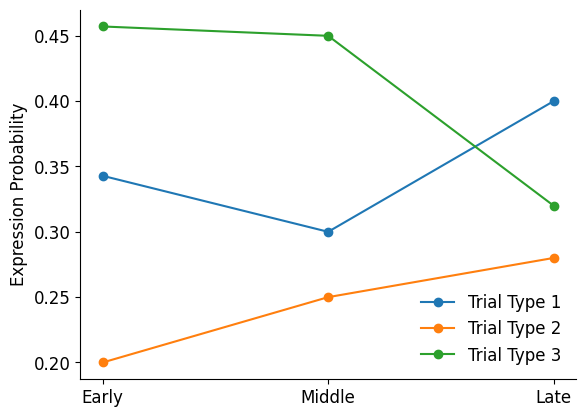

In [139]:
animal = 'animal_2'
cell = 'cell_2'
num_clusters = "clusters_chosen_2"

def plot_cells_trial_types(TT_list, cell=None, num_clusters=None):
    # clust_mean_list = reassigned_dict[20][animal][cell][1][f"cell_{cell}"]["cluster_trial_mean_dict"][num_clusters]

    print(f"TT_list[cell]['labels_dict'] {TT_list[cell]['labels_dict'].keys()}")

    labels = TT_list[cell]["labels_dict"][num_clusters]

    # labels = reassigned_dict[20][animal][cell][1][f"cell_{cell}"]["labels_dict"][num_clusters]

    cp_early = 35
    cp_late = 75

    labels_early = labels[:cp_early]
    labels_middle = labels[cp_early:cp_late]
    labels_late = labels[cp_late:]

    num_trials_early = len(labels_early)
    num_trials_middle = len(labels_middle)
    num_trials_late = len(labels_late)

    early_list = []
    middle_list = []
    late_list = []

    tt_dict = {0:[], 1:[], 2:[]}

    print(f"labels {labels}")
    print(f"labels_early {labels_early}")

    uniq = np.unique(labels)
    for i in uniq:
        loc_early = np.where(labels_early==i)[0]
        exp_prob_early = len(loc_early) / len(labels_early)
        early_list.append(exp_prob_early)
        loc_middle = np.where(labels_middle==i)[0]
        exp_prob_middle = len(loc_middle) / len(labels_middle)
        middle_list.append(exp_prob_middle)
        loc_late = np.where(labels_late==i)[0]
        exp_prob_late = len(loc_late) / len(labels_late)
        late_list.append(exp_prob_late)

        tt_dict[i].append(exp_prob_early)
        tt_dict[i].append(exp_prob_middle)
        tt_dict[i].append(exp_prob_late)

    print(f"np.sum(early_list) {np.sum(early_list)}")



    # for i in range(len(clust_mean_list)):
    #     plt.plot(clust_mean_list[i], label=f'Trial Type {i}')
    # # plt.plot(clust_mean_list[2], label=i)
    # plt.ylabel("Z-Scored DF/F")
    # plt.xlabel("Position Bin")
    # plt.legend()
    # plt.show()

    plt.plot(tt_dict[0], marker='o', label=f'Trial Type {1}')
    plt.plot(tt_dict[1], marker='o', label=f'Trial Type {2}')
    plt.plot(tt_dict[2], marker='o', label=f'Trial Type {3}')
    plt.xticks(range(3), ["Early", "Middle", "Late"])
    plt.ylabel("Expression Probability")
    plt.legend()
    plt.show()


plot_cells_trial_types(TT_list, cell=60, num_clusters="clusters_chosen_3")

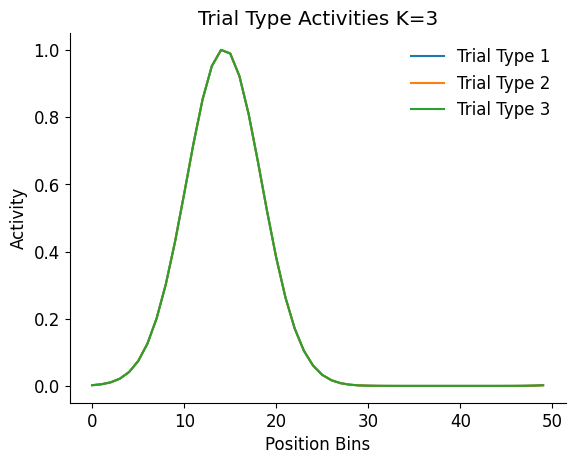

In [105]:
x = TT_list[60]['cluster_trial_mean_dict']["clusters_chosen_3"]
for i in range(len(x)):
    plt.plot(x[i], label=f'Trial Type {i+1}')
plt.title("Trial Type Activities K=3")
plt.xlabel("Position Bins")
plt.ylabel("Activity")
plt.legend()
plt.show()

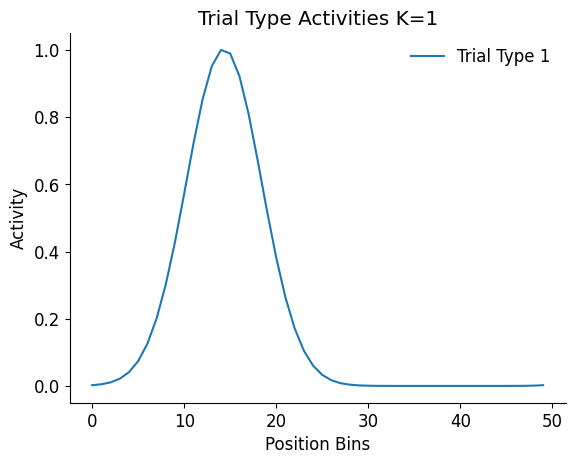

In [104]:
x = TT_list[60]['cluster_trial_mean_dict']["clusters_chosen_1"]
for i in range(len(x)):
    plt.plot(x[i], label=f'Trial Type {i+1}')
plt.title("Trial Type Activities K=1")
plt.xlabel("Position Bins")
plt.ylabel("Activity")
plt.legend()
plt.show()

In [99]:
TT_list[60]["MSE_dict"]["clusters_chosen_3"]

7.356647e-15

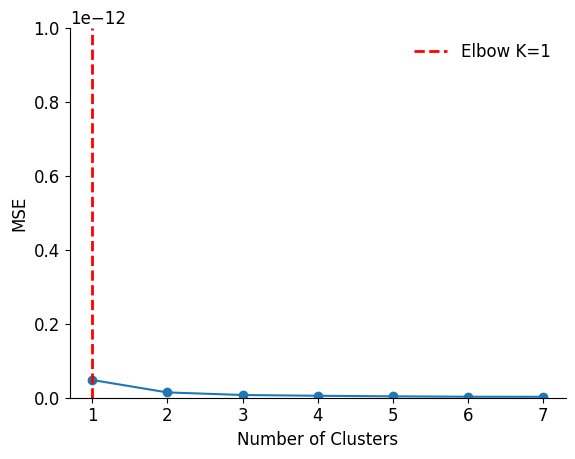

In [120]:
mse_dict = TT_list[60]["MSE_dict"]
mse_list = []
for clust_num in mse_dict:
    mse_list.append(mse_dict[clust_num])

mse_array = np.array(mse_list)
# mse_array[0] = mse_array[0]/2.2
plt.plot(mse_array, marker='o')
plt.ylim(0, 0.000000000001)
plt.ylabel("MSE")
plt.xticks(range(7), np.arange(1,8))
plt.xlabel("Number of Clusters")
plt.axvline(0, linewidth=2, linestyle='--', color='r', label='Elbow K=1')
plt.legend()

In [58]:
reassigned_dict_cell_tca = preprocess_animal(animal_just_model, clean_resid_activity_dict_NDNF_newest, num_clusters=8, reassign_clusters=True, x00=True, umap=False, contiguous=False, ranks=20)

# contig_dict_all_cell_tca = preprocess_animal(NDNF_model_dict_clean, clean_resid_activity_dict_NDNF_newest, num_clusters=5, reassign_clusters=False, x00=True, umap=False, contiguous=True, ranks=20)


# print(f"contig_dict_all_cell_tca.keys() {contig_dict_all_cell_tca.keys()}")


# contig_dict = reshape_contig_dict(contig_dict_all_cell_tca, NDNF_model_dict_clean)

# reassigned_dict = reshape_contig_dict(reassigned_dict_cell_tca, NDNF_model_dict_clean)

Processing cell 0...

clusters_chosen = 1
Before reassignment:
  Cluster 0: 100 trials
After reassignment:
  Cluster 0: 100 trials

clusters_chosen = 2
Before reassignment:
  Cluster 0: 52 trials
  Cluster 1: 48 trials
After reassignment:
  Cluster 0: 52 trials
  Cluster 1: 48 trials

clusters_chosen = 3
Before reassignment:
  Cluster 0: 34 trials
  Cluster 1: 35 trials
  Cluster 2: 31 trials
After reassignment:
  Cluster 0: 34 trials
  Cluster 1: 35 trials
  Cluster 2: 31 trials

clusters_chosen = 4
Before reassignment:
  Cluster 0: 31 trials
  Cluster 1: 30 trials
  Cluster 2: 25 trials
  Cluster 3: 14 trials
After reassignment:
  Cluster 0: 31 trials
  Cluster 1: 30 trials
  Cluster 2: 25 trials
  Cluster 3: 14 trials

clusters_chosen = 5
Before reassignment:
  Cluster 0: 19 trials
  Cluster 1: 29 trials
  Cluster 2: 23 trials
  Cluster 3: 16 trials
  Cluster 4: 13 trials
After reassignment:
  Cluster 0: 19 trials
  Cluster 1: 29 trials
  Cluster 2: 23 trials
  Cluster 3: 16 trials


In [61]:
reassigned_dict_cell_tca[0][0]["cell_0"].keys()

dict_keys(['MSE_dict', 'x_pca_dict', 'labels_dict', 'indices_for_cluster_number', 'TCA_reconstructions_dict', 'Recon_by_cluster_av_dict', 'cluster_trial_mean_dict'])

In [ ]:
out_field_means = [mean_early_mean_out_field_array, mean_middle_mean_out_field_array, mean_late_mean_out_field_array]
    out_field_sems = [sem_early_mean_out_field_array, sem_middle_mean_out_field_array, sem_late_mean_out_field_array]

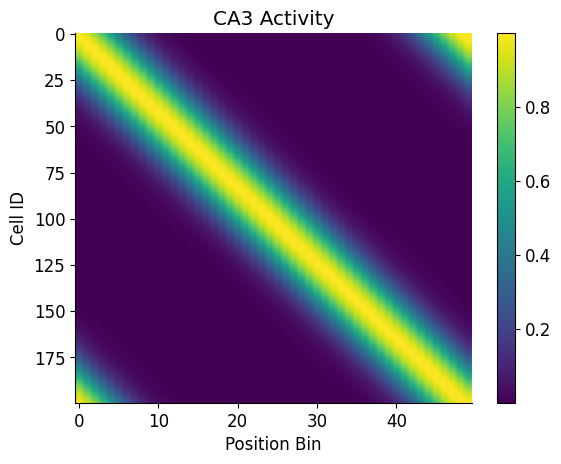

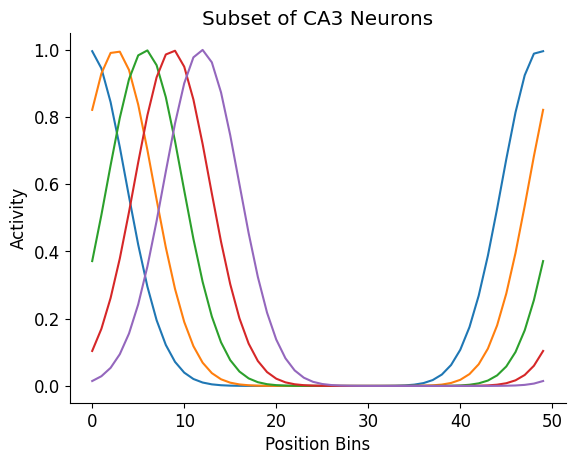

NameError: name 'residual_activity_dict_EC' is not defined

In [3]:


ca3_vs_position_all_cells_array = get_CA3_data(track_length = 180, num_cells=200)
plot_CA3(ca3_vs_position_all_cells_array)


EC_residuals_array = get_plot_EC(residual_activity_dict_EC)
    

NDNF_activity_list = get_synthetic_NDNF(EC_residuals_array, ca3_vs_position_all_cells_array, dist_type = "normal")
NDNF_activity_array = np.array(NDNF_activity_list)
sorted_NDNF_activity_array = np.argsort(np.argmax(NDNF_activity_array, axis=1))

plt.imshow(NDNF_activity_array[sorted_NDNF_activity_array, :], aspect='auto')
plt.title("Simulated NDNF Data as ECxCA3 Input")
plt.ylabel("Cell ID")
plt.xlabel("Position Bin")
plt.colorbar()
plt.show()

real_NDNF_list = []

for animal in fixed_residual_activity_dict_NDNF_newest:
    for cell in fixed_residual_activity_dict_NDNF_newest[animal]:
        real_NDNF_list.append(np.mean(fixed_residual_activity_dict_NDNF_newest[animal][cell], axis=1))
        
real_NDNF_array = np.array(real_NDNF_list)
sorted_real_NDNF_array = np.argsort(np.argmax(real_NDNF_array, axis=1))

plt.imshow(real_NDNF_array[sorted_real_NDNF_array, :], aspect='auto')
plt.title("Real NDNF Data")
plt.ylabel("Cell ID")
plt.xlabel("Position Bin")
plt.colorbar()
plt.show()



/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/finding_weights_over_NDNF_utils.py:269: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Input", y="MSE", data=df, inner="box", cut=0, palette=custom_palette)


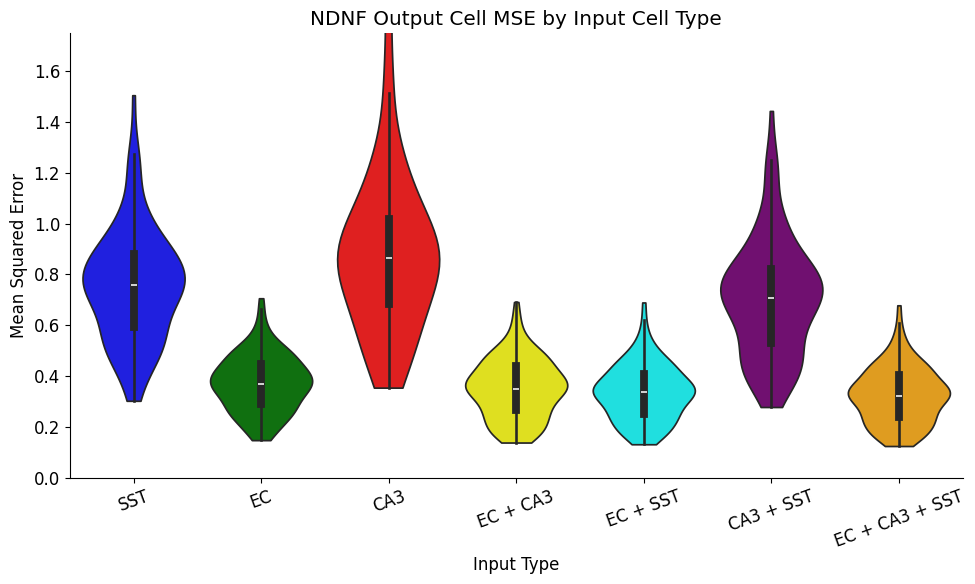

In [9]:

############### predicting NDNF where the inputs and MSE's are alll 2D trial by postion bin and therefore trial by trial variability across different mice which doesnt make sense 

#### pre flattened data arrays as input to NDNF 

EC_data_array = get_EC_data_array(residual_activity_dict_EC)
CA3_data_array = get_CA3_data_array(ca3_vs_position_all_cells_array)
SST_data_array = get_SST_data_array(activity_dict_SST, residual_activity_dict_SST)
EC_CA3_data_array = np.concatenate([EC_data_array, CA3_data_array], axis=0)
EC_CA3_data_array = np.concatenate([EC_data_array, CA3_data_array], axis=0)
EC_SST_data_array = np.concatenate([EC_data_array, SST_data_array], axis=0)
CA3_SST_data_array = np.concatenate([CA3_data_array, SST_data_array], axis=0)
EC_CA3_SST_data_array = np.concatenate([EC_data_array, CA3_data_array, SST_data_array], axis=0)

# ###### running all of the GLM's where various cell inputs try to predict NDNF output - will take some time

model_EC_just_CA3 = get_model_dict(CA3_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_just_SST = get_model_dict(SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_just_EC = get_model_dict(EC_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")

model_EC_EC_CA3 = get_model_dict(EC_CA3_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_EC_SST = get_model_dict(EC_SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_CA3_SST = get_model_dict(CA3_SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_CA3_SST = get_model_dict(CA3_SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")
model_EC_EC_CA3_SST = get_model_dict(EC_CA3_SST_data_array, fixed_residual_activity_dict_NDNF_newest, reg_type="ridge")

### calculating MSE of NDNF GLM prediction using other cell types as inputs vs real NDNF data  

MSE_list_just_SST, coefficients_list_just_SST = get_MSE_cell_type(model_EC_just_SST, fixed_residual_activity_dict_NDNF_newest, SST_data_array)
MSE_list_just_EC, coefficients_list_just_EC = get_MSE_cell_type(model_EC_just_EC, fixed_residual_activity_dict_NDNF_newest, EC_data_array)
MSE_list_just_CA3, coefficients_list_just_CA3 = get_MSE_cell_type(model_EC_just_CA3, fixed_residual_activity_dict_NDNF_newest, CA3_data_array)

MSE_list_EC_CA3, coefficients_list_EC_CA3 = get_MSE_cell_type(model_EC_EC_CA3, fixed_residual_activity_dict_NDNF_newest, EC_CA3_data_array)
MSE_list_EC_SST, coefficients_list_EC_SST = get_MSE_cell_type(model_EC_EC_SST, fixed_residual_activity_dict_NDNF_newest, EC_SST_data_array)
MSE_list_CA3_SST, coefficients_list_CA3_SST = get_MSE_cell_type(model_EC_CA3_SST, fixed_residual_activity_dict_NDNF_newest, CA3_SST_data_array)
MSE_list_EC_CA3_SST, coefficients_list_CA3_SST = get_MSE_cell_type(model_EC_EC_CA3_SST, fixed_residual_activity_dict_NDNF_newest, EC_CA3_SST_data_array)

inputs_list = ["SST", "EC", "CA3", "EC + CA3", "EC + SST", "CA3 + SST", "EC + CA3 + SST"]
plot_MSE_for_NDNF_pred_by_other_celltype_input(MSE_list_just_SST, MSE_list_just_EC, MSE_list_just_CA3, MSE_list_EC_CA3, MSE_list_EC_SST, MSE_list_CA3_SST, MSE_list_EC_CA3_SST, inputs_list, output_cell_type="NDNF Output")

# # ###### running all of the GLM's where various cell inputs try to predict NDNF output - will take some time


In [ ]:
######### make sure you only have positive weights off of EC
#### same thing for SST being negative weights

#### min max the data 

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/finding_weights_over_NDNF_utils.py:269: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Input", y="MSE", data=df, inner="box", cut=0, palette=custom_palette)


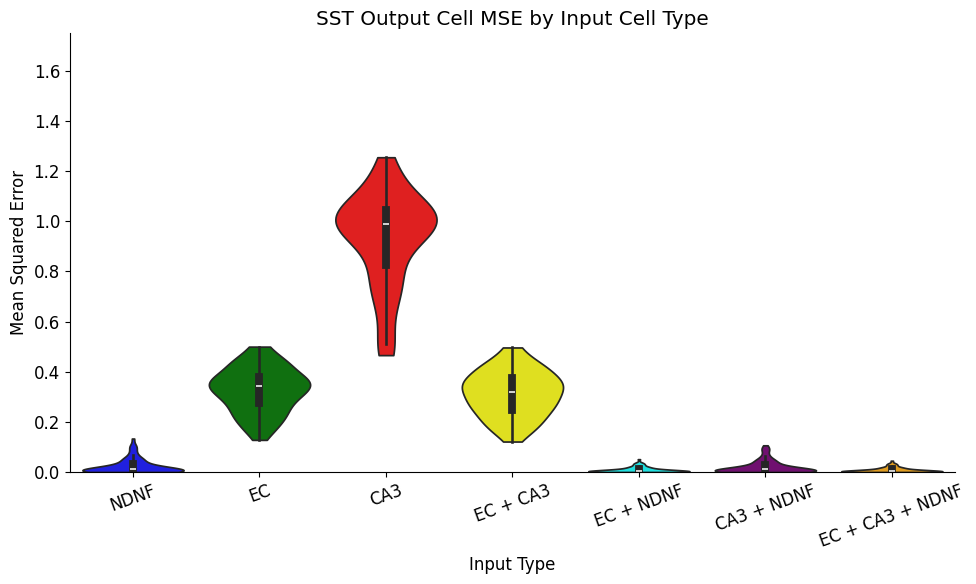

In [ ]:

EC_data_array = get_EC_data_array(residual_activity_dict_EC)
CA3_data_array = get_CA3_data_array(ca3_vs_position_all_cells_array)
NDNF_data_array = get_SST_data_array(fixed_activity_dict_NDNF_newest, residual_activity_dict_SST)
EC_CA3_data_array = np.concatenate([EC_data_array, CA3_data_array], axis=0)
EC_NDNF_data_array = np.concatenate([EC_data_array, NDNF_data_array], axis=0)
CA3_NDNF_data_array = np.concatenate([CA3_data_array, NDNF_data_array], axis=0)
EC_CA3_NDNF_data_array = np.concatenate([EC_data_array, CA3_data_array, NDNF_data_array], axis=0)


model_just_CA3 = get_model_dict(CA3_data_array, activity_dict_SST, reg_type="ridge")
model_just_NDNF = get_model_dict(NDNF_data_array, activity_dict_SST, reg_type="ridge")
model_just_EC = get_model_dict(EC_data_array, activity_dict_SST, reg_type="ridge")

model_EC_CA3 = get_model_dict(EC_CA3_data_array, activity_dict_SST, reg_type="ridge")
model_EC_NDNF = get_model_dict(EC_NDNF_data_array, activity_dict_SST, reg_type="ridge")
model_CA3_NDNF = get_model_dict(CA3_NDNF_data_array, activity_dict_SST, reg_type="ridge")
model_EC_CA3_NDNF = get_model_dict(EC_CA3_NDNF_data_array, activity_dict_SST, reg_type="ridge")

MSE_list_just_NDNF, coefficients_list_just_NDNF = get_MSE_cell_type(model_just_NDNF, activity_dict_SST, NDNF_data_array)
MSE_list_just_EC, coefficients_list_just_EC = get_MSE_cell_type(model_just_EC, activity_dict_SST, EC_data_array)
MSE_list_just_CA3, coefficients_list_just_CA3 = get_MSE_cell_type(model_just_CA3, activity_dict_SST, CA3_data_array)

MSE_list_EC_CA3, coefficients_list_EC_CA3 = get_MSE_cell_type(model_EC_CA3, activity_dict_SST, EC_CA3_data_array)
MSE_list_EC_NDNF, coefficients_list_EC_NDNF = get_MSE_cell_type(model_EC_NDNF, activity_dict_SST, EC_NDNF_data_array)
MSE_list_CA3_NDNF, coefficients_list_CA3_NDNF = get_MSE_cell_type(model_CA3_NDNF, activity_dict_SST, CA3_NDNF_data_array)
MSE_list_EC_CA3_NDNF, coefficients_list_CA3_NDNF = get_MSE_cell_type(model_EC_CA3_NDNF, activity_dict_SST, EC_CA3_NDNF_data_array)

inputs_list = ["NDNF", "EC", "CA3", "EC + CA3", "EC + NDNF", "CA3 + NDNF", "EC + CA3 + NDNF"]

plot_MSE_for_NDNF_pred_by_other_celltype_input(MSE_list_just_NDNF, MSE_list_just_EC, MSE_list_just_CA3, MSE_list_EC_CA3, MSE_list_EC_NDNF, MSE_list_CA3_NDNF, MSE_list_EC_CA3_NDNF, inputs_list, output_cell_type="SST Output")

In [ ]:
###### reason why ndnf input to sst output works but the reverse does not (SST input to predict NDNF output) is because the only thing we need to get a correlation is 2 cells that follow the same trend in activity might mean connectivity -- not every NDNF cell will peak at reward because not all will get 
# SST input therefore the SST input can only predict the activity of the NDNF cells that recieve SST input which is the minority --- therefore most info in the low MSE NDNF cells from SST input -- will they be the same ones that get most of the weighting when NDNF is an input 

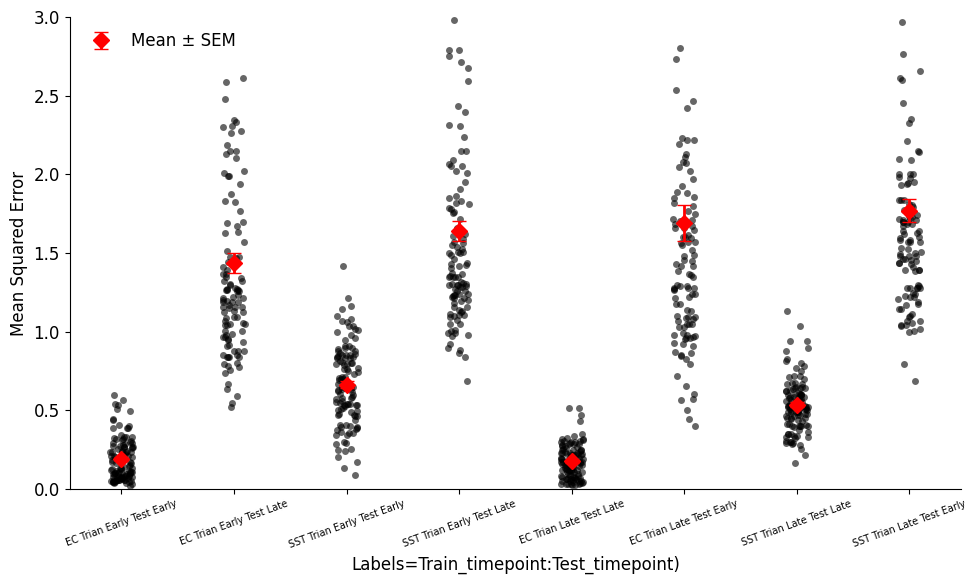

In [ ]:


############# early late split for predicting NDNF 


data_early_array_EC, data_late_array_EC = get_data_array_learning_split(activity_dict_EC)
data_early_array_SST, data_late_array_SST = get_data_array_learning_split(activity_dict_SST)
data_early_array_NDNF, data_late_array_NDNF = get_data_array_learning_split(fixed_activity_dict_NDNF_newest)



##### fit the model with early trials for the whole population of EC and a single NDNF cell which will be output and get a whole model dict 
model_EC_dict_early = get_model_dict_early_celltype_late_another_celltype(data_early_array_EC, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early")

#same thing for SST 
model_SST_dict_early = get_model_dict_early_celltype_late_another_celltype(data_early_array_SST, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early")

##### take the model trained on EC and NDNF early and then get a MSE of the precition of NDNF early vs real NDNF early activity 
MSE_list_EC_early_predicting_NDNF_late, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_early, fixed_activity_dict_NDNF_newest, data_late_array_EC, predict_early_or_late="Late")

##### take the model trained on EC and NDNF early and then get a MSE of the precition of NDNF early vs real NDNF early activity 
MSE_list_SST_early_predicting_NDNF_late, coefficients_list_EC_early = get_MSE_cell_type2(model_SST_dict_early, fixed_activity_dict_NDNF_newest, data_late_array_SST, predict_early_or_late="Late")

MSE_list_EC_early_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_early, fixed_activity_dict_NDNF_newest, data_early_array_EC, predict_early_or_late="early")

##### take the model trained on EC and NDNF early and then get a MSE of the precition of NDNF early vs real NDNF early activity 
MSE_list_SST_early_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_SST_dict_early, fixed_activity_dict_NDNF_newest, data_early_array_SST, predict_early_or_late="early")




##### fitting to late 
model_EC_dict_late = get_model_dict_early_celltype_late_another_celltype(data_late_array_EC, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="late")

# fitting to late 
model_SST_dict_late = get_model_dict_early_celltype_late_another_celltype(data_late_array_SST, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="late")

### fit on late and predict late 
MSE_list_EC_late_predicting_NDNF_late, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_late, fixed_activity_dict_NDNF_newest, data_late_array_EC, predict_early_or_late="Late")

### fit on late and predict late
MSE_list_SST_late_predicting_NDNF_late, coefficients_list_EC_early = get_MSE_cell_type2(model_SST_dict_late, fixed_activity_dict_NDNF_newest, data_late_array_SST, predict_early_or_late="Late")



### fit on late and predict early
MSE_list_EC_late_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_late, fixed_activity_dict_NDNF_newest, data_early_array_EC, predict_early_or_late="early")

## ### fit on late and predict early
MSE_list_SST_late_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_SST_dict_late, fixed_activity_dict_NDNF_newest, data_early_array_SST, predict_early_or_late="early")


data_list = [MSE_list_EC_early_predicting_NDNF_early, MSE_list_EC_early_predicting_NDNF_late, MSE_list_SST_early_predicting_NDNF_early, MSE_list_SST_early_predicting_NDNF_late, MSE_list_EC_late_predicting_NDNF_late, MSE_list_EC_late_predicting_NDNF_early, MSE_list_SST_late_predicting_NDNF_late, MSE_list_SST_late_predicting_NDNF_early]
input_titles = ["EC Trian Early Test Early", "EC Trian Early Test Late", "SST Trian Early Test Early", "SST Trian Early Test Late", "EC Trian Late Test Late", "EC Trian Late Test Early", "SST Trian Late Test Late", "SST Trian Late Test Early"]

plot_models_trained_early_late(data_list, input_titles)



In [ ]:
##### fit the model with early trials for the whole population of EC and a single SST cell which will be output and get a whole model dict 
model_EC_dict_early_SST_output = get_model_dict_early_celltype_late_another_celltype(data_early_array_EC, activity_dict_SST, reg_type="ridge")

#same thing for SST 
model_NDNF_dict_early_SST_output = get_model_dict_early_celltype_late_another_celltype(data_early_array_SST, activity_dict_SST, reg_type="ridge")



##### take the model trained on EC and NDNF early and then get a MSE of the precition of NDNF early vs real NDNF early activity 
MSE_list_EC_early_predicting_NDNF_late, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_early, fixed_activity_dict_NDNF_newest, data_late_array_EC, predict_early_or_late="Late")

##### take the model trained on EC and NDNF early and then get a MSE of the precition of NDNF early vs real NDNF early activity 
MSE_list_SST_early_predicting_NDNF_late, coefficients_list_EC_early = get_MSE_cell_type2(model_SST_dict_early, fixed_activity_dict_NDNF_newest, data_late_array_SST, predict_early_or_late="Late")


MSE_list_EC_early_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_EC_dict_early, fixed_activity_dict_NDNF_newest, data_early_array_EC, predict_early_or_late="early")

##### take the model trained on EC and NDNF early and then get a MSE of the precition of NDNF early vs real NDNF early activity 
MSE_list_SST_early_predicting_NDNF_early, coefficients_list_EC_early = get_MSE_cell_type2(model_SST_dict_early, fixed_activity_dict_NDNF_newest, data_early_array_SST, predict_early_or_late="early")



In [ ]:
###### analysis methodn and the question it answers 

(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/finding_weights_over_NDNF_utils.py:785: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Input", y="MSE", data=df, inner="box", cut=0, palette=custom_palette)


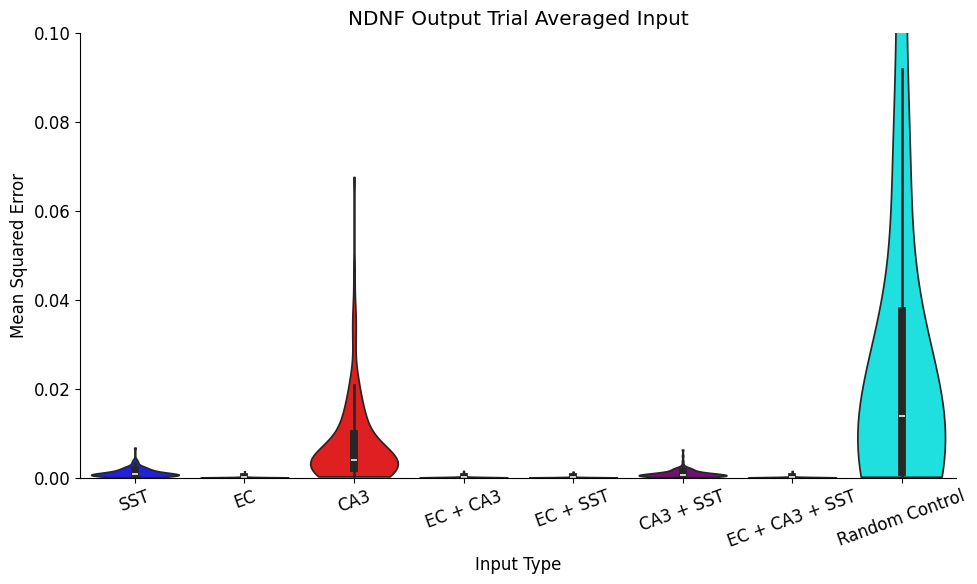

In [ ]:
def get_MSE_cell_type_TA(model_EC_just_SST, fixed_residual_activity_dict_NDNF_newest, SST_data_array):
    MSE_list = []
    coefficients_list = []
    prediction_list =[]
    activity_list = []
    for animal in model_EC_just_SST:
        for cell in model_EC_just_SST[animal]:
            model = model_EC_just_SST[animal][cell]
            neuron_activity = np.mean(fixed_residual_activity_dict_NDNF_newest[animal][cell], axis=1)
            # print(f"neuron_activity.shape {neuron_activity.shape}")
            coefficients = model.coef_
            coefficients_list.append(coefficients)
            neuron_predicted_activity = model.predict(SST_data_array.T)
            neuron_predicted_activity_array = np.array(neuron_predicted_activity)
            prediction_list.append(neuron_predicted_activity_array)
            activity_list.append(neuron_activity)
            # print(f"neuron_predicted_activity {neuron_predicted_activity.shape}")
            # predicted_NDNF = neuron_predicted_activity.reshape(neuron_activity.shape)
            MSE = np.mean(np.square(neuron_predicted_activity - neuron_activity))
            MSE_list.append(MSE) 
            
    return MSE_list, coefficients_list, prediction_list, activity_list


# SST_data_array_late = get_activity_late(activity_dict_SST, start=40, end=60)
SST_data_array_TA = get_activity_av_all_trials(activity_dict_SST)

# EC_data_array_late = get_activity_late(activity_dict_EC, start=30, end=50)
EC_data_array_TA = get_activity_av_all_trials(activity_dict_EC)

# NDNF_data_array_late = get_activity_late(fixed_activity_dict_NDNF_newest, start=40, end=60)
NDNF_data_array_TA = get_activity_av_all_trials(fixed_activity_dict_NDNF_newest)

EC_CA3_data_array_TA = np.concatenate([EC_data_array_TA, ca3_vs_position_all_cells_array], axis=0)
EC_SST_data_array_TA = np.concatenate([EC_data_array_TA, SST_data_array_TA], axis=0)
CA3_SST_data_array_TA = np.concatenate([ca3_vs_position_all_cells_array, SST_data_array_TA], axis=0)
EC_CA3_SST_data_array_TA = np.concatenate([EC_data_array_TA, ca3_vs_position_all_cells_array, SST_data_array_TA], axis=0)

rand_tens = np.random.rand(792, 58, 50)
rand_tens_TA = np.mean(rand_tens, axis=1)

model_just_CA3 = get_model_dict_split(ca3_vs_position_all_cells_array, fixed_residual_activity_dict_NDNF_newest, start=20, end=58, reg_type="ridge", early=True)
model_just_SST = get_model_dict_split(SST_data_array_TA, fixed_residual_activity_dict_NDNF_newest, start=20, end=58, reg_type="ridge", early=True)
model_just_EC = get_model_dict_split(EC_data_array_TA, fixed_residual_activity_dict_NDNF_newest, start=20, end=58, reg_type="ridge", early=True)

model_EC_CA3 = get_model_dict_split(EC_CA3_data_array_TA, fixed_residual_activity_dict_NDNF_newest, start=20, end=58, reg_type="ridge", early=True)
model_EC_SST = get_model_dict_split(EC_SST_data_array_TA, fixed_residual_activity_dict_NDNF_newest, start=20, end=58, reg_type="ridge", early=True)
model_CA3_SST = get_model_dict_split(CA3_SST_data_array_TA, fixed_residual_activity_dict_NDNF_newest, start=20, end=58, reg_type="ridge", early=True)
model_EC_CA3_SST = get_model_dict_split(EC_CA3_SST_data_array_TA, fixed_residual_activity_dict_NDNF_newest, start=20, end=58, reg_type="ridge", early=True)

model_random = get_model_dict_split(rand_tens_TA, activity_dict_SST, start=20, end=58, reg_type="ridge", early=True)

MSE_list_just_SST, coefficients_list_just_SST, predicted_SST, raw_SST = get_MSE_cell_type_TA(model_just_SST, fixed_residual_activity_dict_NDNF_newest, SST_data_array_TA)
MSE_list_just_EC, coefficients_list_just_EC, predicted_EC, raw_EC = get_MSE_cell_type_TA(model_just_EC, fixed_residual_activity_dict_NDNF_newest, EC_data_array_TA)
MSE_list_just_CA3, coefficients_list_just_CA3, predicted_CA3, raw_CA3 = get_MSE_cell_type_TA(model_just_CA3, fixed_residual_activity_dict_NDNF_newest, ca3_vs_position_all_cells_array)

MSE_list_EC_CA3, coefficients_list_EC_CA3, predicted_EC_CA3, raw_EC_CA3 = get_MSE_cell_type_TA(model_EC_CA3, fixed_residual_activity_dict_NDNF_newest, EC_CA3_data_array_TA)
MSE_list_EC_SST, coefficients_list_EC_SST, predicted_EC_SST, raw_EC_SST = get_MSE_cell_type_TA(model_EC_SST, fixed_residual_activity_dict_NDNF_newest, EC_SST_data_array_TA)
MSE_list_CA3_SST, coefficients_list_CA3_SST, predicted_CA3_SST, raw_CA3_SST = get_MSE_cell_type_TA(model_CA3_SST, fixed_residual_activity_dict_NDNF_newest, CA3_SST_data_array_TA)
MSE_list_EC_CA3_SST, coefficients_list_CA3_SST, predicted_EC_CA3_SST, raw_EC_CA3_SST = get_MSE_cell_type_TA(model_EC_CA3_SST, fixed_residual_activity_dict_NDNF_newest, EC_CA3_SST_data_array_TA)
MSE_list_random_TA, coefficients_list_random, predicted_random, raw_random = get_MSE_cell_type_TA(model_random, activity_dict_SST, rand_tens_TA)

inputs_list = ["SST", "EC", "CA3", "EC + CA3", "EC + SST", "CA3 + SST", "EC + CA3 + SST", "Random Control"]

plot_MSE_for_NDNF_pred_by_other_celltype_input_random(MSE_list_just_SST, MSE_list_just_EC, MSE_list_just_CA3, MSE_list_EC_CA3, MSE_list_EC_SST, MSE_list_CA3_SST, MSE_list_EC_CA3_SST, MSE_list_random_TA, inputs_list, output_cell_type="NDNF Output Trial Averaged Input", ymax=0.1)



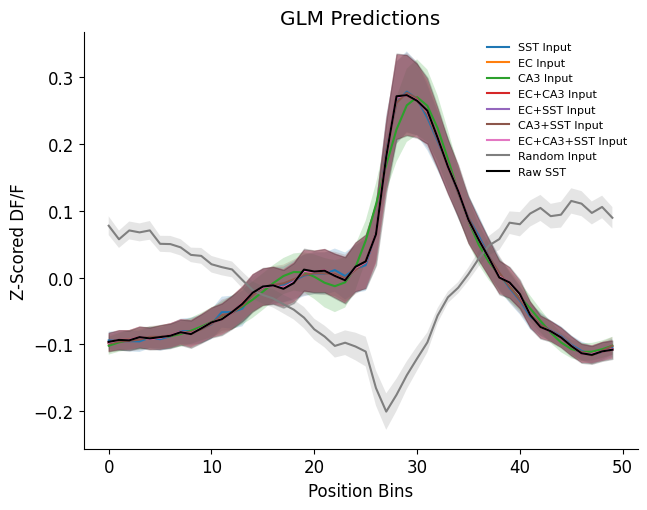

In [ ]:
def get_TA_act(residual_activity_dict_SST):
    data_list = []
    for animal in residual_activity_dict_SST:
        for cell in residual_activity_dict_SST[animal]:
            data_list.append(np.mean(residual_activity_dict_SST[animal][cell], axis=1))

    real_data_array = np.array(data_list)
    return real_data_array

real_data_array_NDNF = get_TA_act(fixed_residual_activity_dict_NDNF_newest)

def plot_the_goods(predicted_SST, labels="SST Input", raw=False):
    predicted_SST_array = np.array(predicted_SST)
    mean_predicted_SST_array = np.mean(predicted_SST_array, axis=0)
    sem_predicted_SST_array = sem(predicted_SST_array, axis=0)

    if raw:
        plt.plot(mean_predicted_SST_array, label=labels, color='k')
        plt.fill_between(range(len(mean_predicted_SST_array)), mean_predicted_SST_array+sem_predicted_SST_array, mean_predicted_SST_array-sem_predicted_SST_array, alpha=0.2, color='k')
    else:
        plt.plot(mean_predicted_SST_array, label=labels)
        plt.fill_between(range(len(mean_predicted_SST_array)), mean_predicted_SST_array+sem_predicted_SST_array, mean_predicted_SST_array-sem_predicted_SST_array, alpha=0.2)

plot_the_goods(predicted_SST, labels="SST Input")
plot_the_goods(predicted_EC, labels="EC Input")
plot_the_goods(predicted_CA3, labels="CA3 Input")
plot_the_goods(predicted_EC_CA3, labels="EC+CA3 Input")
plot_the_goods(predicted_EC_SST, labels="EC+SST Input")
plot_the_goods(predicted_CA3_SST, labels="CA3+SST Input")
plot_the_goods(predicted_EC_CA3_SST, labels="EC+CA3+SST Input")
plot_the_goods(predicted_random, labels="Random Input")
plot_the_goods(real_data_array_NDNF, labels="Raw SST", raw=True)

plt.legend(fontsize=8)
plt.tight_layout()
plt.ylabel('Z-Scored DF/F')
plt.xlabel('Position Bins')
plt.title("GLM Predictions")
plt.show()

In [9]:
######## trying it with trial averaged data 

plot_NDNF_prediction_from_other_celltypes_input_GLM(activity_dict_SST, activity_dict_EC, fixed_activity_dict_NDNF_newest, ymax=0.10)

NameError: name 'plot_NDNF_prediction_from_other_celltypes_input_GLM' is not defined

(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50)
(50,)
(200, 50

/Users/michaelfinch/CA1-interneuron-GLM/Clean_notebooks_to_date/finding_weights_over_NDNF_utils.py:648: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Input", y="MSE", data=df, inner="box", cut=0, palette=custom_palette)


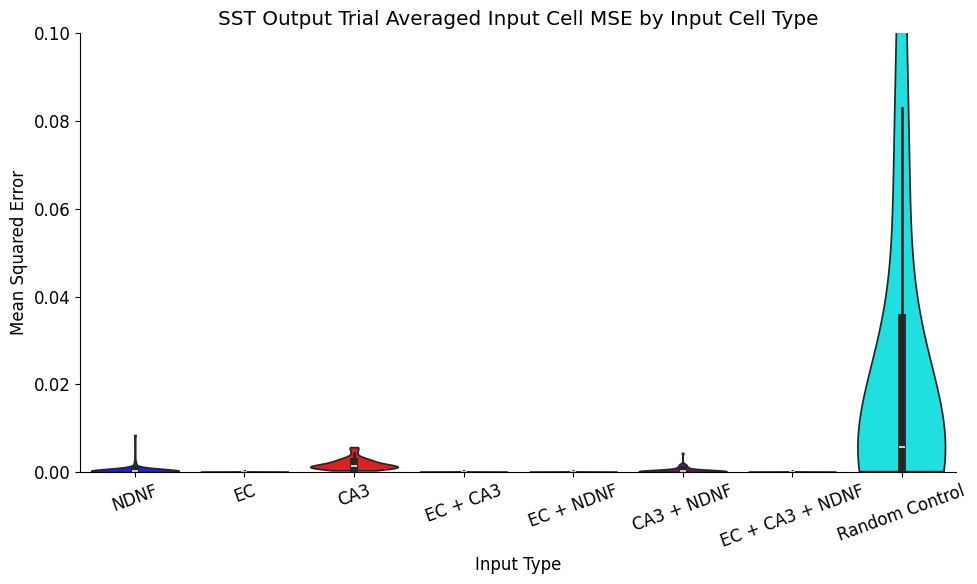

In [ ]:
######## trying it with trial averaged data 

plot_SST_prediction_from_other_celltypes_input_GLM(activity_dict_SST, activity_dict_EC, fixed_activity_dict_NDNF_newest, ymax=0.10)


In [6]:
def split_data_by_cp(activity_dict_EC, cp_dict_EC):
    early_cp_dict={}
    late_cp_dict={}

    for idx, animal in enumerate(activity_dict_EC):
        early_cell_cp_dict={}
        late_cell_cp_dict={}
        for id, cell in enumerate(activity_dict_EC[animal]):
            data = activity_dict_EC[animal][cell]
            cp = cp_dict_EC[idx][id]
            early_cp = cp[0]
            late_cp = cp[1]
            data_early = data[:,:early_cp]
            data_late = data[:,late_cp:]
            early_cell_cp_dict[cell] = data_early
            late_cell_cp_dict[cell] = data_late

        early_cp_dict[animal] = early_cell_cp_dict
        late_cp_dict[animal] = late_cell_cp_dict

    return early_cp_dict, late_cp_dict



early_cp_dict_EC, late_cp_dict_EC = split_data_by_cp(activity_dict_EC, cp_dict_EC)
early_cp_dict_SST, late_cp_dict_SST = split_data_by_cp(activity_dict_SST, cp_dict_SST)
early_cp_dict_NDNF, late_cp_dict_NDNF = split_data_by_cp(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)




early_cp_dict_EC, late_cp_dict_EC = split_data_by_cp(activity_dict_EC, cp_dict_EC)
early_cp_dict_SST, late_cp_dict_SST = split_data_by_cp(activity_dict_SST, cp_dict_SST)
early_cp_dict_NDNF, late_cp_dict_NDNF = split_data_by_cp(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)

early_cp_dicts = [early_cp_dict_EC, early_cp_dict_SST, early_cp_dict_NDNF]
late_cp_dicts = [late_cp_dict_EC, late_cp_dict_SST, late_cp_dict_NDNF]


NameError: name 'cp_dict_EC' is not defined

In [ ]:
def get_MSE_cell_type_TA(model_EC_just_SST, fixed_residual_activity_dict_NDNF_newest, SST_data_array):
    MSE_list = []
    coefficients_list = []
    prediction_list =[]
    activity_list = []
    for animal in model_EC_just_SST:
        for cell in model_EC_just_SST[animal]:
            model = model_EC_just_SST[animal][cell]
            neuron_activity = np.mean(fixed_residual_activity_dict_NDNF_newest[animal][cell], axis=1)
            # print(f"neuron_activity.shape {neuron_activity.shape}")
            coefficients = model.coef_
            coefficients_list.append(coefficients)
            neuron_predicted_activity = model.predict(SST_data_array.T)
            neuron_predicted_activity_array = np.array(neuron_predicted_activity)
            prediction_list.append(neuron_predicted_activity_array)
            activity_list.append(neuron_activity)
            # print(f"neuron_predicted_activity {neuron_predicted_activity.shape}")
            # predicted_NDNF = neuron_predicted_activity.reshape(neuron_activity.shape)
            MSE = np.mean(np.square(neuron_predicted_activity - neuron_activity))
            MSE_list.append(MSE) 
            
    return MSE_list, coefficients_list, prediction_list, activity_list

In [10]:
mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_SST_model_ranks20_contig_x00_cells"
cell_SST_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/cell_EC_model_ranks20_contig_x00_cells"
cell_EC_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)

mse_dir = "/Users/michaelfinch/CA1-interneuron-GLM/datasets/real_final_NDNF_model_ranks20_contig_x00_cell"
cell_NDNF_model_ranks20_contig_x00 = get_model_data_per_cell(mse_dir)


fixed_model_dict_NDNF_newest = get_fixed_model_dict_NDNF_newest(cell_NDNF_model_ranks20_contig_x00)



cp_dict_EC = get_cp_dict(cell_EC_model_ranks20_contig_x00)
cp_dict_NDNF = get_cp_dict(fixed_model_dict_NDNF_newest)
cp_dict_SST = get_cp_dict(cell_SST_model_ranks20_contig_x00)

Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [12]:
SST_data_array_late_TA = get_activity_late(activity_dict_SST, cp_dict_SST)
SST_data_array_early_TA = get_activity_early(activity_dict_SST, cp_dict_SST)

EC_data_array_late_TA = get_activity_late(activity_dict_EC, cp_dict_EC)
EC_data_array_early_TA = get_activity_early(activity_dict_EC, cp_dict_EC)

NDNF_data_array_late_TA = get_activity_late(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)
NDNF_data_array_early_TA = get_activity_early(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)

EC_CA3_data_array_TA_early = np.concatenate([EC_data_array_early_TA, ca3_vs_position_all_cells_array], axis=0)
EC_CA3_data_array_TA_late = np.concatenate([EC_data_array_late_TA, ca3_vs_position_all_cells_array], axis=0)

EC_SST_data_array_TA_early = np.concatenate([EC_data_array_early_TA, SST_data_array_early_TA], axis=0)
EC_SST_data_array_TA_late = np.concatenate([EC_data_array_late_TA, SST_data_array_late_TA], axis=0)

CA3_SST_data_array_TA_early = np.concatenate([ca3_vs_position_all_cells_array, SST_data_array_early_TA], axis=0)
CA3_SST_data_array_TA_late = np.concatenate([ca3_vs_position_all_cells_array, SST_data_array_late_TA], axis=0)


######## train early, test early EC
model_EC_dict_early_TA = get_model_dict_early_celltype_late_another_celltype_TA(EC_data_array_early_TA, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early", start=0, end=20)
MSE_list_EC_early_NDNF_early, coefficients_list_EC_early_NDNF_early, prediction_list_EC_early_NDNF_early, activity_list_EC_early_NDNF_early = get_MSE_cell_type_TA(model_EC_dict_early_TA, fixed_activity_dict_NDNF_newest, EC_data_array_early_TA)


######## train early, test early SST
model_SST_dict_early_TA = get_model_dict_early_celltype_late_another_celltype_TA(SST_data_array_early_TA, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early", start=0, end=20)
MSE_list_SST_early_NDNF_early, coefficients_list_SST_early_NDNF_early, prediction_list_SST_early_NDNF_early, activity_list_SST_early_NDNF_early = get_MSE_cell_type_TA(model_SST_dict_early_TA, fixed_activity_dict_NDNF_newest, SST_data_array_early_TA)


######## train early, test early CA3
model_CA3_dict_early_TA = get_model_dict_early_celltype_late_another_celltype_TA(ca3_vs_position_all_cells_array, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early", start=0, end=20)
MSE_list_CA3_early_NDNF_early, coefficients_list_CA3_early_NDNF_early, prediction_list_CA3_early_NDNF_early, activity_list_CA3_early_NDNF_early = get_MSE_cell_type_TA(model_CA3_dict_early_TA, fixed_activity_dict_NDNF_newest, ca3_vs_position_all_cells_array)



# model_EC_CA3_dict_early_TA = get_model_dict_early_celltype_late_another_celltype_TA(EC_CA3_data_array_TA_early, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early", start=0, end=20)
# MSE_list_EC_CA3_early_predicting_NDNF_late_TA, coefficients_list_EC_early = get_MSE_cell_type_TA(model_EC_CA3_dict_early_TA, fixed_activity_dict_NDNF_newest, EC_CA3_data_array_TA_late)
# MSE_list_EC_CA3_early_predicting_NDNF_early_TA, coefficients_list_EC_early = get_MSE_cell_type_TA(model_EC_CA3_dict_early_TA, fixed_activity_dict_NDNF_newest, EC_CA3_data_array_TA_early)


# model_EC_SST_dict_early_TA = get_model_dict_early_celltype_late_another_celltype_TA(EC_SST_data_array_TA_early, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early", start=0, end=20)
# MSE_list_EC_SST_early_predicting_NDNF_late_TA, coefficients_list_EC_early = get_MSE_cell_type_TA(model_EC_SST_dict_early_TA, fixed_activity_dict_NDNF_newest, EC_SST_data_array_TA_late)
# MSE_list_EC_SST_early_predicting_NDNF_early_TA, coefficients_list_EC_early = get_MSE_cell_type_TA(model_EC_SST_dict_early_TA, fixed_activity_dict_NDNF_newest, EC_SST_data_array_TA_early)


# model_CA3_SST_dict_early_TA = get_model_dict_early_celltype_late_another_celltype_TA(CA3_SST_data_array_TA_early, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early", start=0, end=20)
# MSE_list_CA3_SST_early_predicting_NDNF_late_TA, coefficients_list_EC_early = get_MSE_cell_type_TA(model_CA3_SST_dict_early_TA, fixed_activity_dict_NDNF_newest, CA3_SST_data_array_TA_late)
# MSE_list_CA3_SST_early_predicting_NDNF_early_TA, coefficients_list_EC_early = get_MSE_cell_type_TA(model_CA3_SST_dict_early_TA, fixed_activity_dict_NDNF_newest, CA3_SST_data_array_TA_early)



In [13]:
######## train late, test late EC
model_EC_dict_late_TA = get_model_dict_early_celltype_late_another_celltype_TA(EC_data_array_late_TA, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="late", start=38, end=58)
MSE_list_EC_late_NDNF_late, coefficients_list_EC_late_NDNF_late, prediction_list_EC_late_NDNF_late, activity_list_EC_late_NDNF_late = get_MSE_cell_type_TA(model_EC_dict_late_TA, fixed_activity_dict_NDNF_newest, EC_data_array_late_TA)


######## train late, test late SST
model_SST_dict_late_TA = get_model_dict_early_celltype_late_another_celltype_TA(SST_data_array_late_TA, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="late", start=38, end=58)
MSE_list_SST_late_NDNF_late, coefficients_list_SST_late_NDNF_late, prediction_list_SST_late_NDNF_late, activity_list_SST_late_NDNF_late = get_MSE_cell_type_TA(model_SST_dict_late_TA, fixed_activity_dict_NDNF_newest, SST_data_array_late_TA)


######## train late, test late CA3
model_CA3_dict_late_TA = get_model_dict_early_celltype_late_another_celltype_TA(ca3_vs_position_all_cells_array, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="late", start=38, end=58)
MSE_list_CA3_late_NDNF_late, coefficients_list_CA3_late_NDNF_late, prediction_list_CA3_late_NDNF_late, activity_list_CA3_late_NDNF_late = get_MSE_cell_type_TA(model_CA3_dict_late_TA, fixed_activity_dict_NDNF_newest, ca3_vs_position_all_cells_array)


 max 1.0644853471894677 min -1.0662425613993551


(array([1.000e+00, 0.000e+00, 1.000e+00, 4.000e+00, 7.000e+00, 4.000e+01,
        1.270e+02, 3.480e+02, 1.009e+03, 2.552e+03, 2.745e+03, 1.193e+03,
        3.910e+02, 1.330e+02, 4.900e+01, 1.600e+01, 5.000e+00, 1.000e+00,
        2.000e+00, 1.000e+00]),
 array([-1.06624256e+00, -9.59706166e-01, -8.53169771e-01, -7.46633375e-01,
        -6.40096980e-01, -5.33560584e-01, -4.27024189e-01, -3.20487793e-01,
        -2.13951398e-01, -1.07415003e-01, -8.78607105e-04,  1.05657788e-01,
         2.12194184e-01,  3.18730579e-01,  4.25266975e-01,  5.31803370e-01,
         6.38339765e-01,  7.44876161e-01,  8.51412556e-01,  9.57948952e-01,
         1.06448535e+00]),
 <BarContainer object of 20 artists>)

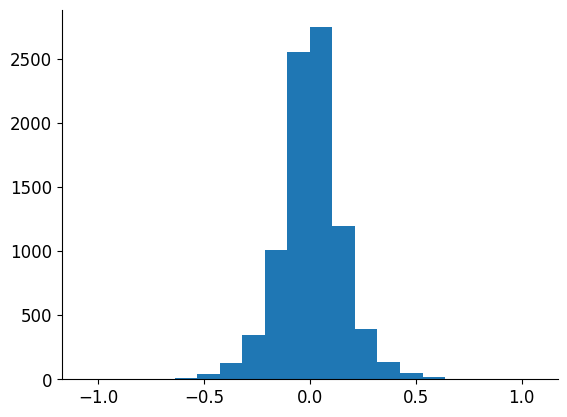

In [27]:
difference_list = []
for i in range(len(coefficients_list_SST_early_NDNF_early)):
    early_coeff = coefficients_list_SST_early_NDNF_early[i]
    late_coeff = coefficients_list_SST_late_NDNF_late[i]

    difference = early_coeff - late_coeff
    difference_list.append(difference)

difference_array = np.array(difference_list)
difference_array_flat = difference_array.flatten()

print(f" max {np.max(difference_array)} min {np.min(difference_array)}")

plt.hist(difference_array_flat, bins=20)

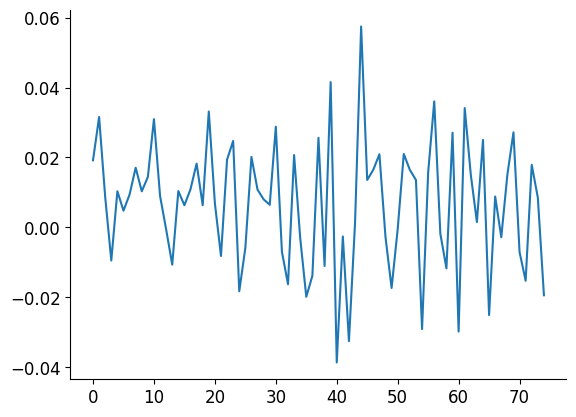

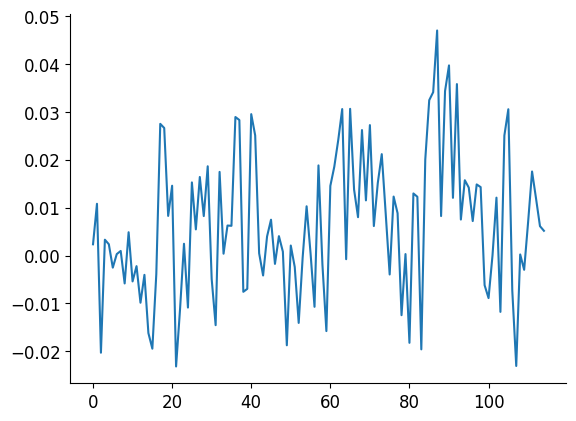

In [29]:
difference_array.shape
av_over_ndnf = np.mean(difference_array, axis=0)
av_over_sst = np.mean(difference_array, axis=1)

plt.plot(av_over_ndnf)
plt.show()

plt.plot(av_over_sst)
plt.show()


Text(0.5, 1.0, 'NDNF Cell 1 Coefficients over SST Cell Inputs')

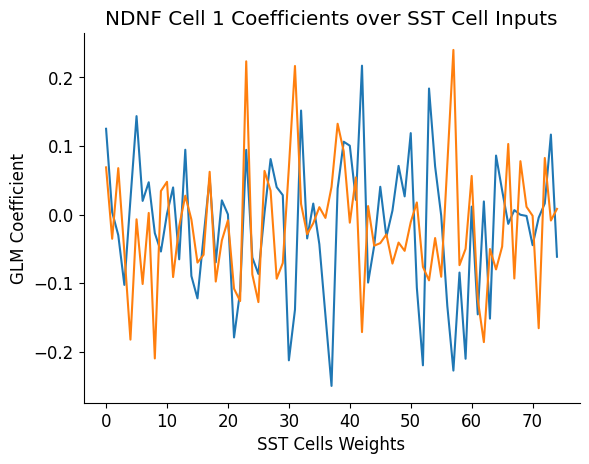

In [14]:
plt.plot(coefficients_list_SST_early_NDNF_early[0], label='Early Predict Early')
plt.plot(coefficients_list_SST_late_NDNF_late[0], label='Late Predict Late')
plt.xlabel("SST Cells Weights")
plt.ylabel("GLM Coefficient")
plt.title("NDNF Cell 1 Coefficients over SST Cell Inputs")

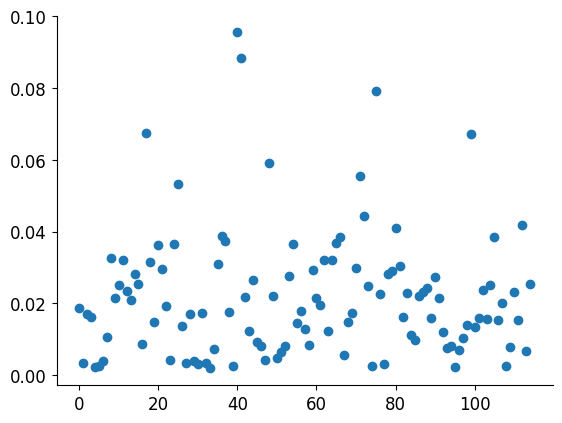

In [ ]:
MSE_list = []

for i in range(len(coefficients_list_SST_early_NDNF_early)):    
    MSE = np.mean(np.square(coefficients_list_SST_early_NDNF_early[i] - coefficients_list_SST_late_NDNF_late[i]))
    MSE_list.append(MSE)

plt.scatter(range(len(MSE_list)), MSE_list)
plt.xlabel("NDNF Cell")
plt.ylabel("MSE of Coefficients Early vs Late")


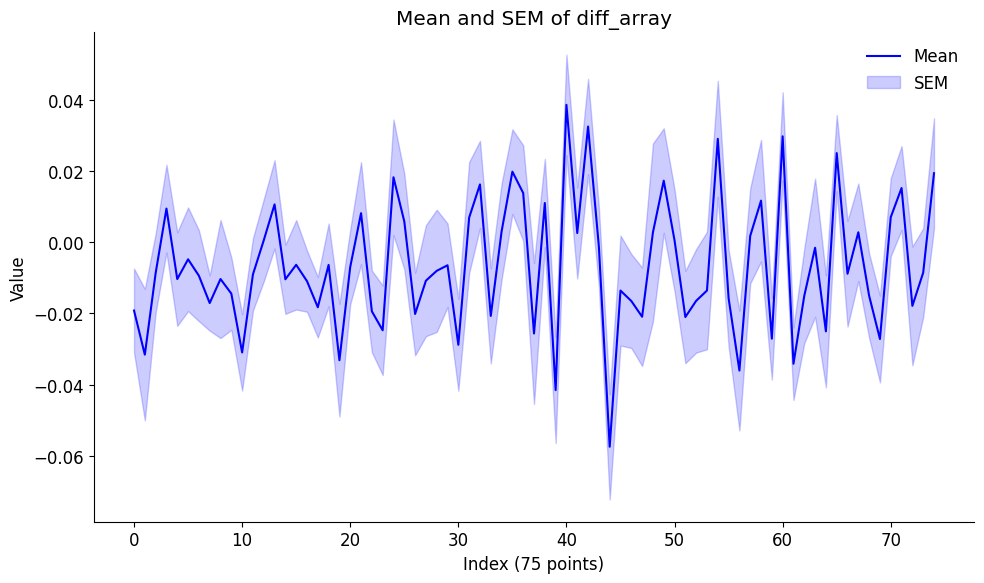

In [ ]:
diff_list = []
for i in range(len(coefficients_list_SST_early_NDNF_early)):
    data = np.array([coefficients_list_SST_early_NDNF_early[i], coefficients_list_SST_late_NDNF_late[i]])
    data.shape
    diff = np.diff(data, axis=0)
    diff_list.append(diff)

diff_array = np.array(diff_list)
diff_array = np.mean(diff_array, axis=1)
diff_array.shape

# Calculate mean and SEM along axis 0
mean_diff = np.mean(diff_array, axis=0)
sem_diff = sem(diff_array, axis=0)

# Plot the mean with SEM as error bars
plt.figure(figsize=(10, 6))
plt.plot(mean_diff, label='Mean', color='blue')
plt.fill_between(range(len(mean_diff)), mean_diff - sem_diff, mean_diff + sem_diff, color='blue', alpha=0.2, label='SEM')

# Add labels and title
plt.xlabel('Index (75 points)')
plt.ylabel('Value')
plt.title('Mean and SEM of diff_array')
plt.legend()
plt.tight_layout()
plt.show()

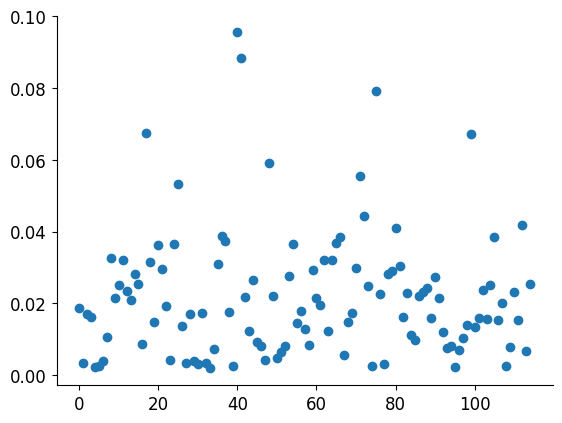

In [ ]:
MSE_list = []

for i in range(len(coefficients_list_SST_early_NDNF_early)):   
    diff_list = [] 
    for j in range(len(coefficients_list_SST_early_NDNF_early[i])):
        diff = coefficients_list_SST_early_NDNF_early[i][j]

# plt.scatter(range(len(MSE_list)), MSE_list)
# plt.xlabel("NDNF Cell")
# plt.ylabel("MSE of Coefficients Early vs Late")


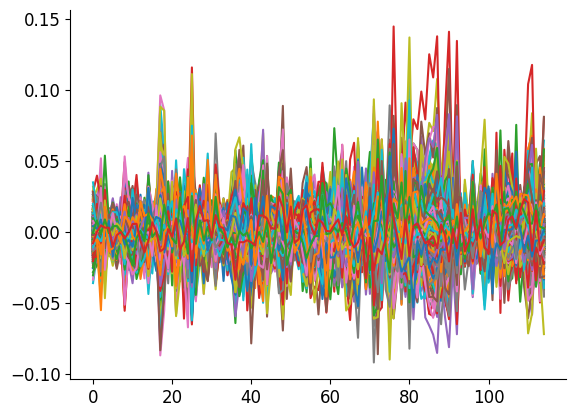

In [ ]:
plt.plot(coefficients_list_EC_early_NDNF_early, label='early')
plt.plot(coefficients_list_EC_late_NDNF_late, label='late')

In [ ]:
SST_data_array_late_TA = get_activity_late(activity_dict_SST, cp_dict_SST)
SST_data_array_early_TA = get_activity_early(activity_dict_SST, cp_dict_SST)

EC_data_array_late_TA = get_activity_late(activity_dict_EC, cp_dict_EC)
EC_data_array_early_TA = get_activity_early(activity_dict_EC, cp_dict_EC)

NDNF_data_array_late_TA = get_activity_late(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)
NDNF_data_array_early_TA = get_activity_early(fixed_activity_dict_NDNF_newest, cp_dict_NDNF)

EC_CA3_data_array_TA_early = np.concatenate([EC_data_array_early_TA, ca3_vs_position_all_cells_array], axis=0)
EC_CA3_data_array_TA_late = np.concatenate([EC_data_array_late_TA, ca3_vs_position_all_cells_array], axis=0)

EC_SST_data_array_TA_early = np.concatenate([EC_data_array_early_TA, SST_data_array_early_TA], axis=0)
EC_SST_data_array_TA_late = np.concatenate([EC_data_array_late_TA, SST_data_array_late_TA], axis=0)

CA3_SST_data_array_TA_early = np.concatenate([ca3_vs_position_all_cells_array, SST_data_array_early_TA], axis=0)
CA3_SST_data_array_TA_late = np.concatenate([ca3_vs_position_all_cells_array, SST_data_array_late_TA], axis=0)


######## train early, test early EC
model_EC_dict_early_TA = get_model_dict_early_celltype_late_another_celltype_TA(EC_data_array_early_TA, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early", start=0, end=20)
MSE_list_EC_early_NDNF_early, coefficients_list, prediction_list, activity_list = get_MSE_cell_type_TA(model_EC_dict_early_TA, fixed_activity_dict_NDNF_newest, EC_data_array_early_TA)


######## train early, test early SST
model_SST_dict_early_TA = get_model_dict_early_celltype_late_another_celltype_TA(SST_data_array_early_TA, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early", start=0, end=20)
MSE_list, coefficients_list, prediction_list, activity_list = get_MSE_cell_type_TA(model_SST_dict_early_TA, fixed_activity_dict_NDNF_newest, SST_data_array_early_TA)


######## train early, test early CA3
model_CA3_dict_early_TA = get_model_dict_early_celltype_late_another_celltype_TA(ca3_vs_position_all_cells_array, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early", start=0, end=20)
MSE_list, coefficients_list, prediction_list, activity_list = get_MSE_cell_type_TA(model_CA3_dict_early_TA, fixed_activity_dict_NDNF_newest, ca3_vs_position_all_cells_array)



# model_EC_CA3_dict_early_TA = get_model_dict_early_celltype_late_another_celltype_TA(EC_CA3_data_array_TA_early, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early", start=0, end=20)
# MSE_list_EC_CA3_early_predicting_NDNF_late_TA, coefficients_list_EC_early = get_MSE_cell_type_TA(model_EC_CA3_dict_early_TA, fixed_activity_dict_NDNF_newest, EC_CA3_data_array_TA_late)
# MSE_list_EC_CA3_early_predicting_NDNF_early_TA, coefficients_list_EC_early = get_MSE_cell_type_TA(model_EC_CA3_dict_early_TA, fixed_activity_dict_NDNF_newest, EC_CA3_data_array_TA_early)


# model_EC_SST_dict_early_TA = get_model_dict_early_celltype_late_another_celltype_TA(EC_SST_data_array_TA_early, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early", start=0, end=20)
# MSE_list_EC_SST_early_predicting_NDNF_late_TA, coefficients_list_EC_early = get_MSE_cell_type_TA(model_EC_SST_dict_early_TA, fixed_activity_dict_NDNF_newest, EC_SST_data_array_TA_late)
# MSE_list_EC_SST_early_predicting_NDNF_early_TA, coefficients_list_EC_early = get_MSE_cell_type_TA(model_EC_SST_dict_early_TA, fixed_activity_dict_NDNF_newest, EC_SST_data_array_TA_early)


# model_CA3_SST_dict_early_TA = get_model_dict_early_celltype_late_another_celltype_TA(CA3_SST_data_array_TA_early, fixed_activity_dict_NDNF_newest, reg_type="ridge", early_or_late="early", start=0, end=20)
# MSE_list_CA3_SST_early_predicting_NDNF_late_TA, coefficients_list_EC_early = get_MSE_cell_type_TA(model_CA3_SST_dict_early_TA, fixed_activity_dict_NDNF_newest, CA3_SST_data_array_TA_late)
# MSE_list_CA3_SST_early_predicting_NDNF_early_TA, coefficients_list_EC_early = get_MSE_cell_type_TA(model_CA3_SST_dict_early_TA, fixed_activity_dict_NDNF_newest, CA3_SST_data_array_TA_early)



Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

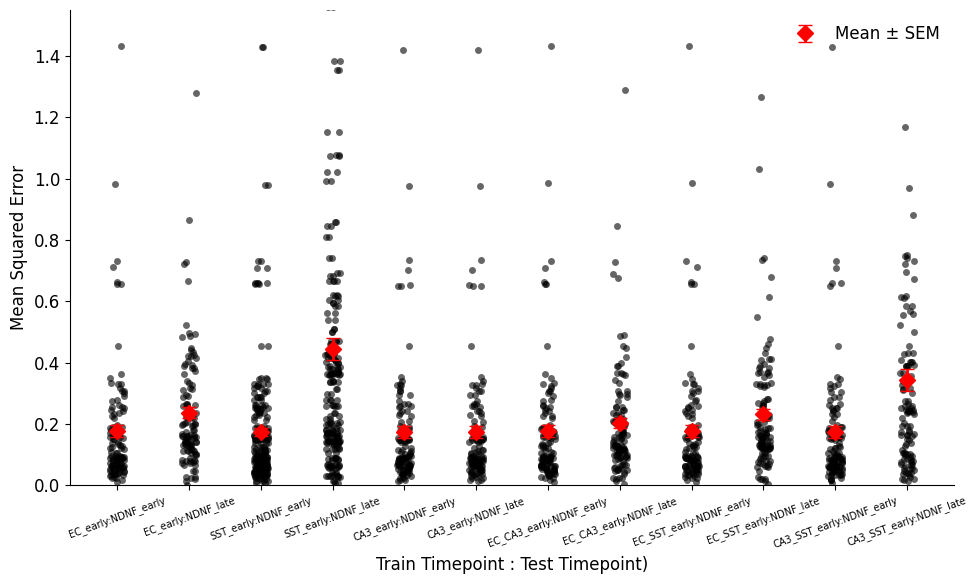

In [ ]:


plot_early_late_split_all_input_types(activity_dict_SST, activity_dict_EC, fixed_activity_dict_NDNF_newest, ca3_vs_position_all_cells_array, cp_dict_EC, cp_dict_SST, cp_dict_NDNF, ymax=1.55)



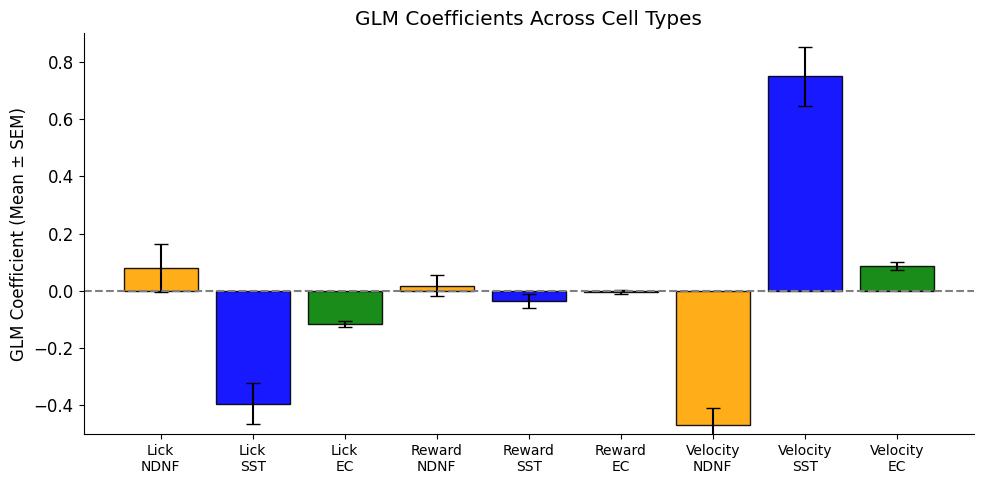

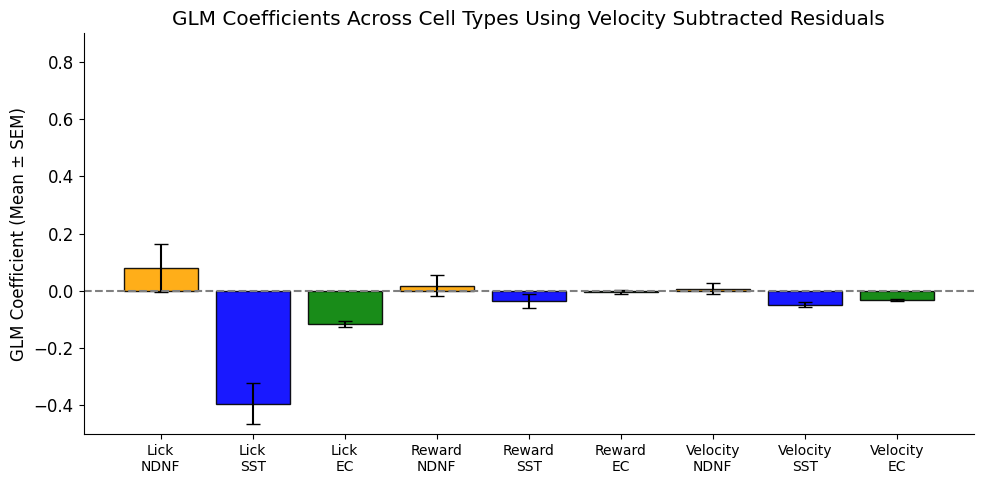

In [ ]:


########################### gets you the coefficients of all the cell types together 

from sklearn.linear_model import LinearRegression


EC_GLM_models, design_matrix_dict_EC = get_GLM_models_cell_type(activity_dict_EC, factors_dict_EC)
SST_GLM_models, design_matrix_dict_SST = get_GLM_models_cell_type(activity_dict_SST, factors_dict_SST)
NDNF_GLM_models, design_matrix_dict_NDNF = get_GLM_models_cell_type(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)
    

###### 
indices_array = np.arange(3)
MSE_list_EC, prediction_list_EC, weights_list_EC = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array)

indices_array = np.arange(3)
MSE_list_NDNF, prediction_list_NDNF, weights_list_NDNF = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array)

indices_array = np.arange(3)
MSE_list_SST, prediction_list_SST, weights_list_SST = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array)



plot_coefficients_all_celltypes_together(weights_list_NDNF, weights_list_SST, weights_list_EC, title="GLM Coefficients Across Cell Types")



EC_GLM_models_r, design_matrix_dict_EC_r = get_GLM_models_cell_type(residual_activity_dict_EC, factors_dict_EC)
SST_GLM_models_r, design_matrix_dict_SST_r = get_GLM_models_cell_type(residual_activity_dict_SST, factors_dict_SST)
NDNF_GLM_models_r, design_matrix_dict_NDNF_r = get_GLM_models_cell_type(fixed_residual_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)
    

###### 
indices_array = np.arange(3)
MSE_list_EC, prediction_list_EC, weights_list_EC_r = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models_r, design_matrix_dict_EC_r, indices_array)

indices_array = np.arange(3)
MSE_list_NDNF, prediction_list_NDNF, weights_list_NDNF_r = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models_r, design_matrix_dict_NDNF_r, indices_array)

indices_array = np.arange(3)
MSE_list_SST, prediction_list_SST, weights_list_SST_r = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models_r, design_matrix_dict_SST_r, indices_array)



plot_coefficients_all_celltypes_together(weights_list_NDNF_r, weights_list_SST_r, weights_list_EC_r, title="GLM Coefficients Across Cell Types Using Velocity Subtracted Residuals")


# plot_coefficients_cell_type(weights_list_EC, cell_type="EC")
# plot_coefficients_cell_type(weights_list_NDNF, cell_type="NDNF")
# plot_coefficients_cell_type(weights_list_SST, cell_type="SST")





In [ ]:
def get_GLM_models_cell_type(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest):
    NDNF_GLM_models = {}
    design_matrix_dict={}

    for i, animal in enumerate(fixed_activity_dict_NDNF_newest):
        GLM_cell_models = {}
        design_matrix_cell_dict = {}
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            animal_lick_data = fixed_factors_dict_NDNF_newest[animal]['Licks']
            animal_lick_data_flat = animal_lick_data.flatten()

            animal_reward_data = fixed_factors_dict_NDNF_newest[animal]['Reward_loc']
            animal_reward_data_flat = animal_reward_data.flatten()

            animal_velocity_data = fixed_factors_dict_NDNF_newest[animal]['Velocity']
            animal_velocity_data_flat = animal_velocity_data.flatten()

            design_matrix = np.vstack([animal_lick_data_flat, animal_reward_data_flat, animal_velocity_data_flat])
            design_matrix_cell_dict[cell] = design_matrix
            
            neuron_activity = fixed_activity_dict_NDNF_newest[animal][cell]

            neuron_activity_flat = neuron_activity.flatten()

            model = fit_GLM2(design_matrix, neuron_activity_flat, regression='linear', alphas=None)
            
            GLM_cell_models[cell] = model

        NDNF_GLM_models[animal] = GLM_cell_models
        design_matrix_dict[animal] = design_matrix_cell_dict

    return NDNF_GLM_models, design_matrix_dict

In [ ]:
# for animal in factors_dict_EC:

# for animal in 
def fit_GLM_pop_all_vars(factors_dict_EC, activity_dict_EC):

    model_dict = {}
    coef_dict = {}

    for animal in activity_dict_EC:
        cell_dict_model = {}
        cell_dict_coef = {}
        for cell in activity_dict_EC[animal]:
            var_list = []

            for var in factors_dict_EC[animal]:
                var_list.append(factors_dict_EC[animal][var].flatten())


            var_array = np.array(var_list)

            neuron_activity_flat = activity_dict_EC[animal][cell].flatten()
            model = fit_GLM2(var_array, neuron_activity_flat, regression='linear', alphas=None)

            cell_dict_model[cell] = model
            cell_dict_coef[cell] = model.coef_

        model_dict[animal] = cell_dict_model
        coef_dict[animal] = cell_dict_coef

    return model_dict, coef_dict


model_dict, coef_dict = fit_GLM_pop_all_vars(factors_dict_EC, activity_dict_EC)


In [ ]:
model_dict_r, coef_dict_r = fit_GLM_pop_all_vars(factors_dict_EC, residual_activity_dict_EC)


In [ ]:
def get_coef_dict_together(coef_dict):
    keys = ['Licks', 'Reward_loc', 'Velocity', 'Position_1', 'Position_2', 'Position_3',
            'Position_4', 'Position_5', 'Position_6', 'Position_7', 'Position_8', 'Position_9', 'Position_10']

    coef_dict_together = {k: [] for k in keys}

    for animal in coef_dict:
        for cell in coef_dict[animal]:
            coefs = coef_dict[animal][cell] 

            for k,v in zip(keys, coefs):
                coef_dict_together[k].append(v)

    return coef_dict_together

coef_dict_together = get_coef_dict_together(coef_dict)

coef_dict_together_r = get_coef_dict_together(coef_dict_r)


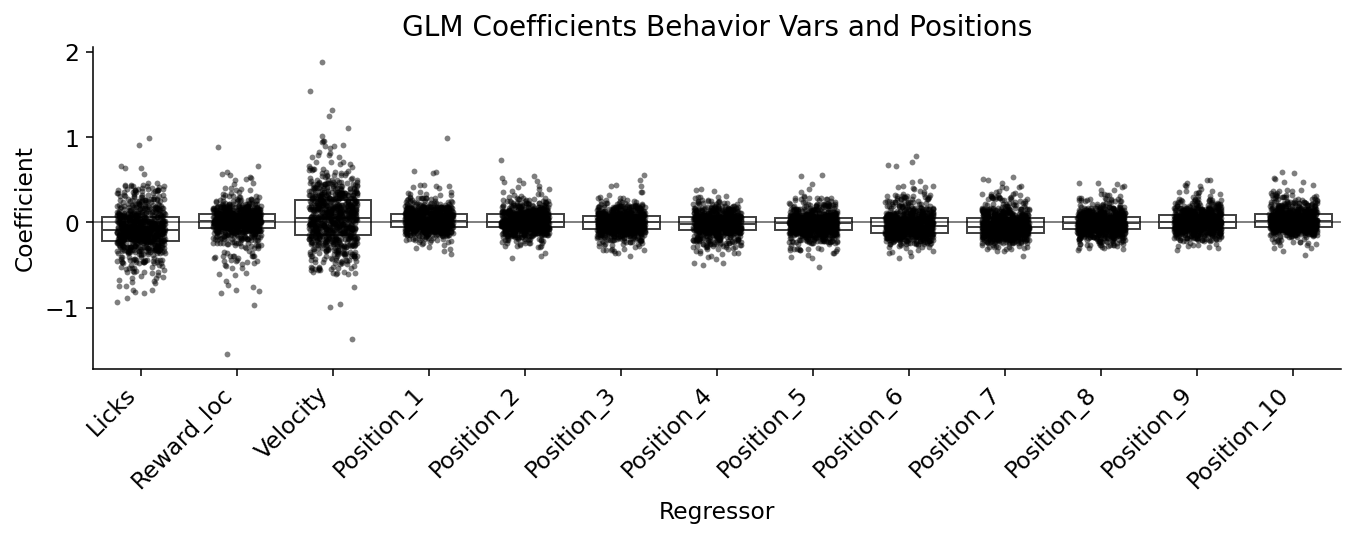

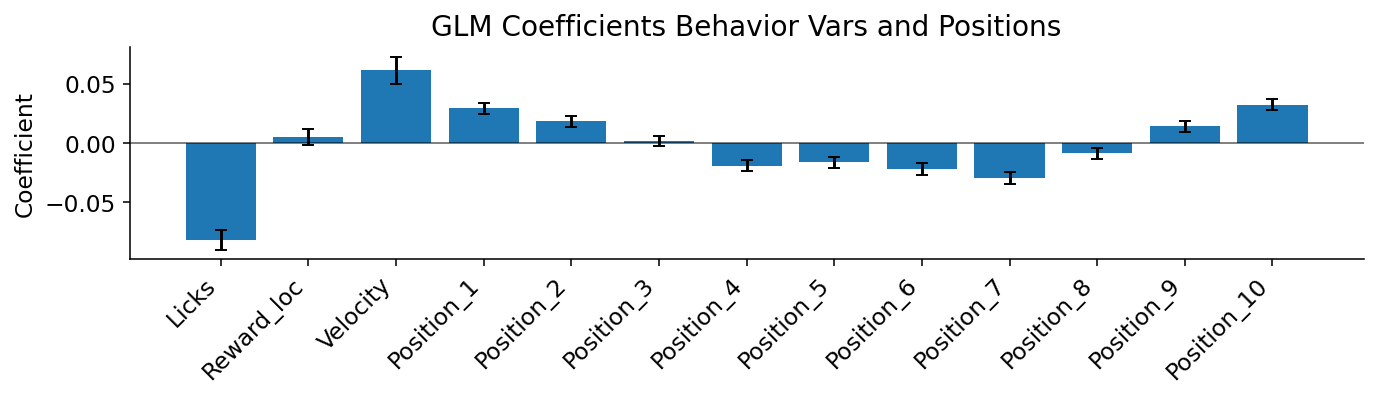

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_coefficients_GLM(coef_dict_together):
        keys = ['Licks','Reward_loc','Velocity','Position_1','Position_2','Position_3',
                'Position_4','Position_5','Position_6','Position_7','Position_8',
                'Position_9','Position_10']

        # Build DataFrame (handles uneven lengths via NaN)
        df = pd.DataFrame({k: pd.Series(coef_dict_together[k]) for k in keys}, columns=keys)

        # Calculate means/SEMs once
        means = df.mean(skipna=True)
        sems  = df.sem(skipna=True)

        # Single consistent order (stable sort for ties)
        # order = means.abs().sort_values(ascending=False, kind='mergesort').index.tolist()

        # ===== 1) Box + jitter =====
        df_long = df.melt(var_name='Regressor', value_name='Coefficient').dropna()

        plt.figure(figsize=(10,4), dpi=140)
        sns.boxplot(data=df_long, x='Regressor', y='Coefficient',
                showcaps=False, boxprops={'facecolor':'none'},
                whiskerprops={'linewidth':0}, showfliers=False)
        sns.stripplot(data=df_long, x='Regressor', y='Coefficient',
                color='black', size=3, alpha=0.5, jitter=0.25)
        plt.axhline(0, color='k', linewidth=1, alpha=0.5)
        plt.xticks(rotation=45, ha='right')
        plt.title('GLM Coefficients Behavior Vars and Positions')
        plt.tight_layout()

        # ===== 2) Mean ± SEM bar plot =====
        plt.figure(figsize=(10,3), dpi=140)
        plt.bar(range(len(order)), means, yerr=sems, capsize=3)
        plt.axhline(0, color='k', linewidth=1, alpha=0.5)
        plt.xticks(range(len(keys)), keys, rotation=45, ha='right')
        plt.ylabel('Coefficient')
        plt.title('GLM Coefficients Behavior Vars and Positions')
        plt.tight_layout()

        plt.show()

plot_coefficients_GLM(coef_dict_together)



/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_17864/2326004655.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', n_groups)


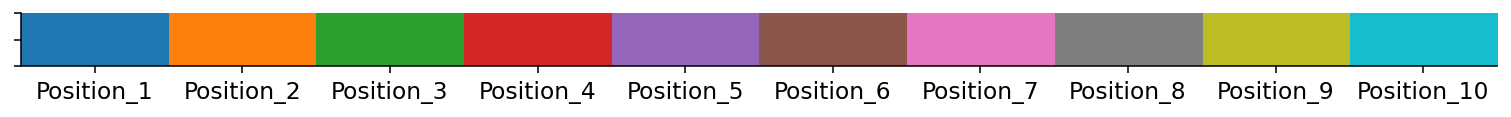

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm

n_bins_total = 50
n_groups = 10
bins_per_group = 5

group_ids = np.repeat(np.arange(n_groups), bins_per_group)
cmap = plt.cm.get_cmap('tab10', n_groups)

# discrete normalization (centers at 0..9)
bounds = np.arange(-0.5, n_groups + 0.5, 1)
norm = BoundaryNorm(bounds, cmap.N)

fig, ax = plt.subplots(figsize=(11, 1), dpi=140)
im = ax.imshow(group_ids[np.newaxis, :], aspect='auto', cmap=cmap, norm=norm)

# ticks centered on each 5-bin group
tick_positions = np.arange(0, n_bins_total, 5) + (bins_per_group/2 - 0.5)
tick_labels = ["Position_1", "Position_2", "Position_3", "Position_4", "Position_5", "Position_6", "Position_7", "Position_8", "Position_9", "Position_10"]
ax.set_xticks(tick_positions, tick_labels)
ax.tick_params(axis='y', labelleft=False)

# leave room at bottom for the larger colorbar
plt.tight_layout()
plt.show()


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

def get_factor_array(fixed_factors_dict_NDNF_newest, n_trials, vars='Licks'):
    lick_list = []
    for animal in fixed_factors_dict_NDNF_newest:
        lick_list.append(fixed_factors_dict_NDNF_newest[animal][vars][:,:n_trials])

    lick_array = np.array(lick_list)
    return lick_array

def setup_log_reg(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest):  
    
    shape_list =[]
    for animal in fixed_factors_dict_NDNF_newest:
        shape_list.append(fixed_factors_dict_NDNF_newest[animal]['Licks'].shape[1])

    n_trials = np.min(shape_list)

    EC = {}
    for idx, animal in enumerate(fixed_activity_dict_NDNF_newest):
        NDNF_list = []
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            NDNF_list.append(fixed_activity_dict_NDNF_newest[animal][cell][:,:n_trials])

        NDNF_array = np.array(NDNF_list)
        EC[idx] = NDNF_array

    NDNF_activity_array = np.array(NDNF_list)


    lick_array = get_factor_array(fixed_factors_dict_NDNF_newest, n_trials, vars='Licks')
    reward_array = get_factor_array(fixed_factors_dict_NDNF_newest, n_trials, vars='Reward_loc')
    velocity_array = get_factor_array(fixed_factors_dict_NDNF_newest, n_trials, vars='Velocity')

    return EC, lick_array, reward_array, velocity_array


def fit_log_reg(X, y, n_splits=5):

    """
    X: is a dict of animals where every vaule is shape (cells, trials, pos) for that animal 
    y: shape (trials, pos) for the same animal 
    """

    log_reg_animal_dict = {}


    for animal in X:
        animal_data = X[animal]
        variable_data = y[animal,:,:]
        n_cells, n_trials, n_pos = animal_data.shape
        X_reshaped = animal_data.transpose(1, 2, 0).reshape(n_trials * n_pos, n_cells)
        y_flat = variable_data.flatten()

        all_probs = np.zeros(n_trials * n_pos)
        all_preds = np.zeros(n_trials * n_pos)

        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        
        accuracies = []
        preds = []
        probs = []

        for train_index, test_index in kf.split(X_reshaped):
            X_train, X_test = X_reshaped[train_index], X_reshaped[test_index]
            y_train, y_test = y_flat[train_index], y_flat[test_index]

            model = LogisticRegression(max_iter=1000)
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            y_prob = model.predict_proba(X_test)[:, 1]
            all_probs[test_index] = y_prob 
            all_preds[test_index] = y_pred

            accuracies.append(accuracy_score(y_test, y_pred))
            preds.append(y_pred)
            probs.append(y_prob)

        all_probs_reshaped = all_probs.reshape(n_trials, n_pos)
        all_preds_reshaped = all_preds.reshape(n_trials, n_pos)
        y_true_reshaped = y_flat.reshape(n_trials, n_pos)

        log_reg_animal_dict[animal] = {"accuracies":accuracies,
        "all_preds_reshaped": all_preds_reshaped,
        "all_probs_reshaped": all_probs_reshaped,
        "y_true_reshaped":y_true_reshaped
        }

    return log_reg_animal_dict


def get_GLM_models_cell_type(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest):
    NDNF_GLM_models = {}
    design_matrix_dict={}

    for i, animal in enumerate(fixed_activity_dict_NDNF_newest):
        GLM_cell_models = {}
        design_matrix_cell_dict = {}
        for cell in fixed_activity_dict_NDNF_newest[animal]:
            animal_lick_data = fixed_factors_dict_NDNF_newest[animal]['Licks']
            animal_lick_data_flat = animal_lick_data.flatten()

            animal_reward_data = fixed_factors_dict_NDNF_newest[animal]['Reward_loc']
            animal_reward_data_flat = animal_reward_data.flatten()

            animal_velocity_data = fixed_factors_dict_NDNF_newest[animal]['Velocity']
            animal_velocity_data_flat = animal_velocity_data.flatten()

            design_matrix = np.vstack([animal_lick_data_flat, animal_reward_data_flat, animal_velocity_data_flat])
            design_matrix_cell_dict[cell] = design_matrix
            
            neuron_activity = fixed_activity_dict_NDNF_newest[animal][cell]

            neuron_activity_flat = neuron_activity.flatten()

            model = fit_GLM2(design_matrix, neuron_activity_flat, regression='linear', alphas=None)
            
            GLM_cell_models[cell] = model

        NDNF_GLM_models[animal] = GLM_cell_models
        design_matrix_dict[animal] = design_matrix_cell_dict

    return NDNF_GLM_models, design_matrix_dict




EC_GLM_models, design_matrix_dict_EC = get_GLM_models_cell_type(activity_dict_EC, factors_dict_EC)
SST_GLM_models, design_matrix_dict_SST = get_GLM_models_cell_type(activity_dict_SST, factors_dict_SST)
NDNF_GLM_models, design_matrix_dict_NDNF = get_GLM_models_cell_type(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)


    

#####LRV

###### 
indices_array = np.arange(3)
MSE_list_EC, prediction_list_EC, weights_list_EC = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array)

MSE_list_NDNF, prediction_list_NDNF, weights_list_NDNF = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array)

MSE_list_SST, prediction_list_SST, weights_list_SST = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array)



NDNF_dict, NDNF_lick_array, NDNF_reward_array, NDNF_velocity_array = setup_log_reg(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)
SST_dict, SST_lick_array, SST_reward_array, SST_velocity_array = setup_log_reg(activity_dict_SST, factors_dict_SST)
EC_dict, EC_lick_array, EC_reward_array, EC_velocity_array = setup_log_reg(activity_dict_EC, factors_dict_EC)

NDNF_residual_dict, NDNF_lick_array, NDNF_reward_array, NDNF_velocity_array = setup_log_reg(fixed_residual_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)
SST_residual_dict, SST_lick_array, SST_reward_array, SST_velocity_array = setup_log_reg(residual_activity_dict_SST, factors_dict_SST)
EC_residual_dict, EC_lick_array, EC_reward_array, EC_velocity_array = setup_log_reg(residual_activity_dict_EC, factors_dict_EC)


lick_binarized_NDNF  = (NDNF_lick_array>0).astype(int)
log_reg_animal_dict_NDNF_lick = fit_log_reg(NDNF_dict, lick_binarized_NDNF, n_splits=5)
log_reg_animal_dict_NDNF_lick_res = fit_log_reg(NDNF_residual_dict, lick_binarized_NDNF, n_splits=5)

lick_binarized_SST  = (SST_lick_array>0).astype(int)
log_reg_animal_dict_SST_lick = fit_log_reg(SST_dict, lick_binarized_SST, n_splits=5)
log_reg_animal_dict_SST_lick_res = fit_log_reg(SST_residual_dict, lick_binarized_SST, n_splits=5)

lick_binarized_EC  = (EC_lick_array>0).astype(int)
log_reg_animal_dict_EC_lick = fit_log_reg(EC_dict, lick_binarized_EC, n_splits=5)
log_reg_animal_dict_EC_lick_res = fit_log_reg(EC_residual_dict, lick_binarized_EC, n_splits=5)




In [ ]:



EC_GLM_models, design_matrix_dict_EC = get_GLM_models_cell_type(activity_dict_EC, factors_dict_EC)
SST_GLM_models, design_matrix_dict_SST = get_GLM_models_cell_type(activity_dict_SST, factors_dict_SST)
NDNF_GLM_models, design_matrix_dict_NDNF = get_GLM_models_cell_type(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest)


    


def remove_behaviors_GLM(activity_dict_NDNF, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array):
  MSE_list = []
  prediction_list = []
  weights_list = []

  for animal in NDNF_GLM_models:
    for cell in NDNF_GLM_models[animal]:
    
        neuron_data = activity_dict_NDNF[animal][cell]
        weights = NDNF_GLM_models[animal][cell].coef_
        intercept = NDNF_GLM_models[animal][cell].intercept_

        behavioral_correlates_before_slice = design_matrix_dict_NDNF[animal][cell][indices_array,:]

        prediction = (weights[indices_array] @ behavioral_correlates_before_slice) + intercept
        prediction_reshaped = prediction.reshape(neuron_data.shape)
        prediction_list.append(prediction_reshaped)

        mean_neuron_data = np.mean(neuron_data, axis=1)
        mean_prediction_data = np.mean(prediction_reshaped, axis=1)

        MSE = np.mean(np.square(mean_neuron_data - mean_prediction_data))
        MSE_list.append(MSE)

        weights_list.append(weights)

  return MSE_list, prediction_list, weights_list


#####LRV

###### 
indices_array = np.arange(3)
MSE_list_EC, prediction_list_EC, weights_list_EC = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array)

MSE_list_NDNF, prediction_list_NDNF, weights_list_NDNF = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array)

MSE_list_SST, prediction_list_SST, weights_list_SST = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array)




###### 
indices_array_L = [0]
MSE_list_EC_L, prediction_list_EC_L, weights_list_EC_L = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array_L)

MSE_list_NDNF_L, prediction_list_NDNF_L, weights_list_NDNF_L = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array_L)

MSE_list_SST_L, prediction_list_SST_L, weights_list_SST_L = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array_L)


indices_array_R = [1]
MSE_list_EC_R, prediction_list_EC_R, weights_list_EC_R = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array_R)

MSE_list_NDNF_R, prediction_list_NDNF_R, weights_list_NDNF_R = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array_R)

MSE_list_SST_R, prediction_list_SST_R, weights_list_SST_R = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array_R)


indices_array_V = [2]
MSE_list_EC_V, prediction_list_EC_V, weights_list_EC_V = remove_behaviors_GLM(activity_dict_EC, EC_GLM_models, design_matrix_dict_EC, indices_array_V)

MSE_list_NDNF_V, prediction_list_NDNF_V, weights_list_NDNF_V = remove_behaviors_GLM(fixed_activity_dict_NDNF_newest, NDNF_GLM_models, design_matrix_dict_NDNF, indices_array_V)

MSE_list_SST_V, prediction_list_SST_V, weights_list_SST_V = remove_behaviors_GLM(activity_dict_SST, SST_GLM_models, design_matrix_dict_SST, indices_array_V)










In [ ]:
def get_mean_array(prediction_list_SST_L):
    mean_prediction_list_SST_L = []
    for i in range(len(prediction_list_SST_L)):
        mean_prediction_list_SST_L.append(np.mean(prediction_list_SST_L[i], axis=1))
    return mean_prediction_list_SST_L

mean_prediction_list_SST_L = get_mean_array(prediction_list_SST_L)
mean_prediction_list_SST_R = get_mean_array(prediction_list_SST_R)
mean_prediction_list_SST_V = get_mean_array(prediction_list_SST_V)
mean_prediction_list_SST = get_mean_array(prediction_list_SST)

prediction_array_SST_L = np.array(mean_prediction_list_SST_L)
prediction_array_SST_R = np.array(mean_prediction_list_SST_R)
prediction_array_SST_V = np.array(mean_prediction_list_SST_V)
prediction_array_SST = np.array(mean_prediction_list_SST)


mean_prediction_array_SST_L = np.mean(prediction_array_SST_L, axis=0)
sem_prediction_array_SST_L = sem(prediction_array_SST_L, axis=0)
mean_prediction_array_SST_R = np.mean(prediction_array_SST_R, axis=0)
sem_prediction_array_SST_R = sem(prediction_array_SST_R, axis=0)
mean_prediction_array_SST_V = np.mean(prediction_array_SST_V, axis=0)
sem_prediction_array_SST_V = sem(prediction_array_SST_V, axis=0)
mean_prediction_array_SST = np.mean(prediction_array_SST, axis=0)
sem_prediction_array_SST = sem(prediction_array_SST, axis=0)

SST_list = []
for animal in activity_dict_SST:
    for cell in activity_dict_SST[animal]:
        SST_list.append(np.mean(activity_dict_SST[animal][cell], axis=1))

sst_array = np.array(SST_list)

mean_real = np.mean(sst_array, axis=0)
sem_real = sem(sst_array, axis=0)

plt.figure(figsize=(10, 10))
plt.plot(mean_prediction_array_SST_L, label="Lick Pred.")
plt.fill_between(range(len(mean_prediction_array_SST_L)), mean_prediction_array_SST_L+sem_prediction_array_SST_L, mean_prediction_array_SST_L-sem_prediction_array_SST_L, alpha=0.2, color='g')
plt.plot(mean_prediction_array_SST_R, label="Reward Pred.")
plt.fill_between(range(len(mean_prediction_array_SST_R)), mean_prediction_array_SST_R+sem_prediction_array_SST_R, mean_prediction_array_SST_R-sem_prediction_array_SST_R, alpha=0.2)
plt.plot(mean_prediction_array_SST_V, label="Velocity Pred.", color='b')
plt.fill_between(range(len(mean_prediction_array_SST_V)), mean_prediction_array_SST_V+sem_prediction_array_SST_V, mean_prediction_array_SST_V-sem_prediction_array_SST_V, alpha=0.2, color='b')
plt.plot(mean_prediction_array_SST, label="Total Pred.", color='k')
plt.fill_between(range(len(mean_prediction_array_SST)), mean_prediction_array_SST+sem_prediction_array_SST, mean_prediction_array_SST-sem_prediction_array_SST, alpha=0.2, color='k')
# plt.plot(mean_real, label="Raw Activity", color='k')
# plt.fill_between(range(len(mean_real)), mean_real+sem_real, mean_real-sem_real, alpha=0.2, color='k')
plt.title("Population Prediction of Variables Contribution to Actvity", fontsize=20)
plt.xlabel("Position Bins")
plt.ylabel("DF/F")
plt.legend(fontsize=15)
plt.show()

NameError: name 'prediction_list_SST_L' is not defined

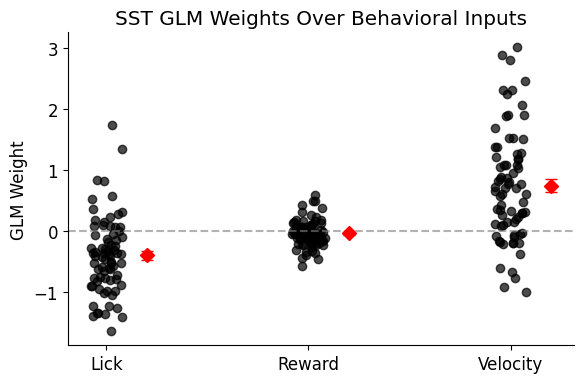

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import sem

# Assuming weights_list_SST is already defined
lick_weights = []
reward_weights = []
velocity_weights = []

for data in weights_list_SST:
    lick_weights.append(data[0])
    reward_weights.append(data[1])
    velocity_weights.append(data[2])

# Convert to numpy arrays
lick_weights = np.array(lick_weights)
reward_weights = np.array(reward_weights)
velocity_weights = np.array(velocity_weights)

# X positions and labels
x_labels = ['Lick', 'Reward', 'Velocity']
x_pos = np.arange(len(x_labels))  # [0, 1, 2]
x_offset = 0.2  # Offset for mean+SEM
jitter_strength = 0.08

# Create figure
plt.figure(figsize=(6, 4))

# Plot black dots with jitter
np.random.seed(0)  # for reproducibility
for i, weights in enumerate([lick_weights, reward_weights, velocity_weights]):
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(weights))
    plt.scatter(np.full_like(weights, x_pos[i]) + jitter, weights, color='black', alpha=0.7)

# Plot diamond + SEM
for i, weights in enumerate([lick_weights, reward_weights, velocity_weights]):
    mean_val = np.mean(weights)
    sem_val = sem(weights)
    plt.errorbar(x_pos[i] + x_offset, mean_val, yerr=sem_val,
                 fmt='D', color='red', capsize=4, markersize=7, label='_nolegend_')

# Formatting
plt.xticks(x_pos, x_labels)
plt.ylabel("GLM Weight")
plt.title("SST GLM Weights Over Behavioral Inputs")
plt.axhline(0, color='grey', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


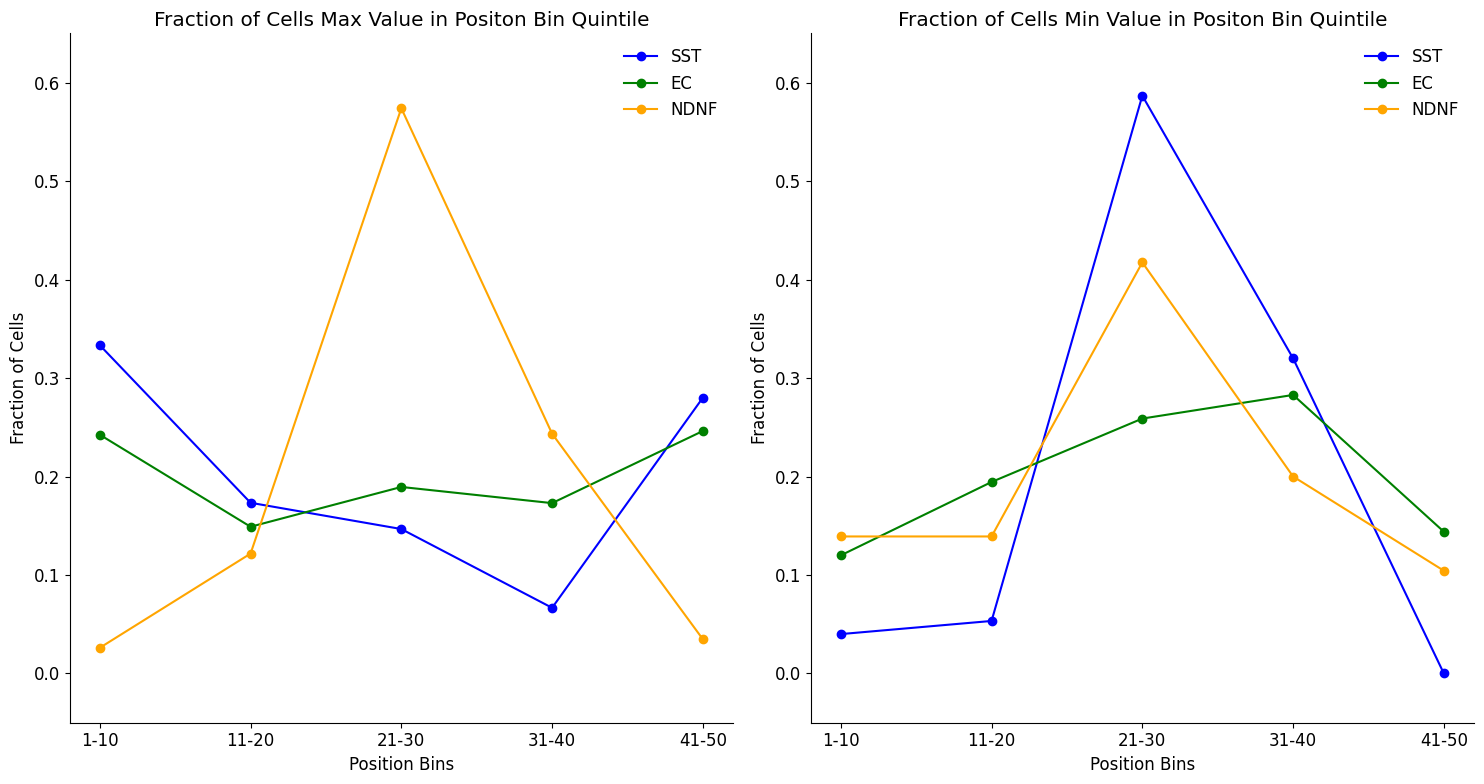

In [ ]:

def get_argmin_argmax_data_binned(activity_dict_SST, cp_dict_SST, use_argmax=True, split_early_late=False, use_early=True):

    """
    params animal_average_selectivity_dict_SST_r: selectivity value for every cell in a dict
    returns binned_data: the cells with selectiivty values that fit within each bin (percent of data)
    """

    count_0_10 = 0
    count_10_20 = 0
    count_20_30 = 0
    count_30_40 = 0
    count_40_50 = 0

    tot_cells = 0

    for idx, animal in enumerate(activity_dict_SST):
        for idt, cell in enumerate(activity_dict_SST[animal]):
            data = activity_dict_SST[animal][cell]
            if split_early_late:
                cp = cp_dict_SST[idx][idt]
                e_cut = cp[0]
                l_cut = cp[1]
                if use_argmax:
                    if use_early:
                        SST_argmax = np.argmax(np.mean(data[:,:e_cut], axis=1))
                    else:
                        SST_argmax = np.argmax(np.mean(data[:,-l_cut:], axis=1))

                else:
                    if use_early:
                        SST_argmax = np.argmin(np.mean(data[:,:e_cut], axis=1))
                    else:
                        SST_argmax = np.argmin(np.mean(data[:,-l_cut:], axis=1))

            else:
                if use_argmax:
                    SST_argmax = np.argmax(np.mean(data, axis=1))
                else:
                    SST_argmax = np.argmin(np.mean(data, axis=1))

            if SST_argmax <=9:
                count_0_10+=1
            elif 9 < SST_argmax <=19:
                count_10_20+=1
            elif 19 < SST_argmax <=29:
                count_20_30+=1
            elif 29 < SST_argmax <=39:
                count_30_40+=1
            elif 39 < SST_argmax <=49:
                count_40_50+=1
            tot_cells+=1

    counts_array = np.array([count_0_10/tot_cells, count_10_20/tot_cells, count_20_30/tot_cells, count_30_40/tot_cells, count_40_50/tot_cells])
    return counts_array

binned_data_SST_argmax = get_argmin_argmax_data_binned(residual_activity_dict_SST, cp_dict_SST, use_argmax=True, split_early_late=False, use_early=True)
binned_data_SST_argmin= get_argmin_argmax_data_binned(residual_activity_dict_SST, cp_dict_SST, use_argmax=False, split_early_late=False, use_early=True)

binned_data_EC_argmax = get_argmin_argmax_data_binned(residual_activity_dict_EC, cp_dict_EC, use_argmax=True, split_early_late=False, use_early=True)
binned_data_EC_argmin= get_argmin_argmax_data_binned(residual_activity_dict_EC, cp_dict_EC, use_argmax=False, split_early_late=False, use_early=True)

binned_data_NDNF_argmax = get_argmin_argmax_data_binned(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, use_argmax=True, split_early_late=False, use_early=True)
binned_data_NDNF_argmin= get_argmin_argmax_data_binned(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, use_argmax=False, split_early_late=False, use_early=True)

fig, axs = plt.subplots(1,2, figsize=(15,8))
axs[0].plot(binned_data_SST_argmax, color='b', label="SST", marker="o")
axs[0].plot(binned_data_EC_argmax, color='green', label="EC", marker="o")
axs[0].plot(binned_data_NDNF_argmax, color='orange', label="NDNF", marker="o")
axs[0].set_ylabel("Fraction of Cells")
axs[0].set_xlabel("Position Bins")
axs[0].set_xticks(np.arange(5), ["1-10","11-20","21-30","31-40","41-50"])
axs[0].set_title("Fraction of Cells Max Value in Positon Bin Quintile")
axs[0].set_ylim(-0.05,0.65)
axs[0].legend()

axs[1].plot(binned_data_SST_argmin, color='b', label="SST", marker="o")
axs[1].plot(binned_data_EC_argmin, color='green', label="EC", marker="o")
axs[1].plot(binned_data_NDNF_argmin, color='orange', label="NDNF", marker="o")
axs[1].set_ylabel("Fraction of Cells")
axs[1].set_xlabel("Position Bins")
axs[1].set_xticks(np.arange(5), ["1-10","11-20","21-30","31-40","41-50"])
axs[1].set_title("Fraction of Cells Min Value in Positon Bin Quintile")
axs[1].set_ylim(-0.05,0.65)
axs[1].legend()

plt.tight_layout()
plt.show()



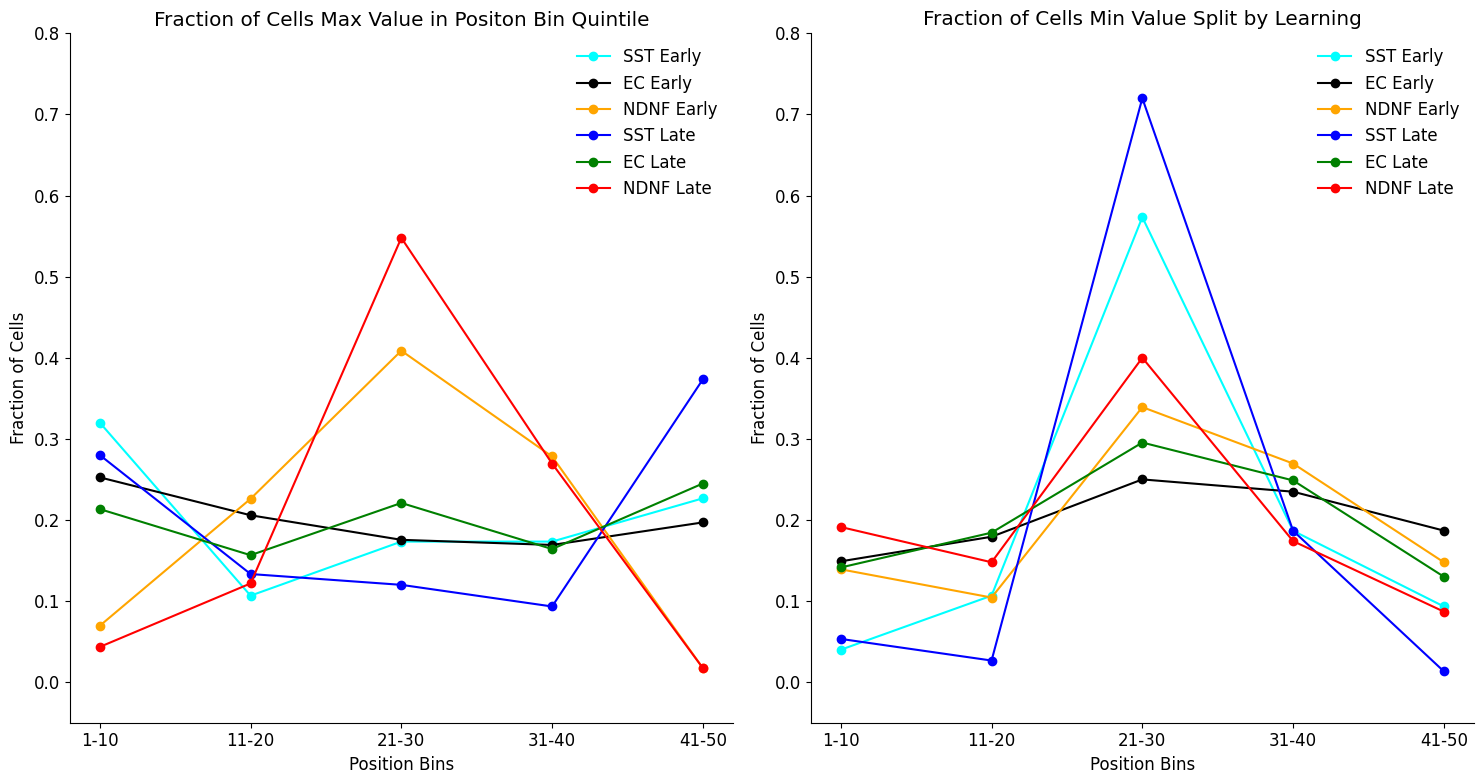

In [ ]:


binned_data_SST_argmax_e = get_argmin_argmax_data_binned(activity_dict_SST, cp_dict_SST, use_argmax=True, split_early_late=True, use_early=True)
binned_data_SST_argmin_e = get_argmin_argmax_data_binned(activity_dict_SST, cp_dict_SST, use_argmax=False, split_early_late=True, use_early=True)

binned_data_SST_argmax_l = get_argmin_argmax_data_binned(activity_dict_SST, cp_dict_SST, use_argmax=True, split_early_late=True, use_early=False)
binned_data_SST_argmin_l = get_argmin_argmax_data_binned(activity_dict_SST, cp_dict_SST, use_argmax=False, split_early_late=True, use_early=False)

binned_data_EC_argmax_e = get_argmin_argmax_data_binned(activity_dict_EC, cp_dict_EC, use_argmax=True, split_early_late=True, use_early=True)
binned_data_EC_argmin_e = get_argmin_argmax_data_binned(activity_dict_EC, cp_dict_EC, use_argmax=False, split_early_late=True, use_early=True)

binned_data_EC_argmax_l = get_argmin_argmax_data_binned(activity_dict_EC, cp_dict_EC, use_argmax=True, split_early_late=True, use_early=False)
binned_data_EC_argmin_l = get_argmin_argmax_data_binned(activity_dict_EC, cp_dict_EC, use_argmax=False, split_early_late=True, use_early=False)

binned_data_NDNF_argmax_e = get_argmin_argmax_data_binned(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, use_argmax=True, split_early_late=True, use_early=True)
binned_data_NDNF_argmin_e = get_argmin_argmax_data_binned(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, use_argmax=False, split_early_late=True, use_early=True)

binned_data_NDNF_argmax_l = get_argmin_argmax_data_binned(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, use_argmax=True, split_early_late=True, use_early=False)
binned_data_NDNF_argmin_l = get_argmin_argmax_data_binned(fixed_residual_activity_dict_NDNF_newest, cp_dict_NDNF, use_argmax=False, split_early_late=True, use_early=False)


fig, axs = plt.subplots(1,2, figsize=(15,8))
axs[0].plot(binned_data_SST_argmax_e, color='cyan', label="SST Early", marker="o")
axs[0].plot(binned_data_EC_argmax_e, color='k', label="EC Early", marker="o")
axs[0].plot(binned_data_NDNF_argmax_e, color='orange', label="NDNF Early", marker="o")

axs[0].plot(binned_data_SST_argmax_l, color='b', label="SST Late", marker="o")
axs[0].plot(binned_data_EC_argmax_l, color='green', label="EC Late", marker="o")
axs[0].plot(binned_data_NDNF_argmax_l, color='red', label="NDNF Late", marker="o")

axs[0].set_ylabel("Fraction of Cells")
axs[0].set_xlabel("Position Bins")
axs[0].set_xticks(np.arange(5), ["1-10","11-20","21-30","31-40","41-50"])
axs[0].set_title("Fraction of Cells Max Value in Positon Bin Quintile")
axs[0].set_ylim(-0.05,0.8)
axs[0].legend()

axs[1].plot(binned_data_SST_argmin_e, color='cyan', label="SST Early", marker="o")
axs[1].plot(binned_data_EC_argmin_e, color='k', label="EC Early", marker="o")
axs[1].plot(binned_data_NDNF_argmin_e, color='orange', label="NDNF Early", marker="o")

axs[1].plot(binned_data_SST_argmin_l, color='b', label="SST Late", marker="o")
axs[1].plot(binned_data_EC_argmin_l, color='green', label="EC Late", marker="o")
axs[1].plot(binned_data_NDNF_argmin_l, color='red', label="NDNF Late", marker="o")

axs[1].set_ylabel("Fraction of Cells")
axs[1].set_xlabel("Position Bins")
axs[1].set_xticks(np.arange(5), ["1-10","11-20","21-30","31-40","41-50"])
axs[1].set_title("Fraction of Cells Min Value Split by Learning")
axs[1].set_ylim(-0.05,0.8)
axs[1].legend()

plt.tight_layout()
plt.show()


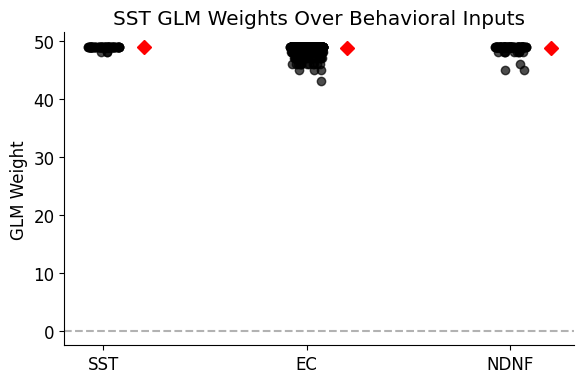

In [ ]:
def get_cell_range_list(residual_activity_dict_EC):
    cell_range_list = []
    for animal in residual_activity_dict_EC:
        for cell in residual_activity_dict_EC[animal]:
            trial_peak_list = []
            data = residual_activity_dict_EC[animal][cell]
            for trial in range(data.shape[1]):
                trial_peak = np.argmax(data[:, trial])
                trial_peak_list.append(trial_peak)
            cell_range = np.max(trial_peak_list) - np.min(trial_peak_list)
            cell_range_list.append(cell_range)

    return cell_range_list

cell_range_list_SST = get_cell_range_list(residual_activity_dict_SST)
cell_range_list_EC = get_cell_range_list(residual_activity_dict_EC)
cell_range_list_NDNF = get_cell_range_list(fixed_residual_activity_dict_NDNF_newest)

# X positions and labels
x_labels = ['SST', 'EC', 'NDNF']
x_pos = np.arange(len(x_labels))  # [0, 1, 2]
x_offset = 0.2  # Offset for mean+SEM
jitter_strength = 0.08

# Create figure
plt.figure(figsize=(6, 4))

# Plot black dots with jitter
np.random.seed(0)  # for reproducibility
for i, weights in enumerate([cell_range_list_SST, cell_range_list_EC, cell_range_list_NDNF]):
    jitter = np.random.uniform(-jitter_strength, jitter_strength, size=len(weights))
    plt.scatter(np.full_like(weights, x_pos[i]) + jitter, weights, color='black', alpha=0.7)

# Plot diamond + SEM
for i, weights in enumerate([cell_range_list_SST, cell_range_list_EC, cell_range_list_NDNF]):
    mean_val = np.mean(weights)
    sem_val = sem(weights)
    plt.errorbar(x_pos[i] + x_offset, mean_val, yerr=sem_val,
                 fmt='D', color='red', capsize=4, markersize=7, label='_nolegend_')

# Formatting
plt.xticks(x_pos, x_labels)
plt.ylabel("GLM Weight")
plt.title("SST GLM Weights Over Behavioral Inputs")
plt.axhline(0, color='grey', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
# from sklearn.model_selection import cross_val_score
# from sklearn.linear_model import LogisticRegression

# def fit_log_reg(neural_activity_sup_bef_V1, y, n_splits=10):
#   activity_list = []
#   for i in range(neural_activity_sup_bef_V1.shape[0]):
#     flat_activity = neural_activity_sup_bef_V1[i,:,:].flatten()
#     activity_list.append(flat_activity)

#   X = np.array(activity_list).T
#   # X = X[:,:100]

#   X_scaled = (X - np.min(X)) / (np.max(X) - np.min(X))

#   y_flat = y.flatten()

#   log_reg = LogisticRegression(penalty=None, max_iter=1000)

#   accuracies = cross_val_score(log_reg, X_scaled, y_flat, cv=n_splits)

#   return accuracies
# accuracies = fit_log_reg(neural_activity_sup_bef_V1, lick_data_array_before_sup, n_splits=10)
# accuracies = fit_log_reg(NDNF_activity_array, lick_data_array_before_sup, n_splits=10)
# print(accuracies)






# from sklearn.model_selection import cross_val_score
# from sklearn.linear_model import LogisticRegression

# def fit_log_reg(neural_activity_sup_bef_V1, y, n_splits=10):
#   activity_list = []
#   for i in range(neural_activity_sup_bef_V1.shape[0]):
#     flat_activity = neural_activity_sup_bef_V1[i,:,:].flatten()
#     activity_list.append(flat_activity)

#   X = np.array(activity_list).T
#   # X = X[:,:100]

#   y_flat = y.flatten()

#   log_reg = LogisticRegression(penalty=None, max_iter=1000)

#   accuracies = cross_val_score(log_reg, X, y_flat, cv=n_splits)
#   return accuracies





In [ ]:

def get_mean_accuracy_dict(NDNF_dict, log_reg_animal_dict):
    mean_accuracy_list_NDNF_lick = []
    for animal in NDNF_dict:
        animal_accuracy = log_reg_animal_dict[animal]["accuracies"]
        mean_animal_accuracy = np.mean(animal_accuracy) *100
        mean_accuracy_list_NDNF_lick.append(mean_animal_accuracy)

    return mean_accuracy_list_NDNF_lick

mean_accuracy_list_NDNF_lick = get_mean_accuracy_dict(NDNF_dict, log_reg_animal_dict_NDNF_lick)
mean_accuracy_list_NDNF_lick_res = get_mean_accuracy_dict(NDNF_residual_dict, log_reg_animal_dict_NDNF_lick_res)

mean_accuracy_list_EC_lick = get_mean_accuracy_dict(EC_dict, log_reg_animal_dict_EC_lick)
mean_accuracy_list_EC_lick_res = get_mean_accuracy_dict(EC_residual_dict, log_reg_animal_dict_EC_lick_res)

mean_accuracy_list_SST_lick = get_mean_accuracy_dict(SST_dict, log_reg_animal_dict_SST_lick)
mean_accuracy_list_SST_lick_res = get_mean_accuracy_dict(SST_residual_dict, log_reg_animal_dict_SST_lick_res)


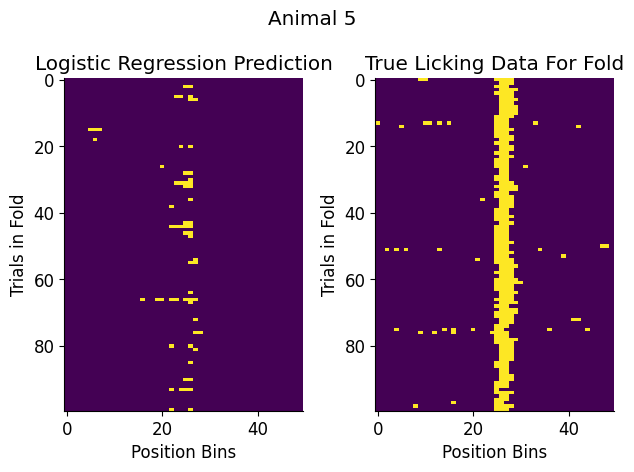

In [ ]:
animal = 5
fig, axs = plt.subplots(1,2)
plt.suptitle(f"Animal {animal}")
axs[0].imshow(log_reg_animal_dict_NDNF_lick[animal]["all_preds_reshaped"].T, aspect='auto')
axs[1].imshow(log_reg_animal_dict_NDNF_lick[animal]["y_true_reshaped"].T, aspect='auto')
axs[0].set_title("Logistic Regression Prediction")
axs[1].set_title("True Licking Data For Fold")
axs[0].set_xlabel("Position Bins")
axs[0].set_ylabel("Trials in Fold")
axs[1].set_xlabel("Position Bins")
axs[1].set_ylabel("Trials in Fold")

plt.tight_layout()
plt.show()

/var/folders/hl/zfn0lkv15xx80f47pqqz8p9c0000gn/T/ipykernel_766/2711541857.py:25: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:red'` for the same effect.

  sns.pointplot(x='Group', y='Accuracy', hue='Group', data=df, color='red', errorbar='sd', markers='d', err_kws={'linewidth': 1.5})


ANOVA: F = 17.28, p = 0.0000
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
    EC   NDNF   16.817 0.0002  8.1289 25.5051   True
    EC    SST  20.7596    0.0 11.6268 29.8924   True
  NDNF    SST   3.9426 0.4327 -3.8525 11.7377  False
----------------------------------------------------


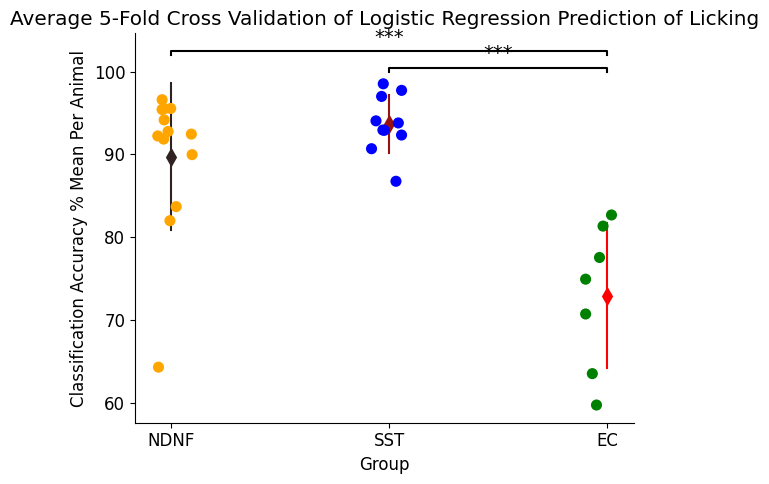

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pandas as pd

# --- Your data ---
ndnf = mean_accuracy_list_NDNF_lick
sst = mean_accuracy_list_SST_lick
ec = mean_accuracy_list_EC_lick

# ndnf_res = mean_accuracy_list_NDNF_lick_res
# sst_res = mean_accuracy_list_SST_lick
# ec_res = mean_accuracy_list_EC_lick

# Combine into a DataFrame
data = ndnf + sst + ec
groups = (['NDNF'] * len(ndnf)) + (['SST'] * len(sst)) + (['EC'] * len(ec))
df = pd.DataFrame({'Group': groups, 'Accuracy': data})

# --- Plot ---
plt.figure(figsize=(6, 5))
sns.stripplot(x='Group', y='Accuracy', hue='Group', data=df, jitter=True, size=8, palette={'NDNF':'orange', 'SST':'blue', 'EC':'green'})
sns.pointplot(x='Group', y='Accuracy', hue='Group', data=df, color='red', errorbar='sd', markers='d', err_kws={'linewidth': 1.5})

plt.ylabel("Classification Accuracy % Mean Per Animal")
plt.title("Average 5-Fold Cross Validation of Logistic Regression Prediction of Licking")

# --- ANOVA ---
f_val, p_val = f_oneway(ndnf, sst, ec)
print(f"ANOVA: F = {f_val:.2f}, p = {p_val:.4f}")

# --- Tukey HSD post-hoc ---
tukey = pairwise_tukeyhsd(endog=df['Accuracy'], groups=df['Group'], alpha=0.05)
print(tukey)

# --- Add significance stars manually ---
# Get means per group for y positions
means = df.groupby('Group')['Accuracy'].mean().to_dict()
y_offset = 2

# Helper function to add stars
def add_star(x1, x2, y, star, y_offset = 0.5):
    plt.plot([x1, x1, x2, x2], [y, y+y_offset, y+y_offset, y], lw=1.5, color='black')
    plt.text((x1 + x2) / 2, y + y_offset + 0.5, star, ha='center', va='bottom', fontsize=14)

# Get Tukey HSD results table as a DataFrame
tukey_df = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])


custom_y_locs = {
    ('NDNF', 'SST'): 85,
    ('NDNF', 'EC'): 102,
    ('SST', 'EC'): 100
}

# Format the group names for matching
pairs = [('NDNF', 'SST'), ('NDNF', 'EC'), ('SST', 'EC')]
for group1, group2 in pairs:
    row = tukey_df[((tukey_df['group1'] == group1) & (tukey_df['group2'] == group2)) |
                   ((tukey_df['group1'] == group2) & (tukey_df['group2'] == group1))]

    if row.empty:
        continue  # Skip if no match

    p = float(row['p-adj'].values[0])
    if p < 0.001:
        stars = '***'
    elif p < 0.01:
        stars = '**'
    elif p < 0.05:
        stars = '*'
    else:
        stars = 'n.s.'

    if stars != 'n.s.':
        x1, x2 = ['NDNF', 'SST', 'EC'].index(group1), ['NDNF', 'SST', 'EC'].index(group2)
        # y = max(means[group1], means[group2]) + 3
        y = custom_y_locs.get((group1, group2), 85)
        add_star(x1, x2, y, stars)

plt.tight_layout()
plt.show()


In [ ]:
def get_model_dict(EC_data_array, fixed_residual_activity_dict_NDNF_newest, min_val, reg_type="ridge"):
    model_EC = {}
    for animal in fixed_residual_activity_dict_NDNF_newest:
        cell_model_EC = {}
        for cell in fixed_residual_activity_dict_NDNF_newest[animal]:
            neuron_activity = fixed_residual_activity_dict_NDNF_newest[animal][cell][:,:min_val]
            neuron_activity_flat = neuron_activity.flatten()
            model_NDNF = fit_GLM2(EC_data_array, neuron_activity_flat, regression=reg_type, alphas=None)
            cell_model_EC[cell] = model_NDNF
        model_EC[animal] = cell_model_EC
        
    return model_EC


model_EC_dict_early = get_model_dict(early_EC_array, activity_dict_EC, min_val_EC_early, reg_type="ridge")


NameError: name 'early_EC_array' is not defined

In [ ]:

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Step 1: Create DataFrame
df = pd.DataFrame({
    "MSE": (
        MSE_list_just_SST +
        MSE_list_just_EC +strip
        MSE_list_just_CA3 +
        MSE_list_EC_CA3 +
        MSE_list_EC_SST +
        MSE_list_CA3_SST +
        MSE_list_EC_CA3_SST
    ),
    "Input": (
        ["SST"] * len(MSE_list_just_SST) +
        ["EC"] * len(MSE_list_just_EC) +
        ["CA3"] * len(MSE_list_just_CA3) +
        ["EC + CA3"] * len(MSE_list_EC_CA3) +
        ["EC + SST"] * len(MSE_list_EC_SST) +
        ["CA3 + SST"] * len(MSE_list_CA3_SST) +
        ["EC + CA3 + SST"] * len(MSE_list_EC_CA3_SST)
    )
})

# Step 2: Define custom color palette
custom_palette = {
    "SST": "blue",
    "EC": "green",
    "CA3": "red",
    "EC + CA3": "yellow",
    "EC + SST": "cyan",
    "CA3 + SST": "purple",
    "EC + CA3 + SST": "orange"
}

# Step 3: Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x="Input", y="MSE", data=df, inner="box", cut=0, palette=custom_palette)
plt.title("NDNF Cell MSE by Input Cell Type")
plt.ylabel("Mean Squared Error")
plt.xlabel("Input Type")
plt.xticks(rotation=20)
plt.ylim(0,1.75)
plt.tight_layout()
plt.show()

In [ ]:
min_trials = 1000
for animal in activity_dict_SST:
    for cell in activity_dict_SST[animal]:
        if activity_dict_SST[animal][cell].shape[1] < min_trials:
            min_trials = activity_dict_SST[animal][cell].shape[1]

print(min_trials)

63


(75, 50, 20)

In [ ]:
heres neuron over all trial give me latent factors but enforce predefined latent factor --- hand in a latent that is lick 

do no binned for lick, velocity, position-- unfiltered licks -- try to fit glm on that 

In [ ]:
###### correct hit ###### all the corrrect licks excluded 




###### getting behavioral weights over NDNF 


def fit_GLM2(EC_data_array, neuron_activity_flat, regression='linear', alphas=None):
    
    design_matrix_X = EC_data_array.T
    
    if regression == 'linear':
        model = LinearRegression()
    elif regression == 'lasso':
        model = LassoCV(alphas=alphas, cv=None) if alphas is not None else LassoCV(cv=None)
    elif regression == 'ridge':
        model = RidgeCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000], cv=None)
    elif regression == 'elastic':
        l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9, 1]
        model = ElasticNetCV(alphas=alphas if alphas is not None else [0.1, 1, 10, 100, 1000, 5000],
                             l1_ratio=l1_ratio, cv=None)

    model.fit(design_matrix_X, neuron_activity_flat)
    # neuron_predicted_activity = model.predict(design_matrix_X)
    
    return model 




NameError: name 'remove_behaviors_GLM' is not defined

In [ ]:
def get_prediction_lists(prediction_list_EC, prediction_list_EC_minusL, prediction_list_EC_minusR, prediction_list_EC_minusV):
    prediction_overall_list = []
    prediction_minusL_list = []
    prediction_minusR_list = []
    prediction_minusV_list = []

    for i in range(len(prediction_list_EC)):
        prediction_overall_list.append(np.mean(prediction_list_EC[i], axis=1))
        prediction_minusL_list.append(np.mean(prediction_list_EC_minusL[i], axis=1))
        prediction_minusR_list.append(np.mean(prediction_list_EC_minusR[i], axis=1))
        prediction_minusV_list.append(np.mean(prediction_list_EC_minusV[i], axis=1))

    return prediction_overall_list, prediction_minusL_list, prediction_minusR_list, prediction_minusV_list

prediction_overall_list_EC, prediction_minusL_list_EC, prediction_minusR_list_EC, prediction_minusV_list_EC = get_prediction_lists(prediction_list_EC, prediction_list_EC_minusL, prediction_list_EC_minusR, prediction_list_EC_minusV)
prediction_overall_list_NDNF, prediction_minusL_list_NDNF, prediction_minusR_list_NDNF, prediction_minusV_list_NDNF = get_prediction_lists(prediction_list_NDNF, prediction_list_NDNF_minusL, prediction_list_NDNF_minusR, prediction_list_NDNF_minusV)
prediction_overall_list_SST, prediction_minusL_list_SST, prediction_minusR_list_SST, prediction_minusV_list_SST = get_prediction_lists(prediction_list_SST, prediction_list_SST_minusL, prediction_list_SST_minusR, prediction_list_SST_minusV)







def plotting_helper(prediction_overall_list, ax, color="k", label="All Coeff. Included", linestyle="--"):
    prediction_overall_array = np.array(prediction_overall_list)

    mean_overall = np.mean(prediction_overall_array, axis=0)
    sem_overall = sem(prediction_overall_array, axis=0)

    ax.plot(mean_overall, color=color, label=label, linestyle=linestyle)
    ax.fill_between(range(len(mean_overall)), mean_overall - sem_overall, mean_overall + sem_overall,
                    alpha=0.2, color=color)


fig, axs = plt.subplots(3, 2, figsize=(15, 15))
ax = axs[0, 0] 
plotting_helper(prediction_overall_list_EC, ax=ax, color='k', label="All Coeff. Included", linestyle='-')
plotting_helper(prediction_minusL_list_EC, ax=ax, color='g', label="Minus L", linestyle='--')
plotting_helper(prediction_minusR_list_EC, ax=ax, color='r', label="Minus R", linestyle='--')
plotting_helper(prediction_minusV_list_EC, ax=ax, color='b', label="Minus V", linestyle='--')
ax.legend()

ax = axs[1, 0] 
plotting_helper(prediction_overall_list_SST, ax=ax, color='k', label="All Coeff. Included", linestyle='-')
plotting_helper(prediction_minusL_list_SST, ax=ax, color='g', label="Minus L", linestyle='--')
plotting_helper(prediction_minusR_list_SST, ax=ax, color='r', label="Minus R", linestyle='--')
plotting_helper(prediction_minusV_list_SST, ax=ax, color='b', label="Minus V", linestyle='--')
ax.legend()

ax = axs[2, 0] 
plotting_helper(prediction_overall_list_NDNF, ax=ax, color='k', label="All Coeff. Included", linestyle='-')
plotting_helper(prediction_minusL_list_NDNF, ax=ax, color='g', label="Minus L", linestyle='--')
plotting_helper(prediction_minusR_list_NDNF, ax=ax, color='r', label="Minus R", linestyle='--')
plotting_helper(prediction_minusV_list_NDNF, ax=ax, color='b', label="Minus V", linestyle='--')


ax.legend()
plt.tight_layout()

plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'prediction_list_EC' is not defined

In [ ]:

def get_activitys(activity_dict_SST):
    SST_data_list = []
    for animal in activity_dict_SST:
        for cell in activity_dict_SST[animal]:
            # SST_data_list.append(np.mean(activity_dict_SST[animal][cell][:,:end], axis=1))
            SST_data_list.append(np.mean(activity_dict_SST[animal][cell], axis=1))

    SST_data_array_early = np.array(SST_data_list)
    return SST_data_array_early

SST_datas = get_activitys(activity_dict_SST)
EC_datas = get_activitys(activity_dict_EC)
NDNF_datas = get_activitys(fixed_activity_dict_NDNF_newest)

SST_datas_r = get_activitys(residual_activity_dict_SST)
EC_datas_r = get_activitys(residual_activity_dict_EC)
NDNF_datas_r = get_activitys(fixed_residual_activity_dict_NDNF_newest)



In [ ]:

lick_weights = []
reward_weights = []
velocity_weights = []

for i in weights_list_EC:
    lick_weights.append(i[0])
    reward_weights.append(i[1])
    velocity_weights.append(i[2])

input_data = [lick_weights, reward_weights, velocity_weights]
input_keys = ['Lick', 'Reward', 'Velocity']

def plot_coefficients_cell_type(input_data, input_keys, cell_type="EC"):
    

    df = pd.DataFrame({
        'Lick': lick_weights,
        'Reward': reward_weights,
        'Velocity': velocity_weights
    })

    # Melt for long-form plotting
    df_melted = df.melt(var_name='Variable', value_name='Weight')

    # Plot
    plt.figure(figsize=(6, 5))
    # sns.pointplot(data=df_melted, x='Variable', y='Weight', color='red', join=False, errorbar='sd', markers='d', err_kws={'linewidth': 1.5})
    sns.stripplot(data=df_melted, x='Variable', y='Weight', color='black', jitter=True, alpha=0.5)

    offset=0.2

    variable_names = ['Lick', 'Reward', 'Velocity']
    for i, var in enumerate(variable_names):
        values = df[var]
        mean = np.mean(values)
        se = np.std(values) / np.sqrt(len(values))
        plt.errorbar(i + offset, mean, yerr=se, fmt='d', color='red',
                     capsize=5, elinewidth=1.5, markeredgewidth=1.5)

    plt.axhline(0, linestyle='--', color='grey')
    plt.title(f'GLM Coefficients {cell_type}')
    plt.ylabel('Weight')
    plt.tight_layout()
    plt.show()

plot_coefficients_cell_type(weights_list_EC, cell_type="EC")
plot_coefficients_cell_type(weights_list_NDNF, cell_type="NDNF")
plot_coefficients_cell_type(weights_list_SST, cell_type="SST")


792

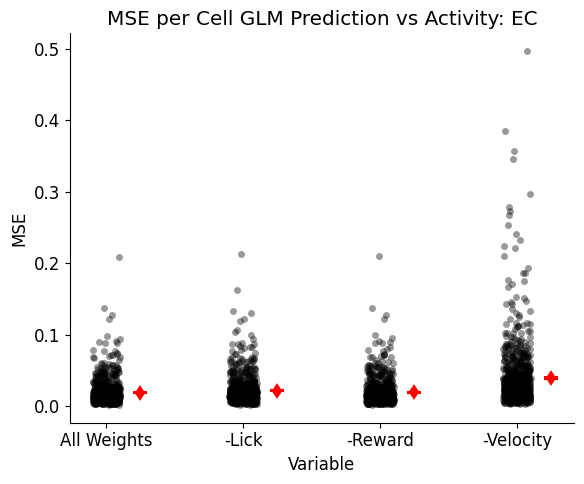

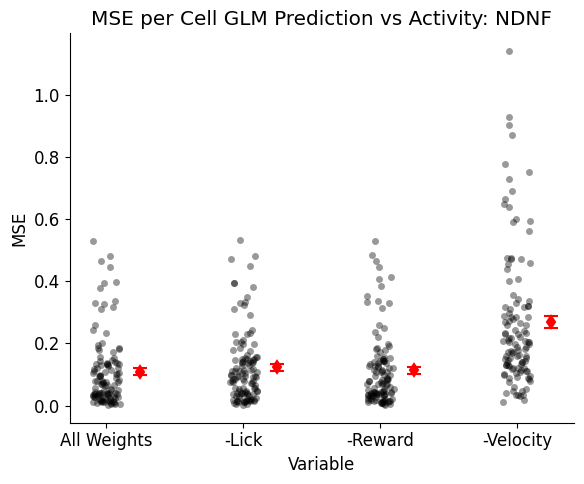

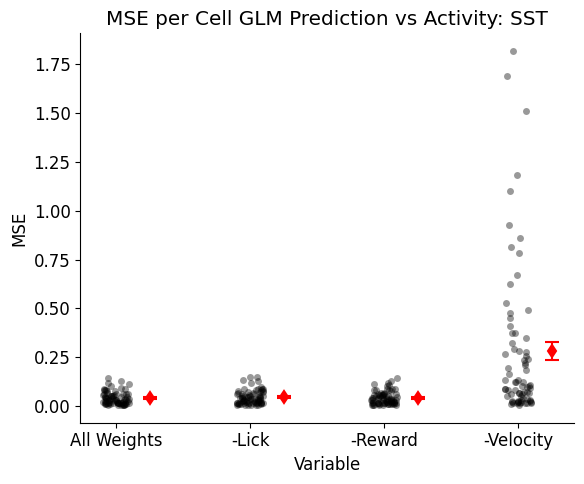

In [ ]:

def plot_coefficients_modular(input_data, input_keys, ax=axs[0,0], cell_type="Cell Type", title_prefix="GLM Coefficients", ylabel="MSE"):
    """
    Plots stripplot + mean ± SEM for input variables.

    Parameters:
    - input_data: list of arrays/lists, one per variable
    - input_keys: list of strings, labels for each variable
    - cell_type: string to appear in the plot title
    - title_prefix: string for title prefix
    """
    assert len(input_data) == len(input_keys), "input_data and input_keys must have same length"
    
    # Combine into a dictionary and then DataFrame
    data_dict = {key: values for key, values in zip(input_keys, input_data)}
    df = pd.DataFrame(data_dict)
    
    # Melt for long-form plotting
    df_melted = df.melt(var_name='Variable', value_name='Weight')
    
    # Plot
    plt.figure(figsize=(max(6, len(input_keys)*1.5), 5))
    sns.stripplot(data=df_melted, x='Variable', y='Weight', color='black', jitter=True, alpha=0.4)

    offset = 0.25
    for i, key in enumerate(input_keys):
        values = df[key]
        mean = np.mean(values)
        se = np.std(values) / np.sqrt(len(values))
        plt.errorbar(i + offset, mean, yerr=se, fmt='d', color='red',
                     capsize=5, elinewidth=1.5, markeredgewidth=1.5)
    
    ax.set_title(f'{title_prefix}: {cell_type}')
    ax.set_ylabel(ylabel)


# input_data = [MSE_list_EC, MSE_list_EC_minusL, MSE_list_EC_minusR, MSE_list_EC_minusV]
# input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
# plot_coefficients_modular(input_data, input_keys, cell_type="EC", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

# input_data = [MSE_list_NDNF, MSE_list_NDNF_minusL, MSE_list_NDNF_minusR, MSE_list_NDNF_minusV]
# input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
# plot_coefficients_modular(input_data, input_keys, cell_type="NDNF", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

# input_data = [MSE_list_SST, MSE_list_SST_minusL, MSE_list_SST_minusR, MSE_list_SST_minusV]
# input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
# plot_coefficients_modular(input_data, input_keys, cell_type="SST", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")




In [ ]:


input_data = [MSE_list_EC, MSE_list_EC_minusL, MSE_list_EC_minusR, MSE_list_EC_minusV]
input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
plot_coefficients_modular(input_data, input_keys, cell_type="EC", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

input_data = [MSE_list_NDNF, MSE_list_NDNF_minusL, MSE_list_NDNF_minusR, MSE_list_NDNF_minusV]
input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
plot_coefficients_modular(input_data, input_keys, cell_type="NDNF", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

input_data = [MSE_list_SST, MSE_list_SST_minusL, MSE_list_SST_minusR, MSE_list_SST_minusV]
input_keys = ["All Weights", "-Lick", "-Reward", "-Velocity"]
plot_coefficients_modular(input_data, input_keys, cell_type="SST", title_prefix="MSE per Cell GLM Prediction vs Activity", ylabel="MSE")

plt.tight_layout()
plt.show()


Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 5 cells
    Animal 1: 15 cells
    Animal 2: 6 cells
    Animal 3: 4 cells
    Animal 4: 13 cells
    Animal 5: 13 cells
    Animal 6: 3 cells
    Animal 7: 3 cells
    Animal 8: 3 cells
    Animal 9: 10 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 192 cells
    Animal 1: 150 cells
    Animal 2: 154 cells
    Animal 3: 82 cells
    Animal 4: 74 cells
    Animal 5: 64 cells
    Animal 6: 76 cells
Loaded MSEs for 1 rank(s).
  Rank 20:
    Animal 0: 12 cells
    Animal 1: 16 cells
    Animal 2: 4 cells
    Animal 3: 10 cells
    Animal 4: 8 cells
    Animal 5: 7 cells
    Animal 6: 11 cells
    Animal 7: 10 cells
    Animal 8: 17 cells
    Animal 9: 17 cells
    Animal 10: 9 cells
    Animal 11: 6 cells
    Animal 12: 10 cells
    Animal 13: 9 cells
    Animal 14: 6 cells
    Animal 15: 12 cells
    Animal 16: 7 cells
    Animal 17: 7 cells
    Animal 18: 7 cells
    Animal 19: 10 cells
    Animal 20: 9 cells
    Animal 21: 

In [ ]:
def plot_datar(SST_datas, title="Velocity Across All Animals", color='b', ax=None, ylab=None):
    SST_data_mean = np.mean(SST_datas, axis=0)
    SST_data_sem = sem(SST_datas, axis=0)  

    for i in range(SST_datas.shape[0]):
        ax.plot(SST_datas[i,:], color='grey', alpha=0.2)

    ax.plot(SST_data_mean, color=color, label='Raw')
    ax.fill_between(range(len(SST_data_mean)), SST_data_mean+SST_data_sem, SST_data_mean - SST_data_sem, alpha=0.2, color=color)

    ax.set_title(title)
    ax.set_ylabel(ylab)    
    ax.set_xlabel("Position Bins")


In [ ]:

def plot_data(SST_datas, SST_datas_r, title="SST Activity Across All Cells", color='b', include_res=True, ax=None):
    SST_data_mean = np.mean(SST_datas, axis=0)
    SST_data_sem = sem(SST_datas, axis=0)  

    SST_data_mean_r = np.mean(SST_datas_r, axis=0)
    SST_data_sem_r = sem(SST_datas_r, axis=0)  

    ax.plot(SST_data_mean, color=color, label='Raw')
    ax.fill_between(range(len(SST_data_mean)), SST_data_mean+SST_data_sem, SST_data_mean - SST_data_sem, alpha=0.2, color=color)
    ax.set_title(title)
    ax.set_ylabel("Z-Scored DF/F")
    ax.set_xlabel("Position Bins")
    ax.set_ylim(-0.5,0.5)
    if include_res:
        ax.plot(SST_data_mean_r, color=color, label="Vel. Sub. Residual")
        ax.fill_between(range(len(SST_data_mean_r)), SST_data_mean_r+SST_data_sem_r, SST_data_mean_r - SST_data_sem_r, alpha=0.2, color=color)



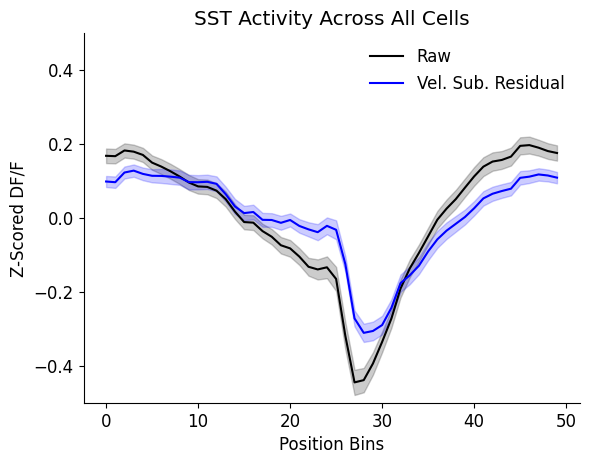

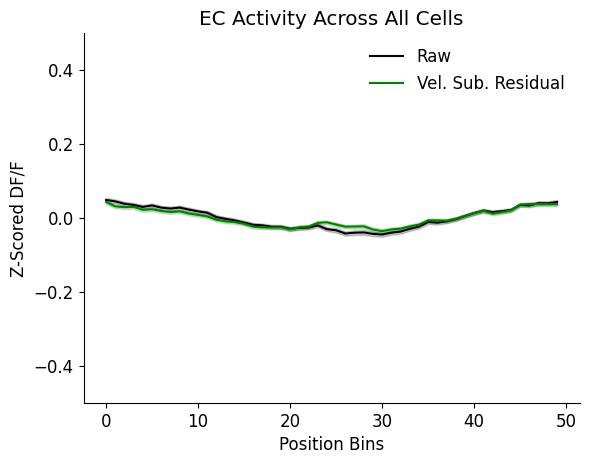

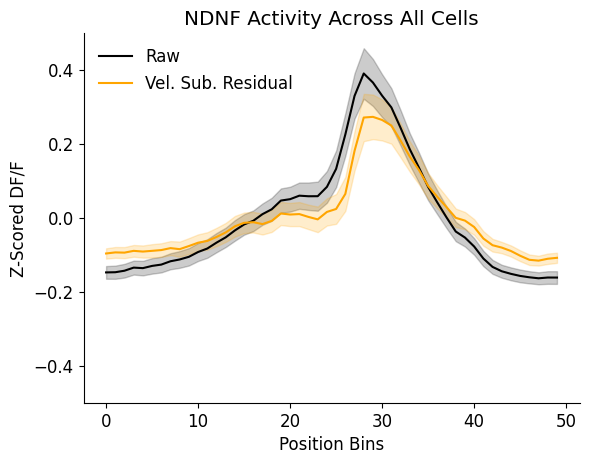

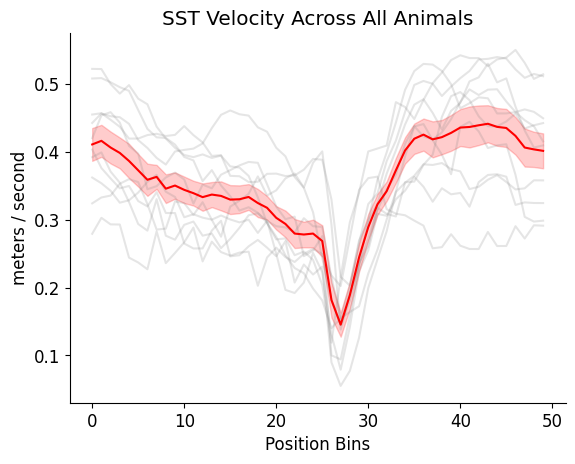

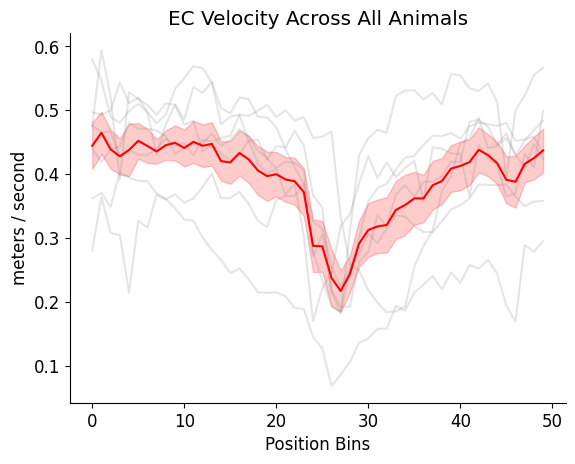

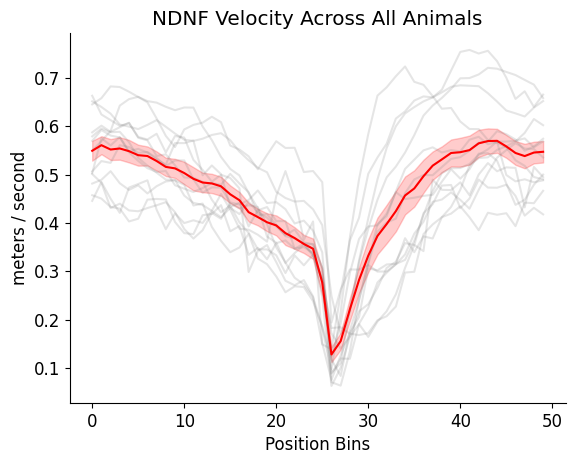

In [ ]:
###################### In case of Emergency this will plot all cells activities and velocities 

plot_data(SST_datas, SST_datas_r, title="SST Activity Across All Cells", color='b')
plot_data(EC_datas, EC_datas_r, title="EC Activity Across All Cells", color='green')
plot_data(NDNF_datas, NDNF_datas_r, title="NDNF Activity Across All Cells", color='orange')


SST_velocity_array = get_velocities(factors_dict_SST)
EC_velocity_array = get_velocities(factors_dict_EC)
NDNF_velocity_array = get_velocities(fixed_factors_dict_NDNF_newest)

plot_datar(SST_velocity_array, title="SST Velocity Across All Animals", color='r')
plot_datar(EC_velocity_array, title="EC Velocity Across All Animals", color='r')
plot_datar(NDNF_velocity_array, title="NDNF Velocity Across All Animals", color='r')

In [ ]:
factors_dict_EC['animal_1']['Velocity']

AttributeError: 'numpy.ndarray' object has no attribute 'keys'

In [ ]:
def get_corr(activity_dict_EC, factors_dict_EC, color=None, title=None, ax=None):
    correlation_list = []
    for animal in activity_dict_EC:
        for cell in activity_dict_EC[animal]:
            velocity = factors_dict_EC[animal]['Velocity']
            velocity_flat = velocity.flatten()
            activity = activity_dict_EC[animal][cell]
            activity_flat = activity.flatten()
            r_val, _ = pearsonr(velocity_flat, activity_flat)
            correlation_list.append(r_val)

    ax.hist(correlation_list, bins=20, color=color, edgecolor='black')

    # Add labels and a title for clarity
    ax.set_xlabel('Pearson Correlation Coefficient (r)')
    ax.set_ylabel('Number of Cells')
    ax.set_title(f'Distribution of Velocity-Activity Correlations {title}')


In [ ]:
def get_lick(factors_dict_EC, color=None, title=None, ax=None):
    lick_list = []
    for animal in activity_dict_EC:
        lick = factors_dict_EC[animal]['Licks']
        lick_list.append(np.mean(lick, axis=1))

    lick_array = np.array(lick_list)
    mean_lick_array = np.mean(lick_array, axis=0)

    for i in range(len(lick_list)):
        plt.plot(lick_list[i], alpha=0.6, color='grey')
    plt.plot(mean_lick_array, linewidth=3, linestyle='--', color='red')
    

    # Add labels and a title for clarity
    ax.set_xlabel('Pearson Correlation Coefficient (r)')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Distribution of Velocity-Activity Correlations {title}')


In [ ]:
def get_factors(factors_dict_SST, factor=None):
    SST_data_list = []
    for animal in factors_dict_SST:
        velocity = factors_dict_SST[animal][factor]
            # SST_data_list.append(np.mean(activity_dict_SST[animal][cell][:,:end], axis=1))
        SST_data_list.append(np.mean(velocity, axis=1))

    SST_data_array_early = np.array(SST_data_list)
    return SST_data_array_early


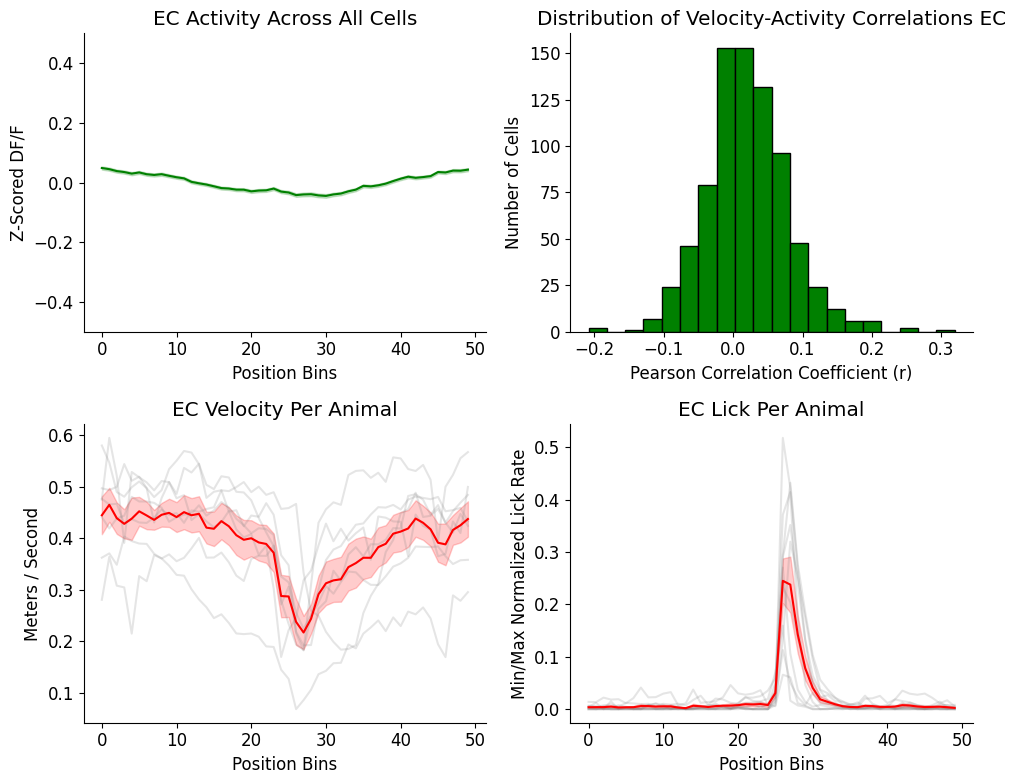

In [ ]:
###################### In case of Emergency this will plot all cells activities and velocities 

fig, axs = plt.subplots(2,2, figsize=(10,8))
plot_data(EC_datas, EC_datas_r, title="EC Activity Across All Cells", color='green', include_res=False, ax=axs[0,0])



get_corr(activity_dict_EC, factors_dict_EC, color="green", title="EC", ax=axs[0,1])



EC_velocity_array = get_velocities(factors_dict_EC)
plot_datar(EC_velocity_array, title="EC Velocity Per Animal", color='r', ax=axs[1,0], ylab="Meters / Second")


lick_data_EC = get_factors(factors_dict_SST, factor="Licks")
plot_datar(lick_data_EC, title="EC Lick Per Animal", color='r', ax=axs[1,1], ylab="Min/Max Normalized Lick Rate")

plt.tight_layout()
plt.show()



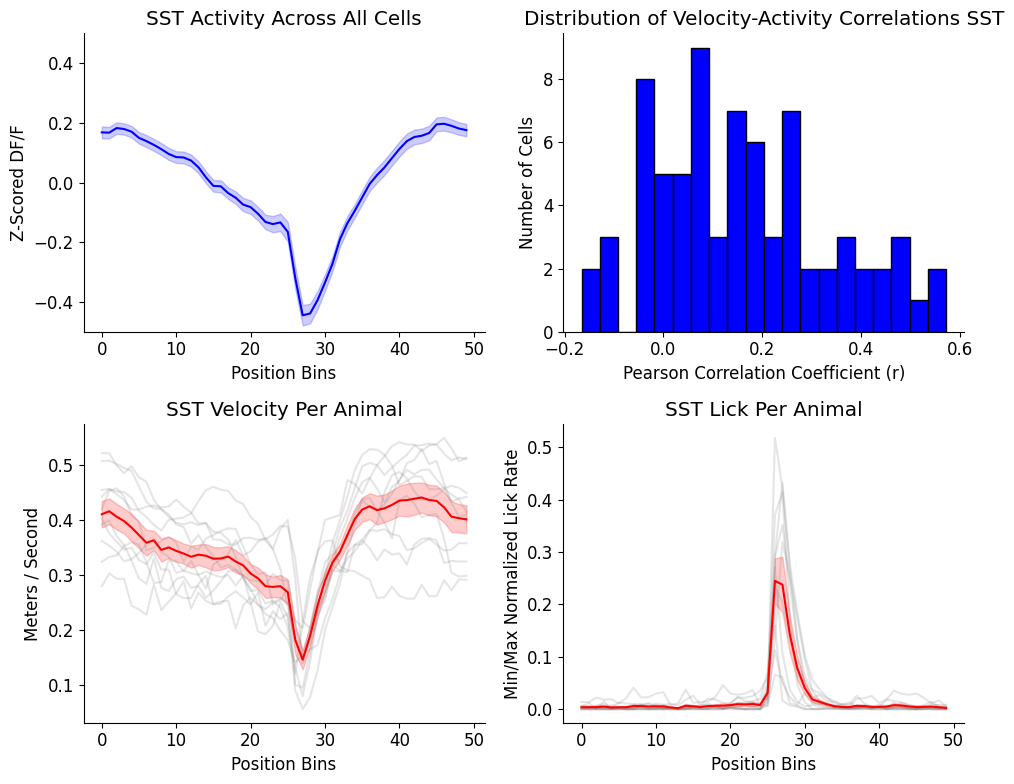

In [ ]:
###################### In case of Emergency this will plot all cells activities and velocities 

fig, axs = plt.subplots(2,2, figsize=(10,8))
plot_data(SST_datas, SST_datas_r, title="SST Activity Across All Cells", color='blue', include_res=False, ax=axs[0,0])



get_corr(activity_dict_SST, factors_dict_SST, color="blue", title="SST", ax=axs[0,1])



SST_velocity_array = get_velocities(factors_dict_SST)
plot_datar(SST_velocity_array, title="SST Velocity Per Animal", color='r', ax=axs[1,0], ylab="Meters / Second")


lick_data_SST = get_factors(factors_dict_SST, factor="Licks")
plot_datar(lick_data_SST, title="SST Lick Per Animal", color='r', ax=axs[1,1], ylab="Min/Max Normalized Lick Rate")

plt.tight_layout()
plt.show()



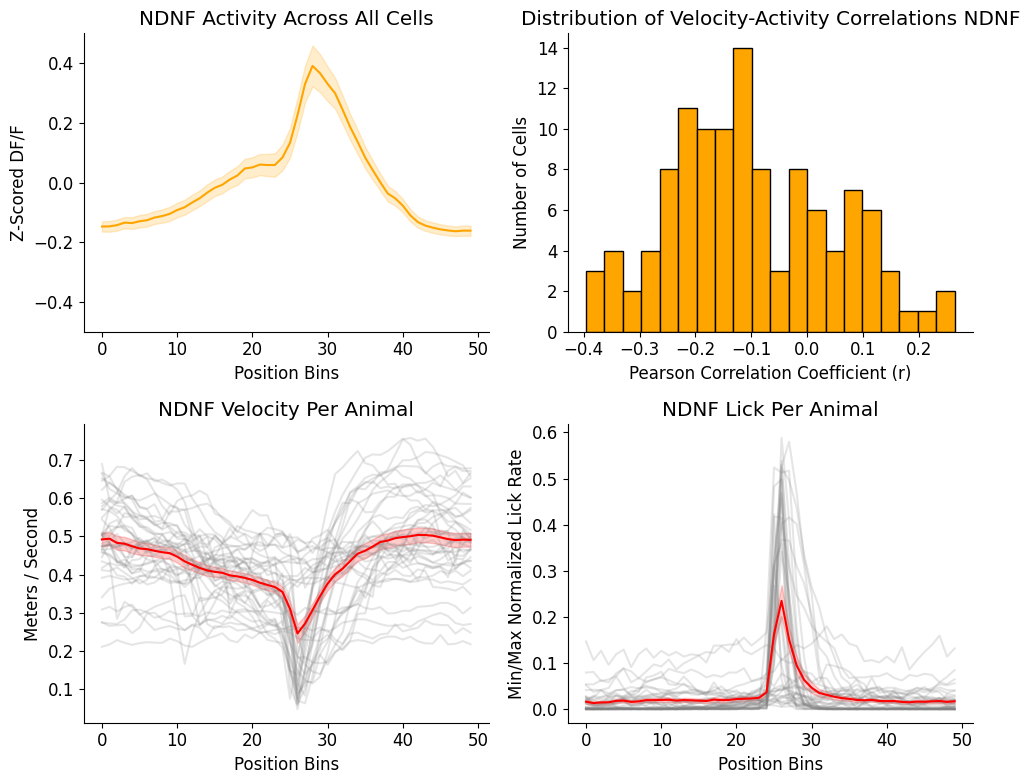

In [ ]:
###################### In case of Emergency this will plot all cells activities and velocities 

fig, axs = plt.subplots(2,2, figsize=(10,8))
plot_data(NDNF_datas, NDNF_datas_r, title="NDNF Activity Across All Cells", color='orange', include_res=False, ax=axs[0,0])



get_corr(fixed_activity_dict_NDNF_newest, fixed_factors_dict_NDNF_newest, color="orange", title="NDNF", ax=axs[0,1])



NDNF_velocity_array = get_velocities(factors_dict_NDNF_newest)
plot_datar(NDNF_velocity_array, title="NDNF Velocity Per Animal", color='r', ax=axs[1,0], ylab="Meters / Second")


lick_data_NDNF = get_factors(factors_dict_NDNF_newest, factor="Licks")
plot_datar(lick_data_NDNF, title="NDNF Lick Per Animal", color='r', ax=axs[1,1], ylab="Min/Max Normalized Lick Rate")

plt.tight_layout()
plt.show()



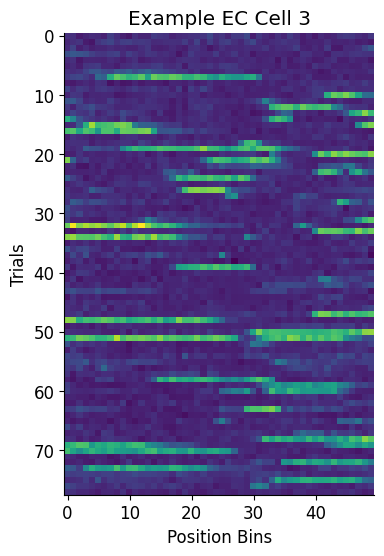

In [ ]:
plt.figure(figsize=(4,6))
plt.imshow(activity_dict_EC['animal_1']['cell_9'].T, aspect='auto')
plt.title("Example EC Cell 3")
plt.ylabel("Trials")
plt.xlabel("Position Bins")
plt.show()